# RMP Data Analysis: Study Abroad Programs and Course Insights

In [ ]:
import zipfile
import os

zip_file_path = '/content/RMP Datasets for HIPE-20260222T204717Z-1-001.zip'

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall('.')

# List the extracted files and directories
extracted_files = os.listdir('.')
print("Extracted files and directories:")
for item in extracted_files:
    print(item)


Extracted files and directories:
.config
RMP Datasets for HIPE-20260222T204717Z-1-001.zip
RMP Datasets for HIPE
sample_data


In [ ]:
import pandas as pd

sample_file_path = './RMP Datasets for HIPE/Baruch College_prof_reviews.csv'
df = pd.read_csv(sample_file_path)
print(f"Successfully loaded {sample_file_path}")
print("First 5 rows of the dataframe:")
print(df.head())
print("\nDataFrame Info:")
df.info()

Successfully loaded ./RMP Datasets for HIPE/Baruch College_prof_reviews.csv
First 5 rows of the dataframe:
   Professor ID Professor Name  Department    Course  Quality  Difficulty  \
0       1000453      Ping Wang  Accounting  ACCT2101      5.0         2.0   
1       1000453      Ping Wang  Accounting   ACC2101      4.0         4.0   
2       1000453      Ping Wang  Accounting   ACC2101      3.5         4.0   
3       1000453      Ping Wang  Accounting   ACC2101      3.0         5.0   
4       1000453      Ping Wang  Accounting   ACC2101      3.0         3.0   

      Grade  Thumbs Up  Thumbs Down  \
0  No Grade          0            0   
1  No Grade          0            0   
2  No Grade          0            0   
3  No Grade          0            0   
4  No Grade          0            0   

                                             Comment            Date  \
0  She is my recitation instructor.  I have her a...  Jun 24th, 2010   
1  Easy grader for HW's. Hard exams. Must use tex..

In [12]:
import os
import pandas as pd

rmp_data_dir = './RMP Datasets for HIPE'

all_files = os.listdir(rmp_data_dir)

csv_files = [os.path.join(rmp_data_dir, f) for f in all_files if f.endswith('.csv')]

df_list = []

for file in csv_files:
    try:
        df = pd.read_csv(file)
        filename = os.path.basename(file)
        df['source_file'] = filename
        df_list.append(df)
        print(f"Successfully loaded {file}")
    except Exception as e:
        print(f"Error loading {file}: {e}")

if df_list:
    all_reviews_df = pd.concat(df_list, ignore_index=True)
    print("\nSuccessfully concatenated all RMP review data into 'all_reviews_df'.")
    print("\nFirst 5 rows of the combined dataframe:")
    print(all_reviews_df.head())
    print("\nDataFrame Info:")
    all_reviews_df.info()
else:
    print("No CSV files were loaded.")

all_reviews_df['Course'] = all_reviews_df['Course'].astype(str).str.replace(' ', '').str.upper()

all_reviews_df['Date_parsed'] = pd.to_datetime(all_reviews_df['Date'], errors='coerce')
all_reviews_df['term_year'] = all_reviews_df['Date_parsed'].dt.year

baruch_courses_raw = ['MTH 2610', 'MSC 1003', 'STA 2000', 'STA 2000', 'ECO 1001', 'ECO 1002', 'CIS 3400', 'ENG 2850', 'ACC 2203', 'ACC 2101', 'LAW 1101', 'ENG 2150', 'CIS 3100', 'PSY 3064']
baruch_courses = [course.replace(' ', '').upper() for course in baruch_courses_raw]

hunter_courses_raw = ['MATH 15000', 'MUSHL 10100', 'STAT 21300', 'ECO 22100', 'ECO 20000', 'ECO 20100', 'CSCI 43500', 'ENGL 25146', 'ACC 27200', 'ACC 27100', 'ACC 28000', 'ENGL 22000', 'CSCI 13500', 'PSYCH 22000']
hunter_courses = [course.replace(' ', '').upper() for course in hunter_courses_raw]

reviews_2025 = all_reviews_df[all_reviews_df['Date_parsed'].dt.year == 2025].copy()

baruch_filtered = reviews_2025[
    (reviews_2025['College'] == 'Baruch College') &
    (reviews_2025['Course'].isin(baruch_courses))
]

hunter_filtered = reviews_2025[
    (reviews_2025['College'] == 'Hunter College') &
    (reviews_2025['Course'].isin(hunter_courses))
]

filtered_reviews = pd.concat([baruch_filtered, hunter_filtered])

filtered_reviews['Department'] = filtered_reviews['Department'].fillna('Unknown')

professor_course_summaries = filtered_reviews.groupby(
    ['College', 'Professor Name', 'Department', 'Course', 'term_year', 'source_file']
).agg(
    review_count=('Comment', 'count'),
    rating=('Quality', 'mean'),
    difficulty=('Difficulty', 'mean'),
    avg_thumbs_up=('Thumbs Up', 'mean'),
    top_review_excerpt=('Comment', lambda x: x.dropna().iloc[0] if not x.dropna().empty else None)
).round(2).reset_index()

professor_course_summaries = professor_course_summaries.rename(columns={
    'College': 'school',
    'Course': 'course_code',
    'Professor Name': 'professor_name',
    'Department': 'department'
})

print("\n--- Professor-Course-Year Summaries for 2025 Baruch/Hunter Courses ---")
print(f"Total summarized entries: {len(professor_course_summaries)}")
print("First 10 rows of Professor-Course Summaries:")
print(professor_course_summaries.head(10))
print("\nProfessor-Course Summaries Info:")
professor_course_summaries.info()

FileNotFoundError: [Errno 2] No such file or directory: './RMP Datasets for HIPE'

In [ ]:
display(professor_course_summaries.head(10))

,school,professor_name,department,course_code,term_year,review_count,rating,difficulty,avg_thumbs_up,top_review_excerpt,source_college
0,Baruch College,Ami Yoon,English,ENG2850,2025.0,1,4.0,2.0,0.0,Participation is important to her. Some of the...,Baruch College
1,Baruch College,Becky Lu,Music,MSC1003,2025.0,1,1.0,4.0,0.0,Says she is lenient and understanding but had ...,Baruch College
2,Baruch College,Jennifer Sylvor,English,ENG2850,2025.0,1,4.0,3.0,0.0,"Self grading system, so as long as you put in ...",Baruch College
3,Baruch College,Marc Edelman,Law,LAW1101,2025.0,1,2.0,3.0,0.0,He is a bit crazy about being on time. If you ...,Baruch College
4,Baruch College,Shawn Grant,Law,LAW1101,2025.0,1,5.0,3.0,0.0,If you're considering taking a Law 1101 class ...,Baruch College
5,Baruch College,William Organek,Law,LAW1101,2025.0,1,5.0,2.0,0.0,"he is a great professor, i am really happy i p...",Baruch College


In [11]:
import os
import pandas as pd

rmp_data_dir = './RMP Datasets for HIPE'

all_files = os.listdir(rmp_data_dir)

csv_files = [
    os.path.join(rmp_data_dir, f)
    for f in all_files
    if f.endswith('.csv')
]

df_list = []

for file in csv_files:
    try:
        df = pd.read_csv(file)
        df['source_file'] = os.path.basename(file)
        df_list.append(df)
        print(f"Loaded: {file}")
    except Exception as e:
        print(f"Error loading {file}: {e}")

all_reviews_df = pd.concat(df_list, ignore_index=True)

print("\nAll datasets combined successfully.")

all_reviews_df['Course'] = (
    all_reviews_df['Course']
    .astype(str)
    .str.replace(' ', '', regex=False)
    .str.upper()
)

all_reviews_df['Date_parsed'] = pd.to_datetime(
    all_reviews_df['Date'],
    errors='coerce'
)

all_reviews_df['term_year'] = all_reviews_df['Date_parsed'].dt.year

all_reviews_df['Department'] = (
    all_reviews_df['Department']
    .fillna('Unknown')
)

baruch_courses_raw = [
    'MTH 2610',
    'MSC 1003',
    'STA 2000',
    'ECO 1001',
    'ECO 1002',
    'CIS 3400',
    'ENG 2850',
    'ACC 2203',
    'ACC 2101',
    'LAW 1101',
    'ENG 2150',
    'CIS 3100',
    'PSY 3064'
]

hunter_courses_raw = [
    'MATH 15000',
    'MUSHL 10100',
    'STAT 21300',
    'ECO 22100',
    'ECO 20000',
    'ECO 20100',
    'CSCI 43500',
    'ENGL 25146',
    'ACC 27200',
    'ACC 27100',
    'ACC 28000',
    'ENGL 22000',
    'CSCI 13500',
    'PSYCH 22000'
]

baruch_courses = [
    c.replace(' ', '').upper()
    for c in baruch_courses_raw
]

hunter_courses = [
    c.replace(' ', '').upper()
    for c in hunter_courses_raw
]

baruch_courses = list(set(baruch_courses))
hunter_courses = list(set(hunter_courses))

reviews_2025 = all_reviews_df[
    all_reviews_df['term_year'] == 2025
].copy()

print("\nAvailable college names:")
print(reviews_2025['College'].unique())

baruch_filtered = reviews_2025[
    (reviews_2025['College'].str.contains('Baruch', case=False, na=False)) &
    (reviews_2025['Course'].isin(baruch_courses))
]

hunter_filtered = reviews_2025[
    (reviews_2025['College'].str.contains('Hunter', case=False, na=False)) &
    (reviews_2025['Course'].isin(hunter_courses))
]

filtered_reviews = pd.concat(
    [baruch_filtered, hunter_filtered],
    ignore_index=True
)

print(f"\nFiltered reviews count: {len(filtered_reviews)}")

professor_course_summaries = filtered_reviews.groupby(
    [
        'College',
        'Professor Name',
        'Department',
        'Course'
    ]
).agg(
    review_count=('Comment', 'count'),
    rating=('Quality', 'mean'),
    difficulty=('Difficulty', 'mean'),
    top_review_excerpt=(
        'Comment',
        lambda x: (
            x.dropna().iloc[0]
            if not x.dropna().empty
            else None
        )
    )
).round(2).reset_index()

professor_course_summaries = professor_course_summaries.rename(columns={
    'College': 'school',
    'Course': 'course_code',
    'Professor Name': 'professor_name',
    'Department': 'department'
})

best_professors = professor_course_summaries.sort_values(
    by=['course_code', 'rating', 'review_count'],
    ascending=[True, False, False]
)

best_professors = best_professors.groupby(
    ['school', 'course_code']
).head(1)

best_professors = best_professors.reset_index(drop=True)

best_professors['top_review_excerpt'] = (
    best_professors['top_review_excerpt']
    .astype(str)
    .str.replace('\n', ' ', regex=False)
    .str.slice(0, 250)
)

best_professors = best_professors[
    [
        'school',
        'course_code',
        'professor_name',
        'rating',
        'difficulty',
        'review_count',
        'top_review_excerpt'
    ]
]

output_path = "/content/rmp_curated_professors.csv"

best_professors.to_csv(
    output_path,
    index=False
)

print("\nSaved curated professor dataset:")
print(output_path)

print("\nPreview:")
print(best_professors.head(10))

FileNotFoundError: [Errno 2] No such file or directory: './RMP Datasets for HIPE'

In [ ]:
# convert date and check range
all_reviews_df['Date_parsed'] = pd.to_datetime(all_reviews_df['Date'], format='mixed', errors='coerce')

print("Most recent reviews by school:")
print(all_reviews_df.groupby('College')['Date_parsed'].max().sort_values(ascending=False).to_string())

print("\nOverall date range:")
print("Earliest:", all_reviews_df['Date_parsed'].min())
print("Most recent:", all_reviews_df['Date_parsed'].max())

print("\nReviews by year:")
print(all_reviews_df['Date_parsed'].dt.year.value_counts().sort_index())

Most recent reviews by school:
College
Queensborough Community College                   2025-03-19
New York City College of Technology               2025-03-19
Medgar Evers College                              2025-03-18
Lehman College                                    2025-03-15
LaGuardia Community College                       2025-03-10
Kingsborough Community College                    2025-03-09
John Jay College of Criminal Justice              2025-03-03
Hostos Community College                          2025-03-03
CUNY York College                                 2025-03-02
Guttman Community College                         2025-02-26
Hunter College                                    2025-02-24
CUNY School of Professional Studies               2025-02-23
College of Staten Island (CUNY - Staten Island)   2025-02-19
Bronx Community College                           2025-02-16
Brooklyn College                                  2025-02-12
Borough of Manhattan Community College        

In [ ]:
import string

# Convert 'Comment' column to lowercase
all_reviews_df['Comment'] = all_reviews_df['Comment'].str.lower()
print("Converted 'Comment' column to lowercase.")

# Remove punctuation from 'Comment' column
PUNCT_TO_REMOVE = string.punctuation
def remove_punctuation(text):
    if pd.isna(text):
        return text
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

all_reviews_df['Comment'] = all_reviews_df['Comment'].apply(lambda text: remove_punctuation(text))
print("Removed punctuation from 'Comment' column.")

# Display the first few rows of the preprocessed 'Comment' column to confirm
print("\nFirst 5 rows of the 'Comment' column after preprocessing:")
print(all_reviews_df['Comment'].head())


Converted 'Comment' column to lowercase.
Removed punctuation from 'Comment' column.

First 5 rows of the 'Comment' column after preprocessing:
0    he seemed to be an ok guy gives hw 90 of the t...
1    he is an awesome prof although he gives lots o...
2    i took him for eng 102 but wish i also had him...
3    u get the grade you deserve i likes proff kenn...
4    worst prof in the eng department  he dont help...
Name: Comment, dtype: object


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import re

rec_keywords = [
    'recommendation letter', 'rec letter', 'recommendation',
    'wrote me a letter', 'reference letter', 'fellowship',
    'dental school', 'med school', 'graduate school', 'grad school',
    'law school', 'pa school', 'premed', 'wrote me', 'reference'
]

tech_keywords = [
    'data science', 'machine learning', 'artificial intelligence', ' ai ',
    'cybersecurity', 'cyber security', 'python', 'coding', 'programming',
    'data analysis', 'deep learning', 'sql', 'analytics', 'big data',
    'computer science', 'information systems', 'software', 'tableau',
    'technology', 'blockchain', 'cloud'
]

def has_rec_letter(text):
    text = str(text).lower()
    return any(kw in text for kw in rec_keywords)

def has_tech_mention(text):
    text = str(text).lower()
    return any(kw in text for kw in tech_keywords)

all_reviews_df['has_rec_letter'] = all_reviews_df['Comment'].apply(has_rec_letter)
all_reviews_df['has_tech'] = all_reviews_df['Comment'].apply(has_tech_mention)

print("Column names:", all_reviews_df.columns.tolist())
print("First few college values:", all_reviews_df.iloc[:,0].head())

NameError: name 'all_reviews_df' is not defined

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import string

# --- Start of added data loading and preprocessing to make cell self-contained ---
rmp_data_dir = './RMP Datasets for HIPE'

if 'all_reviews_df' not in locals() and 'all_reviews_df' not in globals():
    all_files = os.listdir(rmp_data_dir)
    csv_files = [os.path.join(rmp_data_dir, f) for f in all_files if f.endswith('.csv')]
    df_list = []

    for file in csv_files:
        try:
            df = pd.read_csv(file)
            df_list.append(df)
        except Exception as e:
            print(f"Error loading {file}: {e}")

    if df_list:
        all_reviews_df = pd.concat(df_list, ignore_index=True)
        print("Data loaded and concatenated.")
    else:
        print("No CSV files were loaded.")
else:
    print("all_reviews_df already exists.")

all_reviews_df['Comment'] = all_reviews_df['Comment'].str.lower()
PUNCT_TO_REMOVE = string.punctuation
def remove_punctuation(text):
    if pd.isna(text):
        return text
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))
all_reviews_df['Comment'] = all_reviews_df['Comment'].apply(lambda text: remove_punctuation(text))

# Define rec_keywords and tech_keywords if they aren't already defined for has_rec_letter and has_tech
rec_keywords = [
    'recommendation letter', 'rec letter', 'recommendation',
    'wrote me a letter', 'reference letter', 'fellowship',
    'dental school', 'med school', 'graduate school', 'grad school',
    'law school', 'pa school', 'premed', 'wrote me', 'reference'
]
tech_keywords = [
    'data science', 'machine learning', 'artificial intelligence', ' ai ',
    'cybersecurity', 'cyber security', 'python', 'coding', 'programming',
    'data analysis', 'deep learning', 'sql', 'analytics', 'big data',
    'computer science', 'information systems', 'software', 'tableau',
    'technology', 'blockchain', 'cloud'
]
def has_rec_letter(text):
    text = str(text).lower()
    return any(kw in text for kw in rec_keywords)
def has_tech_mention(text):
    text = str(text).lower()
    return any(kw in text for kw in tech_keywords)

if 'has_rec_letter' not in all_reviews_df.columns:
    all_reviews_df['has_rec_letter'] = all_reviews_df['Comment'].apply(has_rec_letter)
if 'has_tech' not in all_reviews_df.columns:
    all_reviews_df['has_tech'] = all_reviews_df['Comment'].apply(has_tech_mention)
# --- End of added data loading and preprocessing ---

school_totals = all_reviews_df.groupby('College').size().reset_index(name='total_reviews')
rec_counts = all_reviews_df.groupby('College')['has_rec_letter'].sum().reset_index(name='rec_sum')
tech_counts = all_reviews_df.groupby('College')['has_tech'].sum().reset_index(name='tech_sum')

summary = school_totals.merge(rec_counts, on='College').merge(tech_counts, on='College')

summary['rec_per_1000'] = (summary['rec_sum'] / summary['total_reviews'] * 1000).round(2)
summary['tech_per_1000'] = (summary['tech_sum'] / summary['total_reviews'] * 1000).round(2)

name_fixes = {
    'Borough of Manhattan Community College': 'BMCC',
    'John Jay College of Criminal Justice': 'John Jay',
    'College of Staten Island (CUNY - Staten Island)': 'CSI',
    'New York City College of Technology': 'NYC Tech',
    'CUNY Queens College': 'Queens College',
    'City College of New York': 'City College',
    'Queensborough Community College': 'Queensborough CC',
    'Kingsborough Community College': 'Kingsborough CC',
    'LaGuardia Community College': 'LaGuardia CC',
    'Bronx Community College': 'Bronx CC',
    'Hostos Community College': 'Hostos CC',
    'CUNY School of Professional Studies': 'CUNY SPS',
    'CUNY School of Law': 'CUNY Law',
    'CUNY Graduate Center': 'Graduate Center',
}
summary['school_short'] = summary['College'].replace(name_fixes)

summary_clean = summary[summary['College'] != 'CUNY School of Law'].copy()

print(summary_clean[['school_short', 'total_reviews',
                       'rec_sum', 'rec_per_1000',
                       'tech_sum', 'tech_per_1000']].sort_values(
                           'rec_per_1000', ascending=False).to_string())

FileNotFoundError: [Errno 2] No such file or directory: './RMP Datasets for HIPE'

In [ ]:
# filter to schools with meaningful review volume (Small schools skewing high — ignore these:
'''
CUNY School of Public Health (107 reviews, 18.69) — too small to mean anything
CUNY SPS (1,770 reviews, 14.69) — also small, not a traditional campus
Graduate Center (384 reviews) — same issue

Filter these out since they don't have enough reviews to be statistically meaningful. Keep schools with at least 5,000 reviews:
'''

summary_clean = summary[
    (summary['College'] != 'CUNY School of Law') &
    (summary['total_reviews'] >= 5000)
].copy()

print(f"Schools remaining: {len(summary_clean)}")
print(summary_clean[['school_short', 'total_reviews',
                      'rec_per_1000', 'tech_per_1000']].sort_values(
                          'rec_per_1000', ascending=False).to_string())

Schools remaining: 17
            school_short  total_reviews  rec_per_1000  tech_per_1000
16              John Jay          55794          9.16           4.66
15        Hunter College          68649          6.93           6.32
11          City College          43504          5.56          10.78
5         Queens College          80695          5.30           7.94
3       Brooklyn College          49809          5.20           7.41
10     CUNY York College          17386          5.18           3.45
0         Baruch College          97403          4.64           9.77
20  Medgar Evers College           8733          4.58           4.12
19        Lehman College          28423          4.19           5.21
1                   BMCC          64626          4.13           6.30
14             Hostos CC          12361          3.96           1.78
12                   CSI          39116          3.35           5.91
21              NYC Tech          31863          3.33          13.02
18          

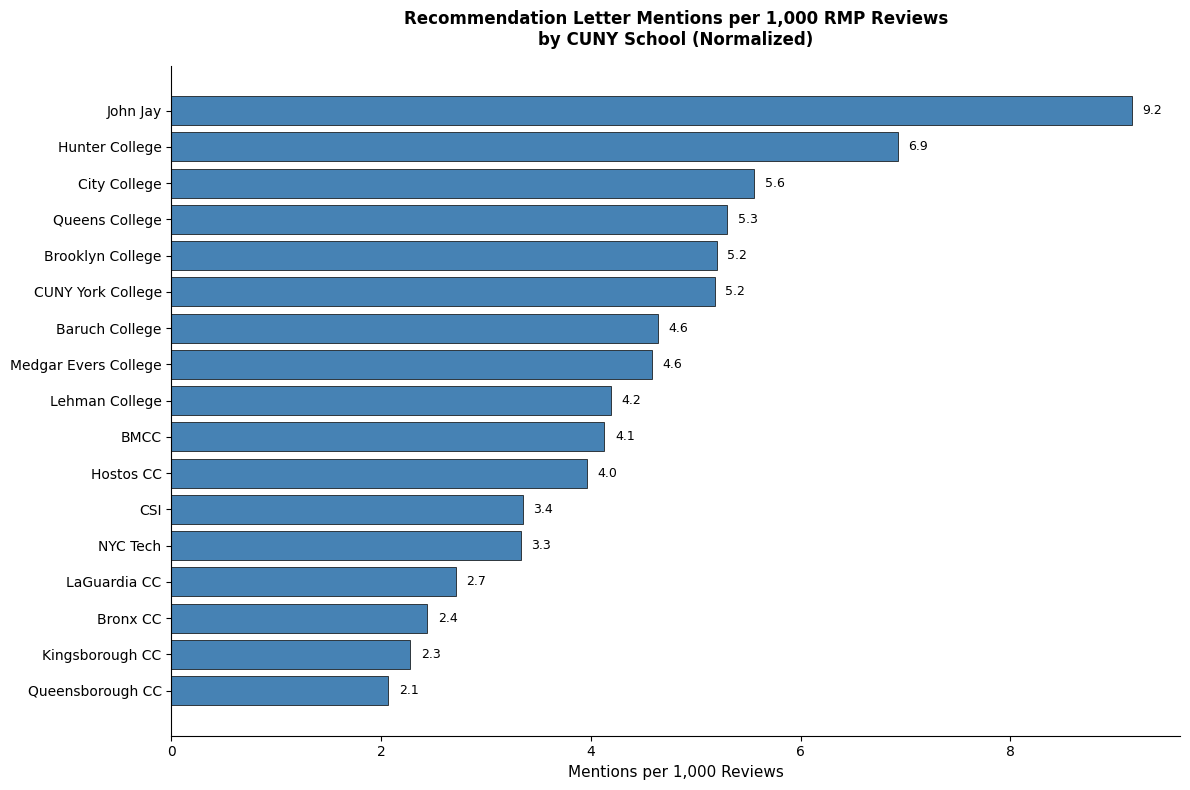

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

rec_sorted = summary_clean.sort_values('rec_per_1000', ascending=True)

bars = ax.barh(rec_sorted['school_short'],
               rec_sorted['rec_per_1000'],
               color='steelblue', edgecolor='black', linewidth=0.5)

# add value labels
for bar, val in zip(bars, rec_sorted['rec_per_1000']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)

ax.set_xlabel('Mentions per 1,000 Reviews', fontsize=11)
ax.set_title('Recommendation Letter Mentions per 1,000 RMP Reviews\nby CUNY School (Normalized)',
             fontsize=12, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('rec_letters_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
import pandas as pd
import os
import re
import string

# --- Start of added data loading and preprocessing to make cell self-contained ---
rmp_data_dir = './RMP Datasets for HIPE'

if 'all_reviews_df' not in locals() and 'all_reviews_df' not in globals():
    all_files = os.listdir(rmp_data_dir)
    csv_files = [os.path.join(rmp_data_dir, f) for f in all_files if f.endswith('.csv')]
    df_list = []

    for file in csv_files:
        try:
            df = pd.read_csv(file)
            df_list.append(df)
        except Exception as e:
            print(f"Error loading {file}: {e}")

    if df_list:
        all_reviews_df = pd.concat(df_list, ignore_index=True)
        print("Data loaded and concatenated.")
    else:
        print("No CSV files were loaded.")
else:
    print("all_reviews_df already exists.")

all_reviews_df['Comment'] = all_reviews_df['Comment'].str.lower()
PUNCT_TO_REMOVE = string.punctuation
def remove_punctuation(text):
    if pd.isna(text):
        return text
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))
all_reviews_df['Comment'] = all_reviews_df['Comment'].apply(lambda text: remove_punctuation(text))
# --- End of added data loading and preprocessing ---

rec_keywords = [
    'recommendation letter', 'rec letter', 'recommendation',
    'wrote me a letter', 'reference letter', 'fellowship',
    'dental school', 'med school', 'graduate school', 'grad school',
    'law school', 'pa school', 'premed', 'wrote me', 'reference'
]

def has_rec_letter(text):
    text = str(text).lower()
    return any(kw in text for kw in rec_keywords)

all_reviews_df['has_rec_letter'] = all_reviews_df['Comment'].apply(has_rec_letter)

print(f"Total rec letter mentions: {all_reviews_df['has_rec_letter'].sum()}")
print(f"Percentage of all reviews: {all_reviews_df['has_rec_letter'].mean()*100:.1f}%")

print("\nBy school:")
print(all_reviews_df.groupby('College')['has_rec_letter'].agg(['sum','mean']).sort_values('sum', ascending=False))

print("\nSample rec letter reviews:")
samples = all_reviews_df[all_reviews_df['has_rec_letter']][['College','Course','Comment']].head(10)
for _, row in samples.iterrows():
    print(f"\n{row['College']} | {row['Course']}")
    print(row['College'][:200])


tech_keywords = [
    'data science', 'machine learning', 'artificial intelligence', ' ai ',
    'cybersecurity', 'cyber security', 'python', 'coding', 'programming',
    'data analysis', 'deep learning', 'sql', 'analytics', 'big data',
    'computer science', 'information systems', 'software', 'tableau',
    'technology', 'blockchain', 'cloud'
]

def count_tech(text):
    text = str(text).lower()
    return sum(1 for kw in tech_keywords if kw in text)

all_reviews_df['tech_count'] = all_reviews_df['Comment'].apply(count_tech)
all_reviews_df['has_tech'] = all_reviews_df['tech_count'] > 0

print(f"\nTotal tech/AI mentions: {all_reviews_df['has_tech'].sum()}")
print(f"Percentage: {all_reviews_df['has_tech'].mean()*100:.1f}%")

print("\nBy school:")
print(all_reviews_df.groupby('College')['has_tech'].agg(['sum','mean']).sort_values('sum', ascending=False))

print("\nTop courses with tech mentions:")
tech_courses = all_reviews_df[all_reviews_df['has_tech']].groupby(
    ['College','Course'])['has_tech'].sum().sort_values(ascending=False).head(20)
print(tech_courses)

FileNotFoundError: [Errno 2] No such file or directory: './RMP Datasets for HIPE'

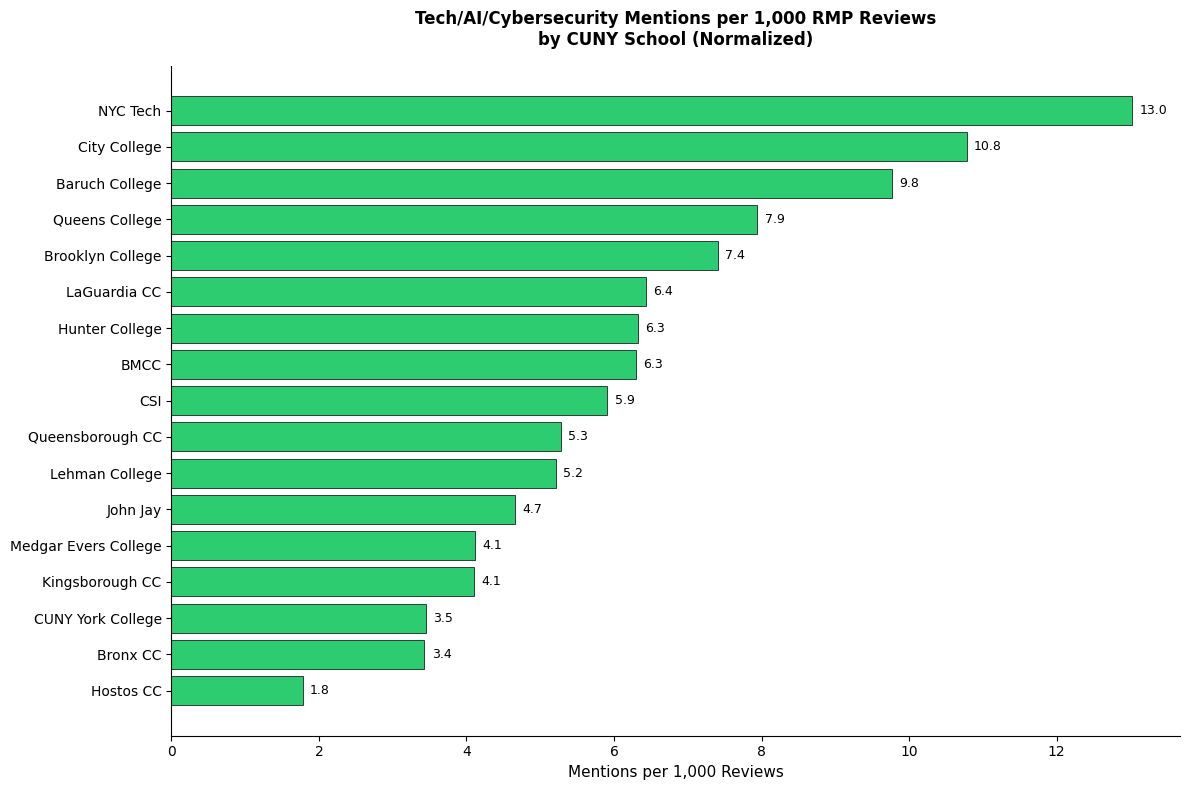

In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

tech_sorted = summary_clean.sort_values('tech_per_1000', ascending=True)

bars = ax.barh(tech_sorted['school_short'],
               tech_sorted['tech_per_1000'],
               color='#2ecc71', edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, tech_sorted['tech_per_1000']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)

ax.set_xlabel('Mentions per 1,000 Reviews', fontsize=11)
ax.set_title('Tech/AI/Cybersecurity Mentions per 1,000 RMP Reviews\nby CUNY School (Normalized)',
             fontsize=12, fontweight='bold', pad=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('tech_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
import pandas as pd
import os
import re
import string

# --- Start of added data loading and preprocessing to make cell self-contained ---
rmp_data_dir = './RMP Datasets for HIPE'

if 'all_reviews_df' not in locals() and 'all_reviews_df' not in globals():
    all_files = os.listdir(rmp_data_dir)
    csv_files = [os.path.join(rmp_data_dir, f) for f in all_files if f.endswith('.csv')]
    df_list = []

    for file in csv_files:
        try:
            df = pd.read_csv(file)
            df_list.append(df)
        except Exception as e:
            print(f"Error loading {file}: {e}")

    if df_list:
        all_reviews_df = pd.concat(df_list, ignore_index=True)
        print("Data loaded and concatenated.")
    else:
        print("No CSV files were loaded.")
else:
    print("all_reviews_df already exists.")

all_reviews_df['Comment'] = all_reviews_df['Comment'].str.lower()
PUNCT_TO_REMOVE = string.punctuation
def remove_punctuation(text):
    if pd.isna(text):
        return text
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))
all_reviews_df['Comment'] = all_reviews_df['Comment'].apply(lambda text: remove_punctuation(text))

# Define rec_keywords and tech_keywords if they aren't already defined for has_rec_letter and has_tech
# (Assuming they might be needed from previous cells not run)
rec_keywords = [
    'recommendation letter', 'rec letter', 'recommendation',
    'wrote me a letter', 'reference letter', 'fellowship',
    'dental school', 'med school', 'graduate school', 'grad school',
    'law school', 'pa school', 'premed', 'wrote me', 'reference'
]
tech_keywords = [
    'data science', 'machine learning', 'artificial intelligence', ' ai ',
    'cybersecurity', 'cyber security', 'python', 'coding', 'programming',
    'data analysis', 'deep learning', 'sql', 'analytics', 'big data',
    'computer science', 'information systems', 'software', 'tableau',
    'technology', 'blockchain', 'cloud'
]
def has_rec_letter(text):
    text = str(text).lower()
    return any(kw in text for kw in rec_keywords)
def has_tech_mention(text):
    text = str(text).lower()
    return any(kw in text for kw in tech_keywords)

if 'has_rec_letter' not in all_reviews_df.columns:
    all_reviews_df['has_rec_letter'] = all_reviews_df['Comment'].apply(has_rec_letter)
if 'has_tech' not in all_reviews_df.columns:
    all_reviews_df['has_tech'] = all_reviews_df['Comment'].apply(has_tech_mention)
# --- End of added data loading and preprocessing ---

def count_category(text, keywords):
    text = str(text).lower()
    return sum(1 for kw in keywords if kw in text)

ai_keywords = [
    'artificial intelligence',
    'machine learning',
    'neural network',
    'chatgpt',
    'generative ai',
    'large language model',
    'natural language processing',
    'nlp',
    'ai generated',
    'ai course',
    'ai class',
    'learn ai',
    'learning about ai',
    'course about ai',
    'class about ai'
    'ai in'
]

cyber_keywords = [
    'cybersecurity', 'cyber security',
    'network security', 'ethical hacking',
    'penetration testing', 'information security',
    'security certification', 'cisco security',
    'cyberattack', 'cyber attack',
    'security career', 'security field',
    'hacking class', 'hacking course'
]

tech_general_keywords = [
    'data science', 'python', 'data analysis',
    'sql', 'big data', 'computer science',
    'deep learning',
    'information systems', 'tableau',
    'blockchain', 'cloud computing',
    'r studio', 'programming language',
    'software development', 'coding assignment',
    'coding project', 'write code', 'learn to code',
    'data analytics', 'machine learning'
]

integrity_keywords = [
    'chatgpt',
    'cheating',
    'plagiarism',
    'academic integrity',
    'ai generated',
    'turnitin',
    'caught cheating',
    'cheated on',
    'academic dishonesty',
    'honor code'
]

healthcare_keywords = [
    'nursing', 'pre-med', 'premed', 'pre med',
    'medical school', 'med school', 'healthcare',
    'health care', 'pharmacy', 'pre-pharmacy', 'prepharmacy',
    'physician assistant', 'pa school', 'dental school',
    'pre-dental', 'predental', 'clinical', 'anatomy',
    'physiology', 'pathology', 'public health',
    'health sciences', 'allied health', 'nursing program',
    'health professions'
]

all_reviews_df['ai_count'] = all_reviews_df['Comment'].apply(lambda x: count_category(x, ai_keywords))
all_reviews_df['cyber_count'] = all_reviews_df['Comment'].apply(lambda x: count_category(x, cyber_keywords))
all_reviews_df['tech_count'] = all_reviews_df['Comment'].apply(lambda x: count_category(x, tech_general_keywords))

all_reviews_df['has_ai'] = all_reviews_df['ai_count'] > 0
all_reviews_df['has_cyber'] = all_reviews_df['cyber_count'] > 0
all_reviews_df['has_tech_general'] = all_reviews_df['tech_count'] > 0

print("=== TOP COURSES — AI MENTIONS ===")
ai_courses = all_reviews_df[all_reviews_df['has_ai']].groupby(
    ['College', 'Course'])['has_ai'].sum().sort_values(ascending=False).head(15)
print(ai_courses.to_string())

print("\n=== TOP COURSES — CYBERSECURITY MENTIONS ===")
cyber_courses = all_reviews_df[all_reviews_df['has_cyber']].groupby(
    ['College', 'Course'])['has_cyber'].sum().sort_values(ascending=False).head(15)
print(cyber_courses.to_string())

print("\n=== TOP COURSES — GENERAL TECH MENTIONS ===")
tech_courses = all_reviews_df[all_reviews_df['has_tech_general']].groupby(
    ['College', 'Course'])['has_tech_general'].sum().sort_values(ascending=False).head(15)
print(tech_courses.to_string())

print("\n=== TOTALS BY SCHOOL ===")
school_category = all_reviews_df.groupby('College').agg(
    total=('Comment', 'count'),
    ai=('has_ai', 'sum'),
    cyber=('has_cyber', 'sum'),
    tech=('has_tech_general', 'sum')
).reset_index()

school_category['ai_per_1000'] = (school_category['ai'] / school_category['total'] * 1000).round(2)
school_category['cyber_per_1000'] = (school_category['cyber'] / school_category['total'] * 1000).round(2)
school_category['tech_per_1000'] = (school_category['tech'] / school_category['total'] * 1000).round(2)

school_category = school_category[school_category['total'] >= 5000]

# name_fixes dictionary definition (moved from 0OyZePQ0J3od)
name_fixes = {
    'Borough of Manhattan Community College': 'BMCC',
    'John Jay College of Criminal Justice': 'John Jay',
    'College of Staten Island (CUNY - Staten Island)': 'CSI',
    'New York City College of Technology': 'NYC Tech',
    'CUNY Queens College': 'Queens College',
    'City College of New York': 'City College',
    'Queensborough Community College': 'Queensborough CC',
    'Kingsborough Community College': 'Kingsborough CC',
    'LaGuardia Community College': 'LaGuardia CC',
    'Bronx Community College': 'Bronx CC',
    'Hostos Community College': 'Hostos CC',
    'CUNY School of Professional Studies': 'CUNY SPS',
    'CUNY School of Law': 'CUNY Law',
    'CUNY Graduate Center': 'Graduate Center',
}
school_category['College'] = school_category['College'].replace(name_fixes)

print(school_category[['College', 'total', 'ai', 'ai_per_1000',
                         'cyber', 'cyber_per_1000',
                         'tech', 'tech_per_1000']].sort_values(
                             'tech_per_1000', ascending=False).to_string())

def find_matched_keywords(text, keywords):
    text = str(text).lower()
    return [kw for kw in keywords if kw in text]

for category_name, flag_col, keywords in [
    ('AI', 'has_ai', ai_keywords),
    ('Cybersecurity', 'has_cyber', cyber_keywords),
    ('General Tech', 'has_tech_general', tech_general_keywords)
]:
    print(f"\n{'='*70}")
    print(f"CATEGORY: {category_name}")
    print(f"{'='*70}")

    cat_reviews = all_reviews_df[all_reviews_df[flag_col]].copy()
    cat_reviews['matched'] = cat_reviews['Comment'].apply(
        lambda x: find_matched_keywords(x, keywords)
    )

    sample = cat_reviews.groupby('College').apply(
        lambda x: x.sample(min(2, len(x)), random_state=42)
    ).reset_index(drop=True).head(15)

    for _, row in sample.iterrows():
        print(f"\nSchool: {row['College']}")
        print(f

SyntaxError: incomplete input (4167157384.py, line 219)

In [ ]:
before = all_reviews_df[all_reviews_df['Date_parsed'] < '2023-01-01']
after = all_reviews_df[all_reviews_df['Date_parsed'] >= '2023-01-01']

print("=== BEFORE 2023 ===")
total_before = len(before)
print(f"Total reviews: {total_before}")
print(f"AI mentions: {before['has_ai'].sum()} ({before['has_ai'].sum()/total_before*1000:.2f} per 1,000)")
print(f"Integrity mentions: {before['has_integrity'].sum()} ({before['has_integrity'].sum()/total_before*1000:.2f} per 1,000)")

print("\n=== 2023 AND AFTER ===")
total_after = len(after)
print(f"Total reviews: {total_after}")
print(f"AI mentions: {after['has_ai'].sum()} ({after['has_ai'].sum()/total_after*1000:.2f} per 1,000)")
print(f"Integrity mentions: {after['has_integrity'].sum()} ({after['has_integrity'].sum()/total_after*1000:.2f} per 1,000)")

# also break down by year so you can see the trend
print("\n=== BY YEAR ===")
yearly = all_reviews_df.groupby(all_reviews_df['Date_parsed'].dt.year).agg(
    total=('Comment', 'count'),
    ai=('has_ai', 'sum'),
    integrity=('has_integrity', 'sum')
).reset_index()

yearly['ai_per_1000'] = (yearly['ai'] / yearly['total'] * 1000).round(2)
yearly['integrity_per_1000'] = (yearly['integrity'] / yearly['total'] * 1000).round(2)

print(yearly[['Date_parsed', 'total', 'ai', 'ai_per_1000',
              'integrity', 'integrity_per_1000']].to_string())

=== BEFORE 2023 ===
Total reviews: 656143
AI mentions: 38 (0.06 per 1,000)
Integrity mentions: 1083 (1.65 per 1,000)

=== 2023 AND AFTER ===
Total reviews: 69356
AI mentions: 106 (1.53 per 1,000)
Integrity mentions: 272 (3.92 per 1,000)

=== BY YEAR ===
    Date_parsed  total  ai  ai_per_1000  integrity  integrity_per_1000
0          2001     48   0         0.00          0                0.00
1          2002    420   0         0.00          0                0.00
2          2003   5687   0         0.00          6                1.06
3          2004  22066   1         0.05         25                1.13
4          2005  33452   0         0.00         31                0.93
5          2006  28774   0         0.00         30                1.04
6          2007  25549   1         0.04         26                1.02
7          2008  29502   0         0.00         35                1.19
8          2009  32881   0         0.00         45                1.37
9          2010  32554   0         0

In [ ]:

eco_yearly = all_reviews_df[
    (all_reviews_df['College'].str.contains('Baruch', na=False)) &
    (all_reviews_df['Course'] == 'ECO1001')
].copy()

eco_yearly['year'] = pd.to_datetime(eco_yearly['Date_parsed']).dt.year

eco_yearly = eco_yearly.groupby('year').agg(
    reviews=('Comment', 'count'),
    avg_quality=('Quality', 'mean'),
    integrity=('has_integrity', 'sum')
).round(2).reset_index()

print(eco_yearly)

    year  reviews  avg_quality  integrity
0   2003       28         3.02          1
1   2004      172         2.93          0
2   2005      149         2.80          0
3   2006       85         3.57          0
4   2007       63         3.52          0
5   2008       88         3.54          0
6   2009       89         3.17          0
7   2010       81         3.54          0
8   2011       54         3.69          0
9   2012       61         3.53          0
10  2013       42         3.25          0
11  2014       44         2.92          0
12  2015       43         3.36          0
13  2016       69         3.44          0
14  2017       52         3.58          0
15  2018       53         3.62          0
16  2019       47         3.60          0
17  2020       47         3.00          0
18  2021       56         3.02          1
19  2022       93         3.32          0
20  2023       71         2.96          0
21  2024       52         2.52          0
22  2025        7         3.43    

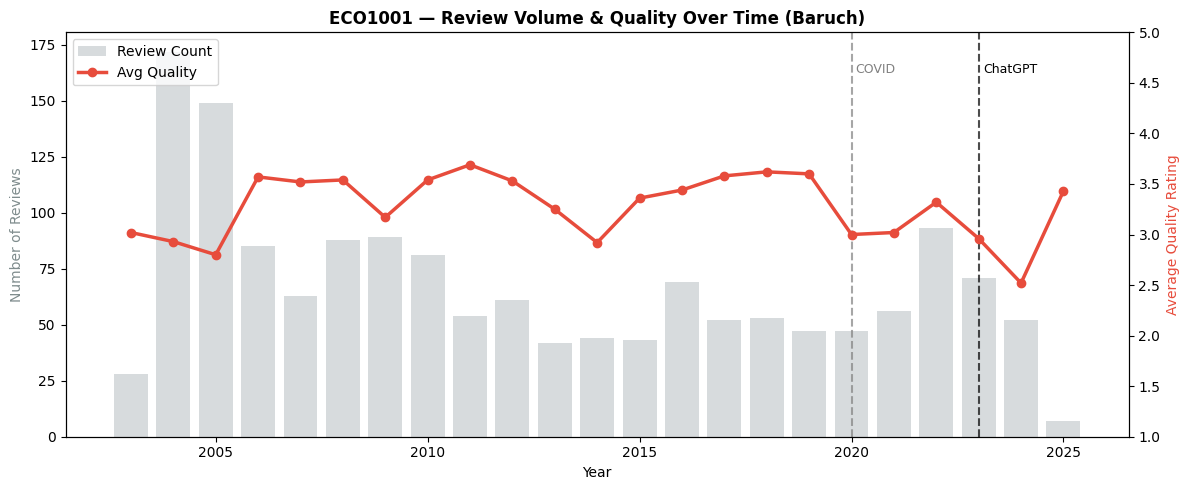

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.bar(eco_yearly['year'], eco_yearly['reviews'],
        color='#bdc3c7', alpha=0.6, label='Review Count')
ax1.set_ylabel('Number of Reviews', color='#7f8c8d')

ax2 = ax1.twinx()
ax2.plot(eco_yearly['year'], eco_yearly['avg_quality'],
         color='#e74c3c', linewidth=2.5, marker='o', label='Avg Quality')
ax2.set_ylabel('Average Quality Rating', color='#e74c3c')
ax2.set_ylim(1, 5)

ax1.axvline(x=2020, color='gray', linestyle='--', alpha=0.7)
ax1.axvline(x=2023, color='black', linestyle='--', alpha=0.7)
ax1.text(2020.1, ax1.get_ylim()[1]*0.9, 'COVID', fontsize=9, color='gray')
ax1.text(2023.1, ax1.get_ylim()[1]*0.9, 'ChatGPT', fontsize=9, color='black')

ax1.set_xlabel('Year')
ax1.set_title('ECO1001 — Review Volume & Quality Over Time (Baruch)',
              fontweight='bold')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('eco1001_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

# Organic Chemistry

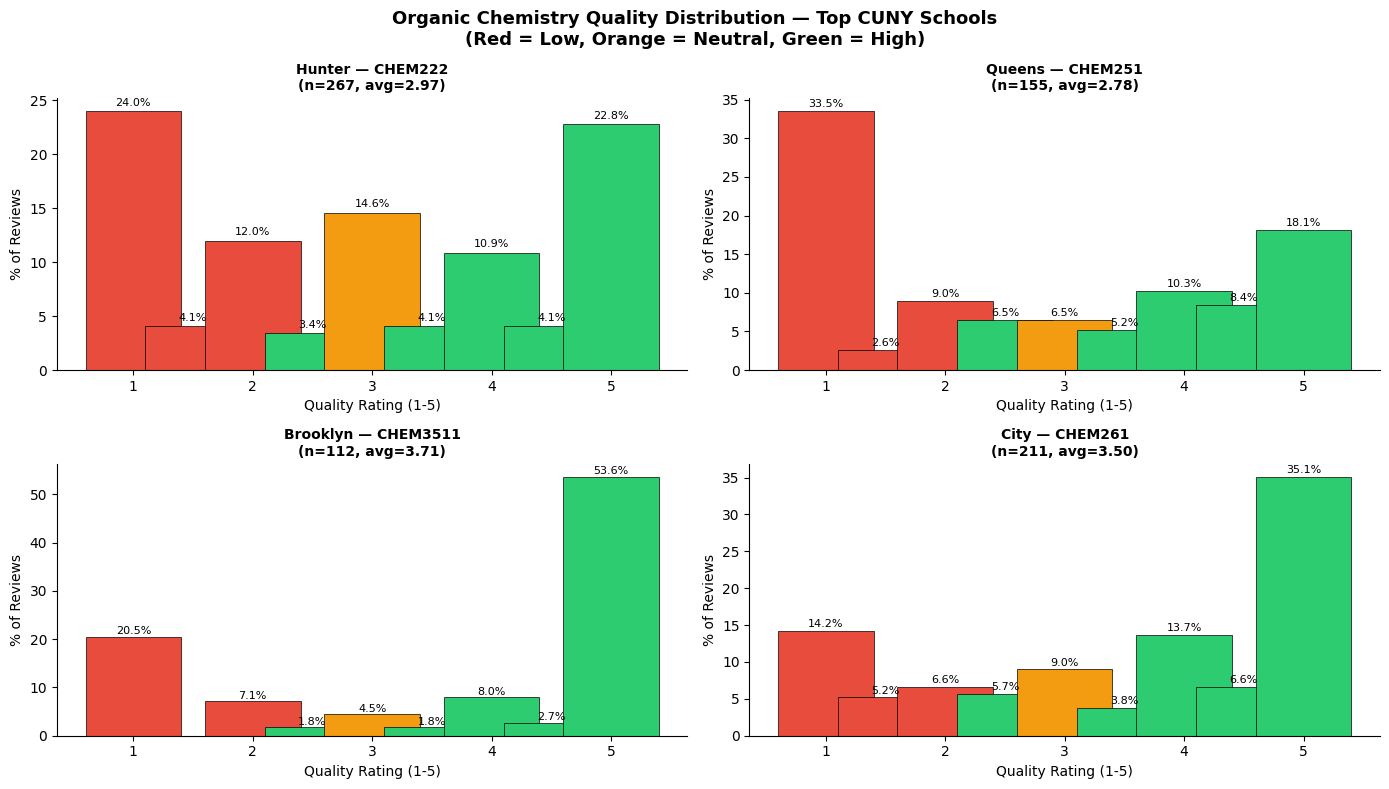

In [ ]:
orgo_courses_map = {
    'Hunter College': 'CHEM222',
    'CUNY Queens College': 'CHEM251',
    'Brooklyn College': 'CHEM3511',
    'City College of New York': 'CHEM261'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (school, course) in enumerate(orgo_courses_map.items()):
    course_reviews = all_reviews_df[
        (all_reviews_df['College'] == school) &
        (all_reviews_df['Course'] == course)
    ]

    counts = course_reviews['Quality'].value_counts().sort_index()
    total = len(course_reviews)
    pct = (counts / total * 100).round(1)

    axes[idx].bar(pct.index, pct.values,
                  color=['#e74c3c' if x <= 2 else '#f39c12' if x == 3 else '#2ecc71'
                         for x in pct.index],
                  edgecolor='black', linewidth=0.5)

    short_school = school.replace('College of New York','').replace(
        'CUNY ','').replace(' College','').strip()

    axes[idx].set_title(
        f'{short_school} — {course}\n(n={total}, avg={course_reviews["Quality"].mean():.2f})',
        fontweight='bold', fontsize=10)
    axes[idx].set_xlabel('Quality Rating (1-5)')
    axes[idx].set_ylabel('% of Reviews')
    axes[idx].set_xticks([1, 2, 3, 4, 5])
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

    for rating, val in pct.items():
        axes[idx].text(rating, val + 0.5, f'{val}%',
                      ha='center', fontsize=8)

plt.suptitle('Organic Chemistry Quality Distribution — Top CUNY Schools\n(Red = Low, Orange = Neutral, Green = High)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('orgo_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

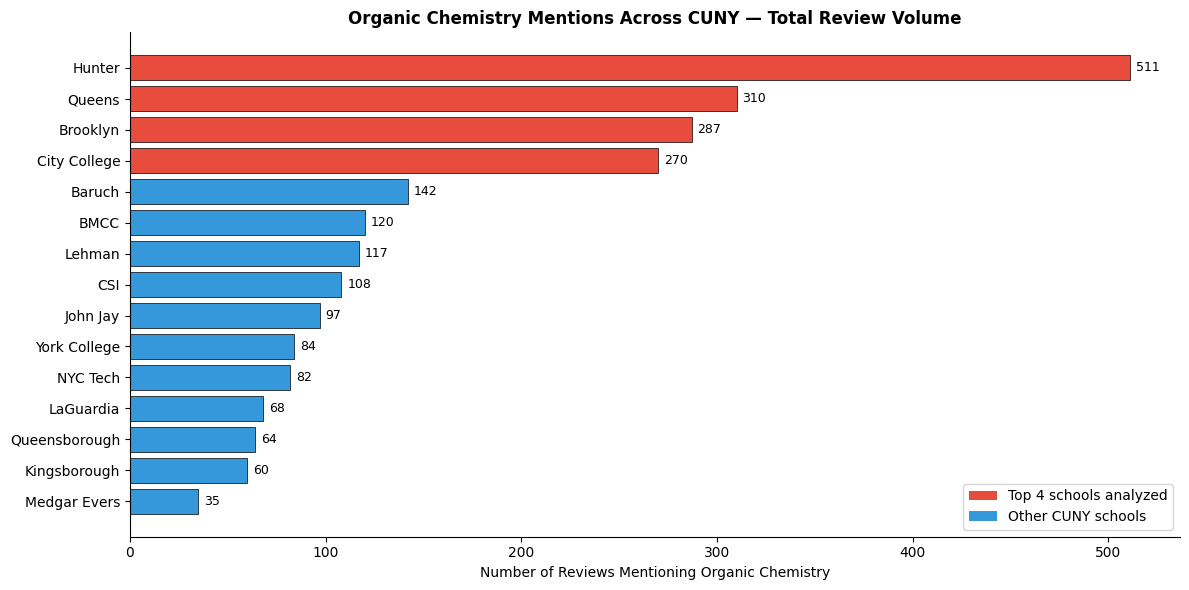

In [ ]:
orgo_counts = {
    'Hunter': 511,
    'Queens': 310,
    'Brooklyn': 287,
    'City College': 270,
    'Baruch': 142,
    'BMCC': 120,
    'Lehman': 117,
    'CSI': 108,
    'John Jay': 97,
    'York College': 84,
    'NYC Tech': 82,
    'LaGuardia': 68,
    'Queensborough': 64,
    'Kingsborough': 60,
    'Medgar Evers': 35
}

fig, ax = plt.subplots(figsize=(12, 6))

schools = list(orgo_counts.keys())
counts = list(orgo_counts.values())

colors = ['#e74c3c' if s in ['Hunter', 'Queens', 'Brooklyn', 'City College']
          else '#3498db' for s in schools]

bars = ax.barh(schools[::-1], counts[::-1], color=colors[::-1],
               edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Number of Reviews Mentioning Organic Chemistry')
ax.set_title('Organic Chemistry Mentions Across CUNY — Total Review Volume',
             fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Top 4 schools analyzed'),
                   Patch(facecolor='#3498db', label='Other CUNY schools')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('orgo_volume.png', dpi=150, bbox_inches='tight')
plt.show()

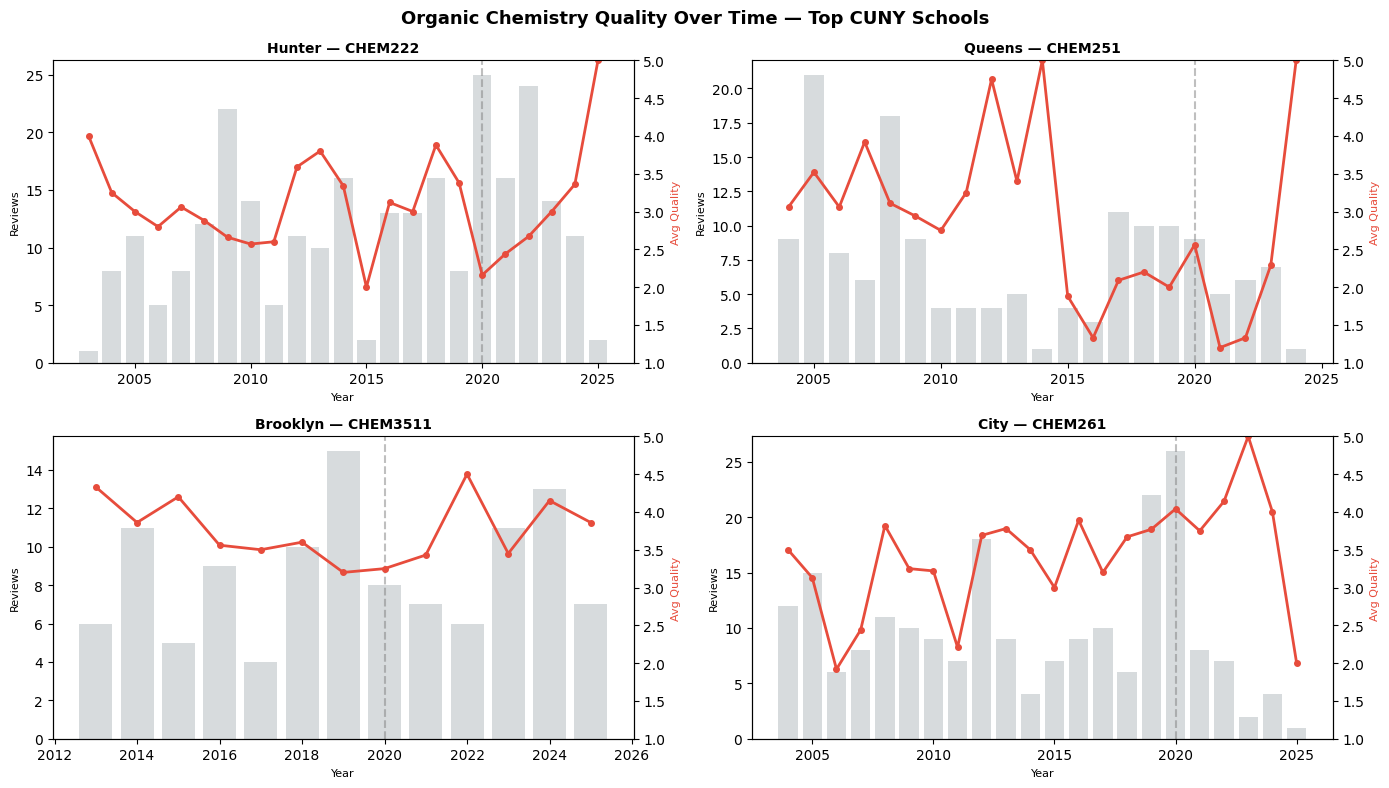

In [ ]:
orgo_schools = ['Hunter College', 'CUNY Queens College',
                'Brooklyn College', 'City College of New York']

orgo_courses = {
    'Hunter College': 'CHEM222',
    'CUNY Queens College': 'CHEM251',
    'Brooklyn College': 'CHEM3511',
    'City College of New York': 'CHEM261'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for idx, (school, course) in enumerate(orgo_courses.items()):
    yearly = all_reviews_df[
        (all_reviews_df['College'] == school) &
        (all_reviews_df['Course'] == course)
    ].copy()

    yearly['year'] = pd.to_datetime(yearly['Date_parsed']).dt.year
    yearly = yearly.groupby('year').agg(
        reviews=('Comment', 'count'),
        avg_quality=('Quality', 'mean')
    ).round(2).reset_index()

    ax1 = axes[idx]
    ax1.bar(yearly['year'], yearly['reviews'],
            color='#bdc3c7', alpha=0.6)
    ax1.set_ylabel('Reviews', fontsize=8)

    ax2 = ax1.twinx()
    ax2.plot(yearly['year'], yearly['avg_quality'],
             color='#e74c3c', linewidth=2, marker='o', markersize=4)
    ax2.set_ylim(1, 5)
    ax2.set_ylabel('Avg Quality', color='#e74c3c', fontsize=8)

    short_school = school.replace('College of New York', '').replace(
        'CUNY ', '').replace(' College', '').strip()
    ax1.set_title(f'{short_school} — {course}', fontweight='bold', fontsize=10)
    ax1.axvline(x=2020, color='gray', linestyle='--', alpha=0.5)
    ax1.set_xlabel('Year', fontsize=8)
    ax1.spines['top'].set_visible(False)

plt.suptitle('Organic Chemistry Quality Over Time — Top CUNY Schools',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('orgo_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
city_orgo = all_reviews_df[
    (all_reviews_df['College'].str.contains('City College', na=False)) &
    (all_reviews_df['Course'] == 'CHEM261')
].groupby(all_reviews_df['Date_parsed'].dt.year).agg(
    count=('Comment', 'count'),
    avg_quality=('Quality', 'mean')
).round(2).reset_index()

# Rename the column to 'Year' for clarity
city_orgo.rename(columns={'Date_parsed': 'Year'}, inplace=True)

print(city_orgo)

    Year  count  avg_quality
0   2004     12         3.50
1   2005     15         3.13
2   2006      6         1.92
3   2007      9         2.39
4   2008     11         3.82
5   2009     10         3.25
6   2010      9         3.22
7   2011      7         2.21
8   2012     18         3.69
9   2013      9         3.78
10  2014      4         3.50
11  2015      7         3.00
12  2016      9         3.89
13  2017     10         3.20
14  2018      6         3.67
15  2019     22         3.77
16  2020     26         4.04
17  2021      8         3.75
18  2022      7         4.14
19  2023      2         5.00
20  2024      4         4.00
21  2025      1         2.00


# Healthcare

In [ ]:
# ── HEALTHCARE ────────────────────────────────────────────────────────────────
healthcare_keywords = [
    'nursing', 'pre-med', 'premed', 'pre med',
    'medical school', 'med school', 'healthcare',
    'health care', 'pharmacy', 'pre-pharmacy', 'prepharmacy',
    'physician assistant', 'pa school', 'dental school',
    'pre-dental', 'predental', 'clinical', 'anatomy',
    'physiology', 'pathology', 'public health',
    'health sciences', 'allied health', 'nursing program',
    'health professions'
]

all_reviews_df['has_healthcare'] = all_reviews_df['Comment'].apply(
    lambda x: any(kw in str(x).lower() for kw in healthcare_keywords)
)

print("=== TOP COURSES — HEALTHCARE MENTIONS ===")
health_courses = all_reviews_df[all_reviews_df['has_healthcare']].groupby(
    ['College', 'Course'])['has_healthcare'].sum().sort_values(ascending=False).head(20)
print(health_courses.to_string())

print("\n=== TOTALS BY SCHOOL ===")
school_health = all_reviews_df.groupby('College').agg(
    total=('Comment', 'count'),
    healthcare=('has_healthcare', 'sum')
).reset_index()

school_health['health_per_1000'] = (
    school_health['healthcare'] / school_health['total'] * 1000
).round(2)

school_health = school_health[school_health['total'] >= 5000]
school_health['College'] = school_health['College'].replace(name_fixes)

print(school_health[['College', 'total', 'healthcare', 'health_per_1000']]
      .sort_values('health_per_1000', ascending=False).to_string())

# sample reviews
print("\n=== SAMPLE HEALTHCARE REVIEWS ===")
health_reviews = all_reviews_df[all_reviews_df['has_healthcare']].copy()
health_reviews['matched'] = health_reviews['Comment'].apply(
    lambda x: find_matched_keywords(x, healthcare_keywords)
)

sample = health_reviews.groupby('College').apply(
    lambda x: x.sample(min(2, len(x)), random_state=42)
).reset_index(drop=True).head(20)

for _, row in sample.iterrows():
    print(f"\nSchool: {row['College']}")
    print(f"Course: {row['Course']}")
    print(f"Matched: {row['matched']}")
    print(f"Review: {str(row['Comment'])[:400]}")
    print('-' * 50)

=== TOP COURSES — HEALTHCARE MENTIONS ===
College                                          Course 
Queensborough Community College                  NU101      96
                                                 NU102      88
LaGuardia Community College                      SCB203     87
Borough of Manhattan Community College           BIO425     77
                                                 BIO426     66
                                                 NUR112     63
College of Staten Island (CUNY - Staten Island)  NRS110     61
Hunter College                                   BIO100     56
College of Staten Island (CUNY - Staten Island)  NRS120     54
LaGuardia Community College                      SCB204     54
Queensborough Community College                  NU201      52
Borough of Manhattan Community College           NUR313     45
Kingsborough Community College                   BIO11      40
Borough of Manhattan Community College           NUR211     40
College of Staten I

/tmp/ipykernel_8051/338086689.py:45: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = health_reviews.groupby('College').apply(


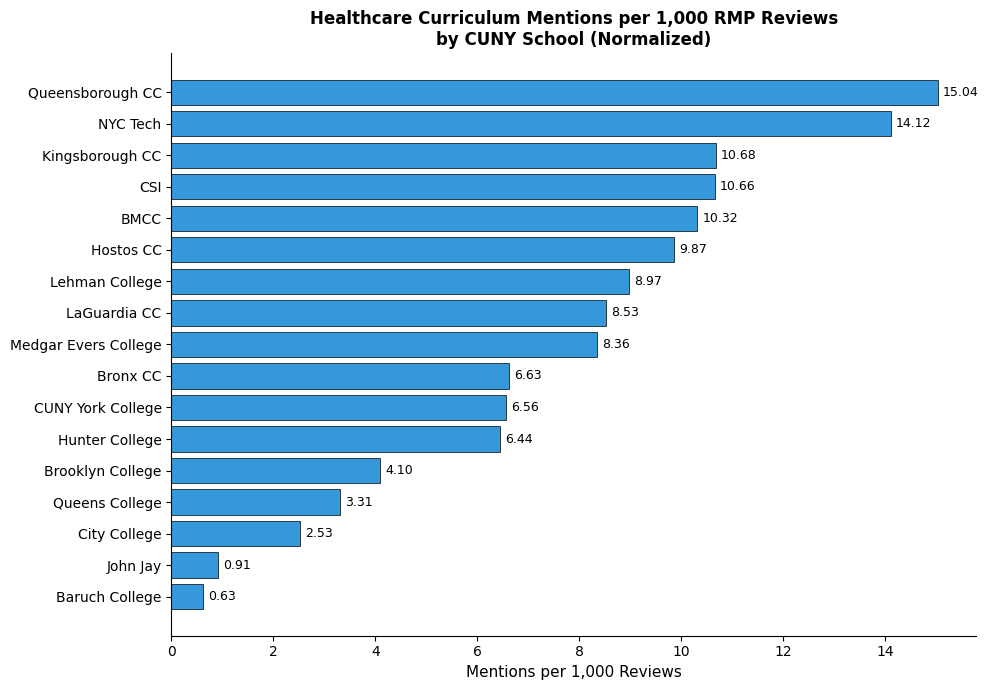

In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))

df_health = school_health.sort_values('health_per_1000', ascending=True)

bars = ax.barh(df_health['College'], df_health['health_per_1000'],
               color='#3498db', edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, df_health['health_per_1000']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

ax.set_xlabel('Mentions per 1,000 Reviews', fontsize=11)
ax.set_title('Healthcare Curriculum Mentions per 1,000 RMP Reviews\nby CUNY School (Normalized)',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('healthcare_mentions.png', dpi=150, bbox_inches='tight')
plt.show()

# Integrity Mentions - cheating, use of AI

In [ ]:
# sample reviews by era to confirm the story
print("=== 2020-2021 INTEGRITY REVIEWS (COVID era) ===")
covid_reviews = all_reviews_df[
    (all_reviews_df['Date_parsed'].dt.year.isin([2020, 2021])) &
    (all_reviews_df['has_integrity'])
][['College', 'Course', 'Date', 'Comment']].sample(15, random_state=42)

for _, row in covid_reviews.iterrows():
    print(f"\n{row['College']} | {row['Course']} | {row['Date']}")
    print(f">> {str(row['Comment'])[:300]}")
    print('-'*40)

print("\n=== 2023-2024 INTEGRITY REVIEWS (ChatGPT era) ===")
chatgpt_reviews = all_reviews_df[
    (all_reviews_df['Date_parsed'].dt.year.isin([2023, 2024])) &
    (all_reviews_df['has_integrity'])
][['College', 'Course', 'Date', 'Comment']].sample(15, random_state=42)

for _, row in chatgpt_reviews.iterrows():
    print(f"\n{row['College']} | {row['Course']} | {row['Date']}")
    print(f">> {str(row['Comment'])[:300]}")
    print('-'*40)

=== 2020-2021 INTEGRITY REVIEWS (COVID era) ===

CUNY Queens College | ANTHRO104 | May 20th, 2021
>> is there a six this professor is the most sensitive individual ever to set foot at queens college his level of commitment and ethics are unquestionable and he will never allow cheating students to excel due to lack of supervision on his part if you really want to learn and are committed to your anth
----------------------------------------

LaGuardia Community College | SCB201 | Oct 21st, 2020
>> we meet twice a week but she only ever uploads videos and doesnt teach in class she was very much more worried about cheating than making exams reasonable gave very little time for every exam weve ever have and despite the majority asking for an increase she wouldnt change anything and claimed she w
----------------------------------------

Baruch College | CIS2300 | Mar 15th, 2021
>> literally terrible with online classes she falsely accuses students of cheating with no evidence and will give 

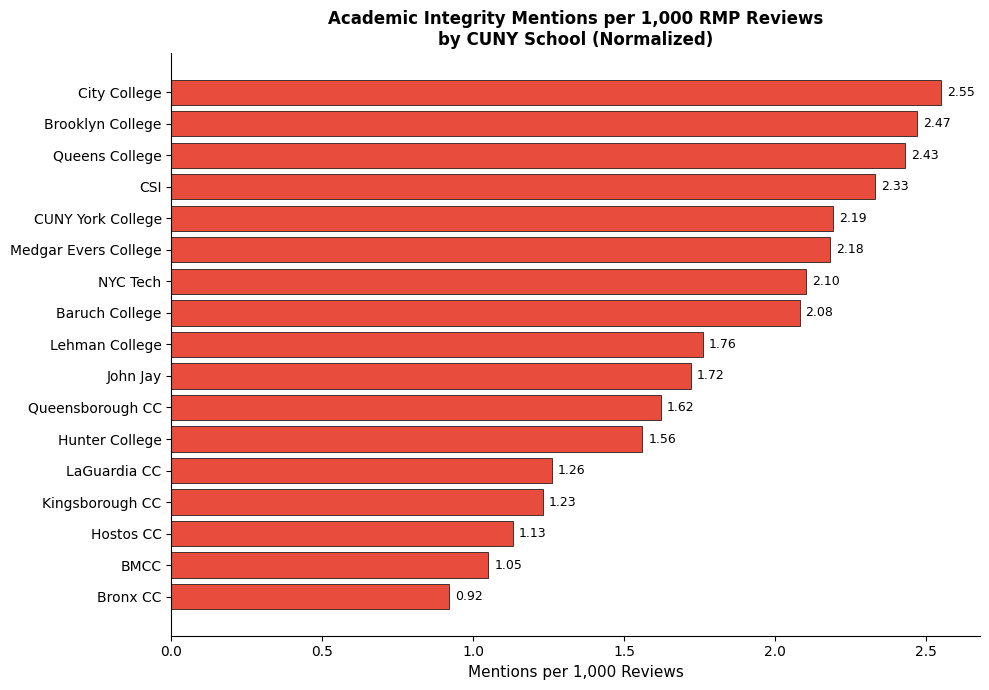

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 7))

df_integrity = school_integrity.sort_values('integrity_per_1000', ascending=True)

bars = ax.barh(df_integrity['College'], df_integrity['integrity_per_1000'],
               color='#e74c3c', edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, df_integrity['integrity_per_1000']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

ax.set_xlabel('Mentions per 1,000 Reviews', fontsize=11)
ax.set_title('Academic Integrity Mentions per 1,000 RMP Reviews\nby CUNY School (Normalized)',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('academic_integrity.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# pull actual reviews for top integrity courses
top_integrity_courses = [
    ('Baruch College', 'MGT3121'),
    ('Brooklyn College', 'PSYC2530'),
    ('City College of New York', 'BIO206'),
    ('College of Staten Island (CUNY - Staten Island)', 'CIN100'),
    ('Hunter College', 'CSCI260'),
    ('LaGuardia Community College', 'ENG101'),
]

for school, course in top_integrity_courses:
    reviews = all_reviews_df[
        (all_reviews_df['College'] == school) &
        (all_reviews_df['Course'] == course) &
        (all_reviews_df['has_integrity'])
    ]['Comment'].tolist()

    print(f"\n{'='*60}")
    print(f"{school} | {course}")
    print(f"{'='*60}")
    for r in reviews:
        print(f"\n>> {str(r)[:400]}")
        print('-'*40)


Baruch College | MGT3121

>> the class before the final i asked him if we were allowed to look up formulas on the internet he replied it is an open book online exam you are at home so what is there stopping you you will be allowed to use the internet for help but now suddenly hes failing those who use outside sources and says its cheating make up your mind prof
----------------------------------------

>> professor jain is completely irrational paranoid and corrupt he literally feeds off the pain of his students and thinks that everyone is cheating with no evidence he sincerely makes me want to go catch covid which even then i think he will still not care what happens to me
----------------------------------------

>> this was by far the worst professor i ever had at baruch hes condescending inconsiderate and extremely disorganized i cant understand a word he says cause of his heavy accent also he tried accusing the entire class of cheating  to have ppl confess so he can fail them hes

In [ ]:
# check integrity sample reviews
integrity_reviews = all_reviews_df[all_reviews_df['has_integrity']].copy()
integrity_reviews['matched'] = integrity_reviews['Comment'].apply(
    lambda x: find_matched_keywords(x, integrity_keywords)
)

sample = integrity_reviews.groupby('College').apply(
    lambda x: x.sample(min(2, len(x)), random_state=42)
).reset_index(drop=True).head(15)

for _, row in sample.iterrows():
    print(f"\nSchool: {row['College']}")
    print(f"Course: {row['Course']}")
    print(f"Matched: {row['matched']}")
    print(f"Review: {str(row['Comment'])[:300]}")
    print('-' * 50)


School: Baruch College
Course: RES3200
Matched: ['cheating']
Review: we cant use financial cal in class also no cheating sheet shes not real understand real life in re btw it seem a class for ivy league please back to real world were baruch
--------------------------------------------------

School: Baruch College
Course: ACC5400
Matched: ['cheating']
Review: very nice professor students can cheat in his class he only looks cheating students and laughing i would say he acctually is bad he let students cheating and he doesnt know how to teach i felt so bad for our class if we take cpa exams the whole class will fail the exams take his class and study your
--------------------------------------------------

School: Borough of Manhattan Community College
Course: CSC110
Matched: ['cheating']
Review: easiest professor ive ever token for csc110 if you have her as your professor dont worry about cheating dont worry about hw  she legit lets other people help each other out even if its the fin

/tmp/ipykernel_8051/3803783987.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample = integrity_reviews.groupby('College').apply(


# Technology Trends

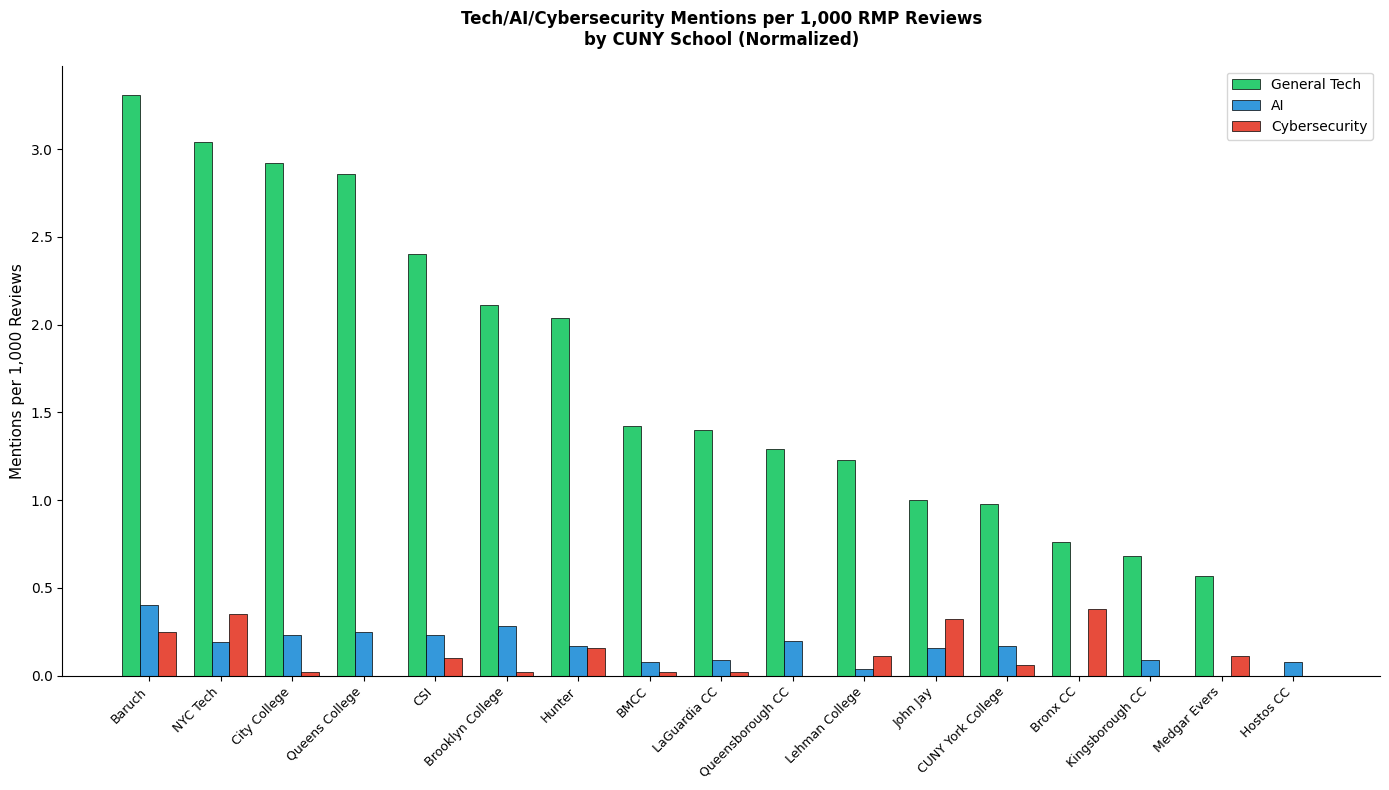

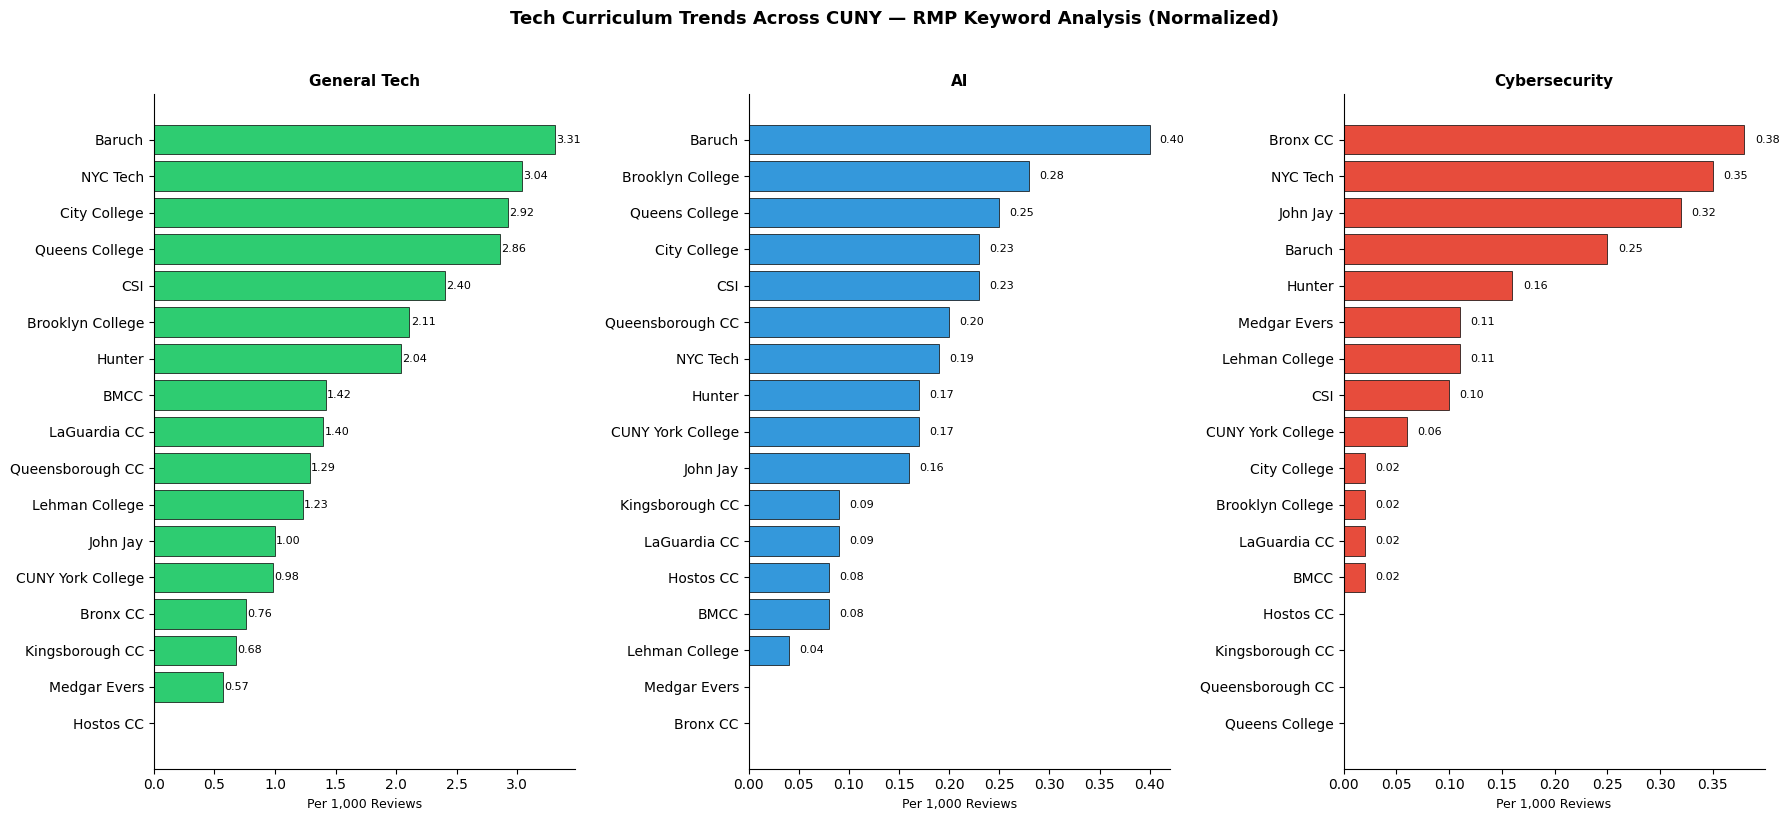

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Final data
schools = ['Baruch', 'NYC Tech', 'City College', 'Queens College', 'CSI',
           'Brooklyn College', 'Hunter', 'BMCC', 'LaGuardia CC',
           'Queensborough CC', 'Lehman College', 'John Jay',
           'CUNY York College', 'Bronx CC', 'Kingsborough CC',
           'Medgar Evers', 'Hostos CC']

ai =    [0.40, 0.19, 0.23, 0.25, 0.23, 0.28, 0.17, 0.08, 0.09,
         0.20, 0.04, 0.16, 0.17, 0.00, 0.09, 0.00, 0.08]
cyber = [0.25, 0.35, 0.02, 0.00, 0.10, 0.02, 0.16, 0.02, 0.02,
         0.00, 0.11, 0.32, 0.06, 0.38, 0.00, 0.11, 0.00]
tech =  [3.31, 3.04, 2.92, 2.86, 2.40, 2.11, 2.04, 1.42, 1.40,
         1.29, 1.23, 1.00, 0.98, 0.76, 0.68, 0.57, 0.00]

df_final = pd.DataFrame({
    'School': schools,
    'AI': ai,
    'Cybersecurity': cyber,
    'General Tech': tech
}).sort_values('General Tech', ascending=False)

# ── CHART 1: Grouped bar chart ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

x = np.arange(len(df_final))
width = 0.25

bars1 = ax.bar(x - width, df_final['General Tech'], width,
               label='General Tech', color='#2ecc71', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, df_final['AI'], width,
               label='AI', color='#3498db', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, df_final['Cybersecurity'], width,
               label='Cybersecurity', color='#e74c3c', edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(df_final['School'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mentions per 1,000 Reviews', fontsize=11)
ax.set_title('Tech/AI/Cybersecurity Mentions per 1,000 RMP Reviews\nby CUNY School (Normalized)',
             fontsize=12, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('tech_ai_cyber_grouped.png', dpi=150, bbox_inches='tight')
plt.show()

# ── CHART 2: Separate horizontal bar charts side by side ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

categories = [
    ('General Tech', tech, '#2ecc71'),
    ('AI', ai, '#3498db'),
    ('Cybersecurity', cyber, '#e74c3c')
]

for ax, (title, values, color) in zip(axes, categories):
    sorted_idx = np.argsort(values)
    sorted_schools = [schools[i] for i in sorted_idx]
    sorted_values = [values[i] for i in sorted_idx]

    bars = ax.barh(sorted_schools, sorted_values,
                   color=color, edgecolor='black', linewidth=0.5)

    for bar, val in zip(bars, sorted_values):
        if val > 0:
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{val:.2f}', va='center', fontsize=8)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Per 1,000 Reviews', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Tech Curriculum Trends Across CUNY — RMP Keyword Analysis (Normalized)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tech_ai_cyber_sidebyside.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Look at all Queens College CIS/CS courses to see what's there
queens_cs = all_reviews_df[
    (all_reviews_df['College'].str.contains('Queens', na=False)) &
    (all_reviews_df['Course'].str.contains('CS|CIS|SEC|NET|INFO|CYBER', case=False, na=False))
][['Course', 'Comment']].value_counts('Course').head(20)

print(queens_cs)

Course
CS211      277
CS313      271
CS111      256
CS220      241
CS240      199
CS212      195
CS320      182
CS343      156
CSCI111    151
CIS205     133
CSCI343    132
CS12       128
CSCI211    119
CSCI220    115
CS340      107
CSCI313    105
CS323      104
CS316       96
CS370       87
CSCI320     79
Name: count, dtype: int64


In [ ]:
# Sample reviews from Queens CS courses to see what topics come up
queens_cs_reviews = all_reviews_df[
    (all_reviews_df['College'].str.contains('Queens', na=False)) &
    (all_reviews_df['Course'].str.contains('CS|CIS|SEC|NET|CYBER', case=False, na=False))
][['Course', 'Comment']].dropna()

# Check if any mention security-adjacent terms even if not exact keyword match
security_adjacent = ['security', 'network', 'database', 'systems', 'web dev',
                      'algorithms', 'data structures', 'operating system']

for term in security_adjacent:
    count = queens_cs_reviews['Comment'].str.lower().str.contains(term).sum()
    print(f"{term}: {count} mentions")

queens_security = all_reviews_df[
    (all_reviews_df['College'].str.contains('Queens', na=False)) &
    (all_reviews_df['Course'].str.contains('CS|CIS|SEC|NET|CYBER', case=False, na=False)) &
    (all_reviews_df['Comment'].str.lower().str.contains('security', na=False))
][['Course', 'Comment']]

print(queens_security[['Course', 'Comment']].to_string())

security: 2 mentions
network: 5 mentions
database: 25 mentions
systems: 10 mentions
web dev: 6 mentions
algorithms: 39 mentions
data structures: 23 mentions
operating system: 3 mentions
         Course                                                                                                                                                                                                                                                                                                                                  Comment
415661  CSCI212                                                                                   if only cats had social security numbers you will understand once you take him good teacher except for him mixing up a few topics occasionally and sometimes errors in power point presentations which really dont matter if you are a good programmer
486595    CS352  took him for cryptography one of the hardest class ive ever taken but the most interesting one if your seme

In [ ]:
# ── 1. AI mentions — which courses and what context ──────────────────────────
print("=== AI MENTIONS BY COURSE — FULL DETAIL ===")
ai_reviews = all_reviews_df[all_reviews_df['has_ai']].copy()
ai_course_detail = ai_reviews.groupby(['College', 'Course']).agg(
    count=('Comment', 'count'),
    sample_comments=('Comment', lambda x: ' ||| '.join(x.head(2)))
).reset_index().sort_values('count', ascending=False).head(30)

for _, row in ai_course_detail.iterrows():
    print(f"\nSchool: {row['College']} | Course: {row['Course']} | Count: {row['count']}")
    for comment in row['sample_comments'].split(' ||| '):
        print(f"  >> {comment[:300]}")

# ── 2. Rec letter mentions — by department ────────────────────────────────────
print("\n\n=== REC LETTER MENTIONS BY DEPARTMENT (course prefix) ===")

rec_reviews = all_reviews_df[all_reviews_df['Comment'].str.lower().str.contains(
    'recommendation letter|rec letter|letter of recommendation|write.*letter|wrote.*letter|reference letter',
    na=False, regex=True
)].copy()

# extract course prefix
rec_reviews['dept'] = rec_reviews['Course'].str.extract(r'^([A-Za-z]+)')

rec_by_dept = rec_reviews.groupby(['College', 'dept']).size().reset_index(name='count')
rec_by_dept = rec_by_dept.sort_values('count', ascending=False).head(40)
print(rec_by_dept.to_string())

# ── 3. Top departments for rec letters at each school ────────────────────────
print("\n\n=== TOP DEPARTMENT PER SCHOOL FOR REC LETTERS ===")
for school in rec_reviews['College'].unique():
    school_recs = rec_reviews[rec_reviews['College'] == school]
    top_dept = school_recs['dept'].value_counts().head(5)
    print(f"\n{school}:")
    print(top_dept.to_string())

# ── 4. Queens College security/crypto courses specifically ───────────────────
print("\n\n=== QUEENS COLLEGE SECURITY/CRYPTO COURSES ===")
queens_sec = all_reviews_df[
    (all_reviews_df['College'].str.contains('Queens', na=False)) &
    (all_reviews_df['Comment'].str.lower().str.contains(
        'security|crypto|encryption|cipher|network security|firewall', na=False
    ))
][['Course', 'Comment']]
print(queens_sec.to_string())

# ── 5. Top courses per school per category ────────────────────────────────────
print("\n\n=== TOP 3 COURSES PER SCHOOL — AI ===")
for school in sorted(all_reviews_df['College'].unique()):
    school_ai = all_reviews_df[
        (all_reviews_df['College'] == school) &
        (all_reviews_df['has_ai'])
    ]['Course'].value_counts().head(3)
    if len(school_ai) > 0:
        print(f"\n{school}:")
        print(school_ai.to_string())

print("\n\n=== TOP 3 COURSES PER SCHOOL — CYBERSECURITY ===")
for school in sorted(all_reviews_df['College'].unique()):
    school_cyber = all_reviews_df[
        (all_reviews_df['College'] == school) &
        (all_reviews_df['has_cyber'])
    ]['Course'].value_counts().head(3)
    if len(school_cyber) > 0:
        print(f"\n{school}:")
        print(school_cyber.to_string())

print("\n\n=== TOP 3 COURSES PER SCHOOL — GENERAL TECH ===")
for school in sorted(all_reviews_df['College'].unique()):
    school_tech = all_reviews_df[
        (all_reviews_df['College'] == school) &
        (all_reviews_df['has_tech_general'])
    ]['Course'].value_counts().head(3)
    if len(school_tech) > 0:
        print(f"\n{school}:")
        print(school_tech.to_string())

=== AI MENTIONS BY COURSE — FULL DETAIL ===

School: Baruch College | Course: CIS9665 | Count: 5
  >> nlp is an amazing class honestly speaking you have heavy lecture but if you follow the class there is nothing difficult and all concepts are clearly explained if you just wanna a gpa 4 this is not your choice but if you wanna learn something which is similiar to course in tier 1 cs program nlp worth
  >> she is organized caring and responsible you will learn a lot from this nlp course worth the time and money

School: CUNY Queens College | Course: CSCI381 | Count: 3
  >> professor knows the material but cannot teach does not teach you the practical skills needed to create the programs she asks for but rather talks about the theoretical aspect of nlp only graded on 2 projects and 2 exams each exam weighing at 35 and each project weighting 15 does not give partial cre
  >> nlp is a good topic and is useful in the cs field professor alla provided a lot of information for her students doin

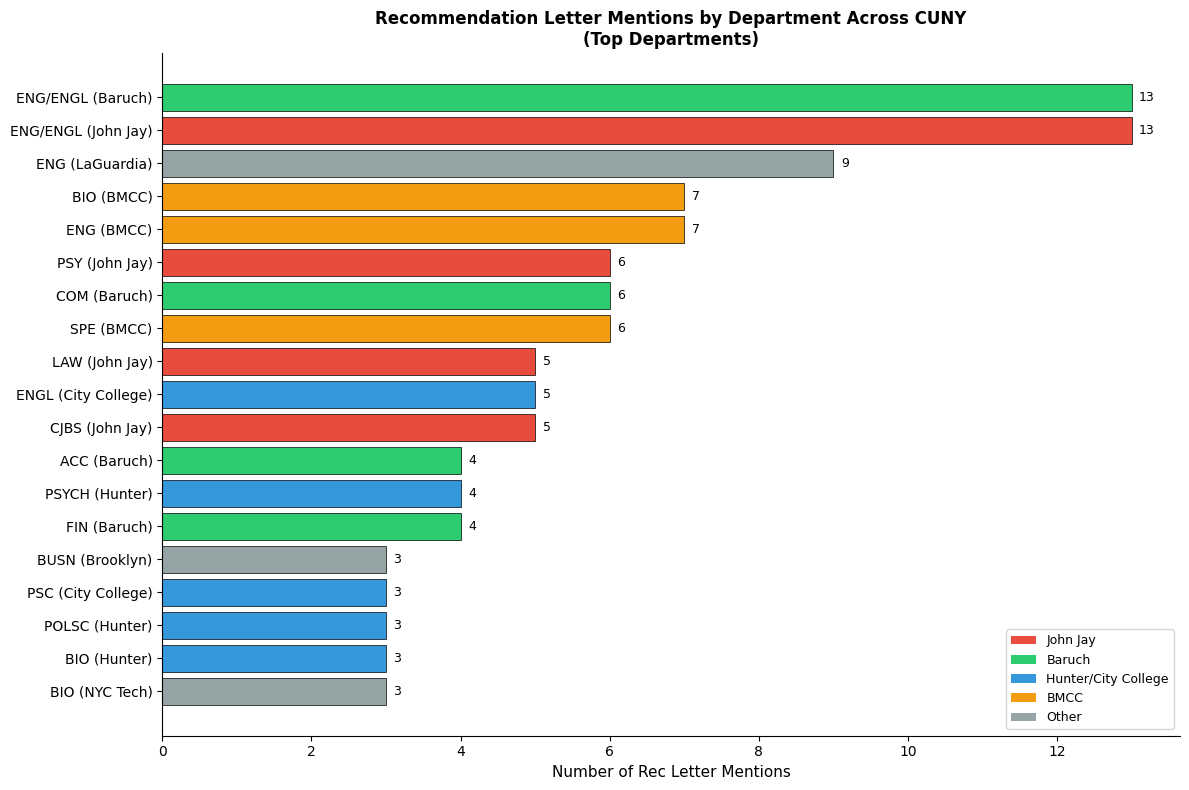

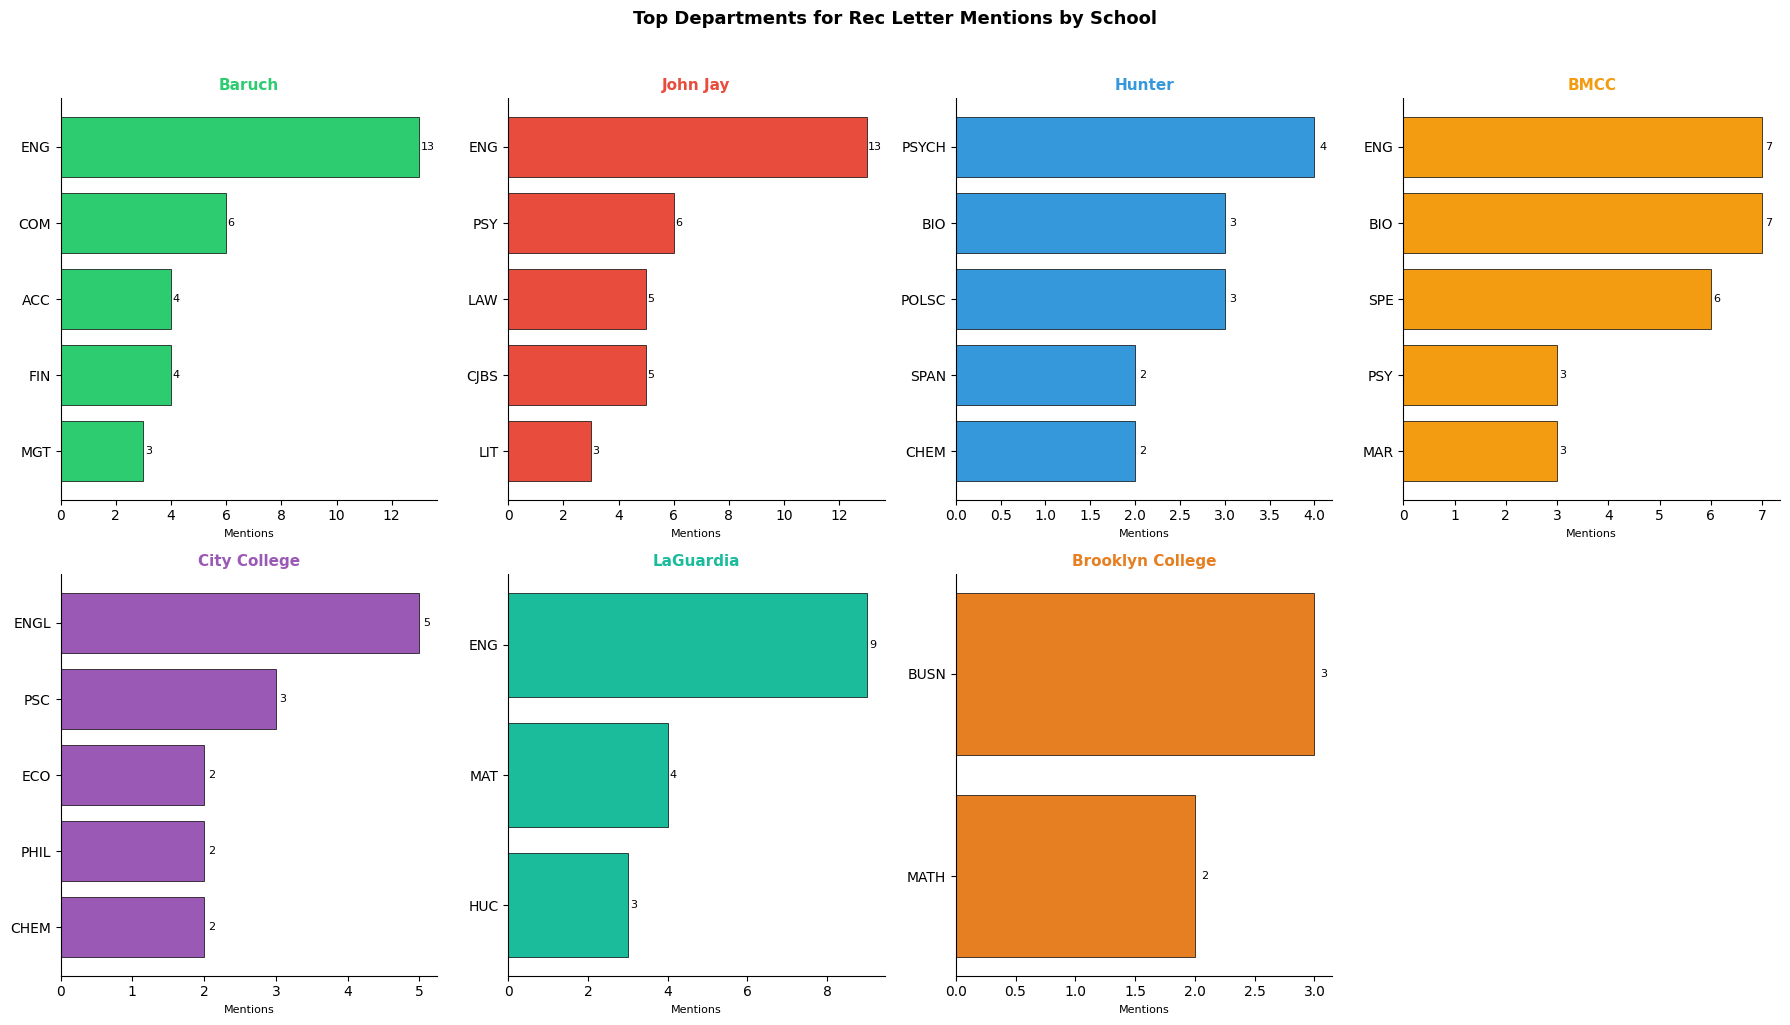

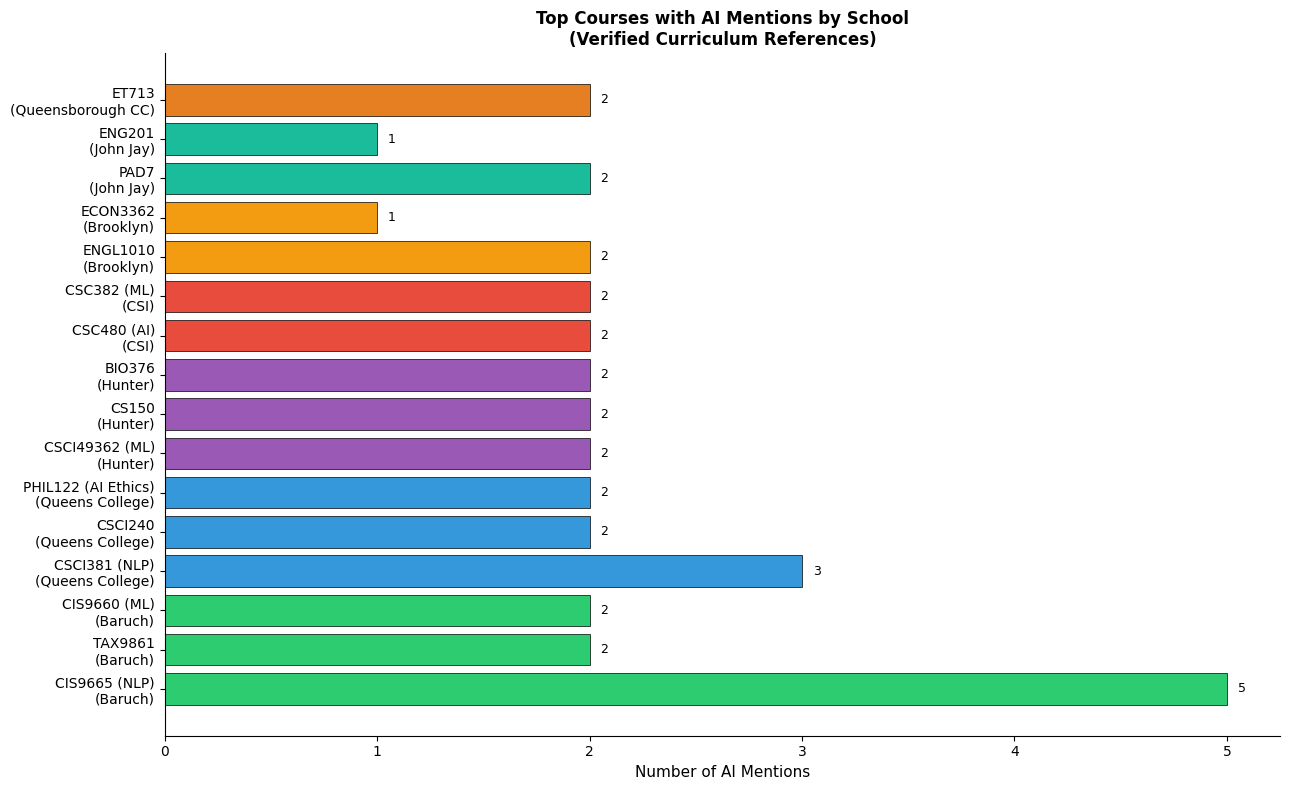

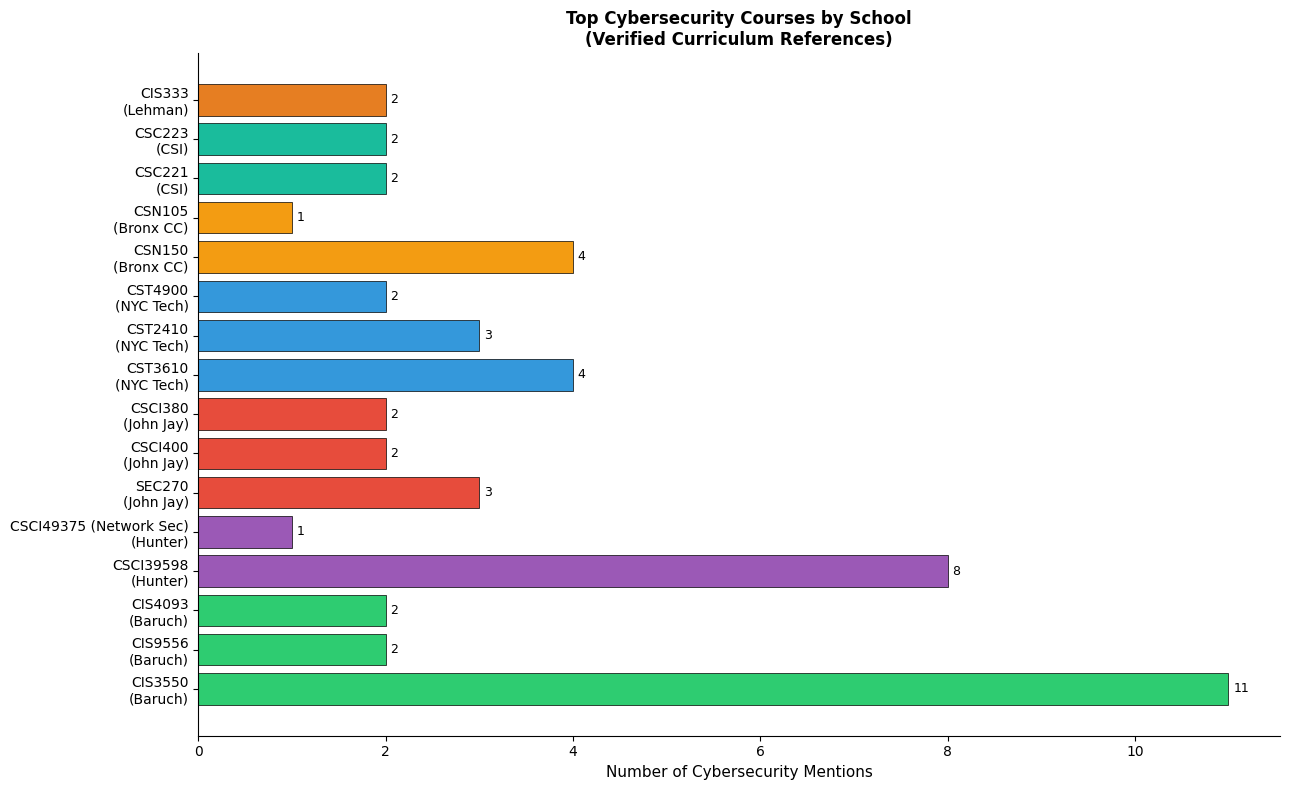

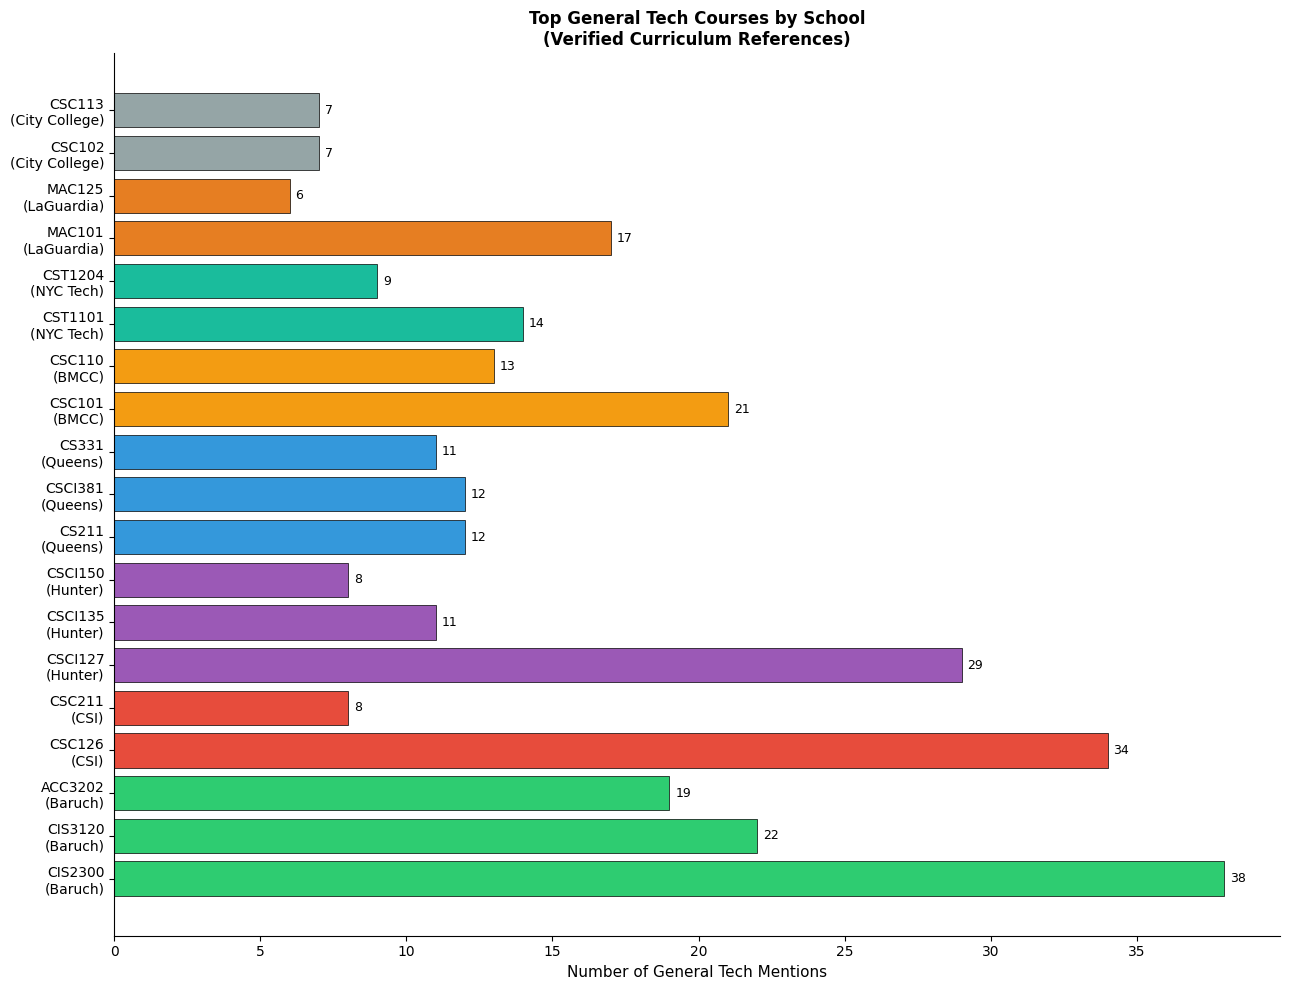

All 5 visualizations saved.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

# ── VIZ 1: Rec letters by department — top departments across all CUNY ────────
rec_dept_data = {
    'Department': ['ENG/ENGL (Baruch)', 'ENG/ENGL (John Jay)', 'ENG (LaGuardia)',
                   'BIO (BMCC)', 'ENG (BMCC)', 'SPE (BMCC)', 'PSY (John Jay)',
                   'PSYCH (Hunter)', 'LAW (John Jay)', 'CJBS (John Jay)',
                   'COM (Baruch)', 'BIO (Hunter)', 'ENGL (City College)',
                   'ACC (Baruch)', 'FIN (Baruch)', 'BIO (NYC Tech)',
                   'PSC (City College)', 'POLSC (Hunter)', 'BUSN (Brooklyn)'],
    'Count': [13, 13, 9, 7, 7, 6, 6, 4, 5, 5, 6, 3, 5, 4, 4, 3, 3, 3, 3]
}
df_rec_dept = pd.DataFrame(rec_dept_data).sort_values('Count', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if 'John Jay' in d else
          '#3498db' if any(x in d for x in ['Hunter', 'City College']) else
          '#2ecc71' if 'Baruch' in d else
          '#f39c12' if 'BMCC' in d else '#95a5a6'
          for d in df_rec_dept['Department']]

bars = ax.barh(df_rec_dept['Department'], df_rec_dept['Count'],
               color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, df_rec_dept['Count']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Number of Rec Letter Mentions', fontsize=11)
ax.set_title('Recommendation Letter Mentions by Department Across CUNY\n(Top Departments)',
             fontsize=12, fontweight='bold')

# legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='John Jay'),
                   Patch(facecolor='#2ecc71', label='Baruch'),
                   Patch(facecolor='#3498db', label='Hunter/City College'),
                   Patch(facecolor='#f39c12', label='BMCC'),
                   Patch(facecolor='#95a5a6', label='Other')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('rec_letters_by_dept.png', dpi=150, bbox_inches='tight')
plt.show()

# ── VIZ 2: Top rec letter departments per school (heatmap style) ──────────────
# ── VIZ 2: Top rec letter departments per school ─────────────────────────────
school_dept_data = [
    ('Baruch', 'ENG', 13),
    ('Baruch', 'COM', 6),
    ('Baruch', 'ACC', 4),
    ('Baruch', 'FIN', 4),
    ('Baruch', 'MGT', 3),
    ('John Jay', 'ENG', 13),
    ('John Jay', 'PSY', 6),
    ('John Jay', 'LAW', 5),
    ('John Jay', 'CJBS', 5),
    ('John Jay', 'LIT', 3),
    ('Hunter', 'PSYCH', 4),
    ('Hunter', 'BIO', 3),
    ('Hunter', 'POLSC', 3),
    ('Hunter', 'CHEM', 2),
    ('Hunter', 'SPAN', 2),
    ('BMCC', 'ENG', 7),
    ('BMCC', 'BIO', 7),
    ('BMCC', 'SPE', 6),
    ('BMCC', 'MAR', 3),
    ('BMCC', 'PSY', 3),
    ('City College', 'ENGL', 5),
    ('City College', 'PSC', 3),
    ('City College', 'PHIL', 2),
    ('City College', 'CHEM', 2),
    ('City College', 'ECO', 2),
    ('LaGuardia', 'ENG', 9),
    ('LaGuardia', 'MAT', 4),
    ('LaGuardia', 'HUC', 3),
    ('Brooklyn College', 'BUSN', 3),
    ('Brooklyn College', 'MATH', 2),
]

df_school_dept = pd.DataFrame(school_dept_data, columns=['School', 'Department', 'Count'])

school_colors = {
    'Baruch': '#2ecc71', 'John Jay': '#e74c3c', 'Hunter': '#3498db',
    'BMCC': '#f39c12', 'City College': '#9b59b6', 'LaGuardia': '#1abc9c',
    'Brooklyn College': '#e67e22'
}

schools_list = ['Baruch', 'John Jay', 'Hunter', 'BMCC', 'City College', 'LaGuardia', 'Brooklyn College']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, school in enumerate(schools_list):
    ax = axes[idx]
    school_data = df_school_dept[df_school_dept['School'] == school].sort_values('Count')

    ax.barh(school_data['Department'], school_data['Count'],
            color=school_colors[school], edgecolor='black', linewidth=0.5)

    for i, (_, row) in enumerate(school_data.iterrows()):
        ax.text(row['Count'] + 0.05, i, str(row['Count']), va='center', fontsize=8)

    ax.set_title(school, fontsize=11, fontweight='bold', color=school_colors[school])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlabel('Mentions', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Top Departments for Rec Letter Mentions by School',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rec_letters_by_school_dept.png', dpi=150, bbox_inches='tight')
plt.show()

# ── VIZ 3: AI mentions — top courses per school ───────────────────────────────
ai_course_data = {
    'School': ['Baruch', 'Baruch', 'Baruch',
               'Queens College', 'Queens College', 'Queens College',
               'Hunter', 'Hunter', 'Hunter',
               'CSI', 'CSI',
               'Brooklyn', 'Brooklyn',
               'John Jay', 'John Jay',
               'Queensborough CC'],
    'Course': ['CIS9665 (NLP)', 'TAX9861', 'CIS9660 (ML)',
               'CSCI381 (NLP)', 'CSCI240', 'PHIL122 (AI Ethics)',
               'CSCI49362 (ML)', 'CS150', 'BIO376',
               'CSC480 (AI)', 'CSC382 (ML)',
               'ENGL1010', 'ECON3362',
               'PAD7', 'ENG201',
               'ET713'],
    'Count': [5, 2, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2]
}
df_ai_courses = pd.DataFrame(ai_course_data)

fig, ax = plt.subplots(figsize=(13, 8))
school_color_map = {
    'Baruch': '#2ecc71', 'Queens College': '#3498db', 'Hunter': '#9b59b6',
    'CSI': '#e74c3c', 'Brooklyn': '#f39c12', 'John Jay': '#1abc9c',
    'Queensborough CC': '#e67e22'
}
colors = [school_color_map[s] for s in df_ai_courses['School']]

bars = ax.barh(df_ai_courses['Course'] + '\n(' + df_ai_courses['School'] + ')',
               df_ai_courses['Count'], color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, df_ai_courses['Count']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Number of AI Mentions', fontsize=11)
ax.set_title('Top Courses with AI Mentions by School\n(Verified Curriculum References)',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('ai_top_courses.png', dpi=150, bbox_inches='tight')
plt.show()

# ── VIZ 4: Cybersecurity top courses per school ───────────────────────────────
cyber_course_data = {
    'School': ['Baruch', 'Baruch', 'Baruch',
               'Hunter', 'Hunter',
               'John Jay', 'John Jay', 'John Jay',
               'NYC Tech', 'NYC Tech', 'NYC Tech',
               'Bronx CC', 'Bronx CC',
               'CSI', 'CSI',
               'Lehman'],
    'Course': ['CIS3550', 'CIS9556', 'CIS4093',
               'CSCI39598', 'CSCI49375 (Network Sec)',
               'SEC270', 'CSCI400', 'CSCI380',
               'CST3610', 'CST2410', 'CST4900',
               'CSN150', 'CSN105',
               'CSC221', 'CSC223',
               'CIS333'],
    'Count': [11, 2, 2, 8, 1, 3, 2, 2, 4, 3, 2, 4, 1, 2, 2, 2]
}
df_cyber_courses = pd.DataFrame(cyber_course_data)

school_color_map2 = {
    'Baruch': '#2ecc71', 'Hunter': '#9b59b6', 'John Jay': '#e74c3c',
    'NYC Tech': '#3498db', 'Bronx CC': '#f39c12', 'CSI': '#1abc9c', 'Lehman': '#e67e22'
}
colors2 = [school_color_map2[s] for s in df_cyber_courses['School']]

fig, ax = plt.subplots(figsize=(13, 8))
bars = ax.barh(df_cyber_courses['Course'] + '\n(' + df_cyber_courses['School'] + ')',
               df_cyber_courses['Count'], color=colors2, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, df_cyber_courses['Count']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Number of Cybersecurity Mentions', fontsize=11)
ax.set_title('Top Cybersecurity Courses by School\n(Verified Curriculum References)',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('cyber_top_courses.png', dpi=150, bbox_inches='tight')
plt.show()

# ── VIZ 5: General tech top courses per school ────────────────────────────────
tech_course_data = {
    'School': ['Baruch', 'Baruch', 'Baruch',
               'CSI', 'CSI',
               'Hunter', 'Hunter', 'Hunter',
               'Queens', 'Queens', 'Queens',
               'BMCC', 'BMCC',
               'NYC Tech', 'NYC Tech',
               'LaGuardia', 'LaGuardia',
               'City College', 'City College'],
    'Course': ['CIS2300', 'CIS3120', 'ACC3202',
               'CSC126', 'CSC211',
               'CSCI127', 'CSCI135', 'CSCI150',
               'CS211', 'CSCI381', 'CS331',
               'CSC101', 'CSC110',
               'CST1101', 'CST1204',
               'MAC101', 'MAC125',
               'CSC102', 'CSC113'],
    'Count': [38, 22, 19, 34, 8, 29, 11, 8, 12, 12, 11, 21, 13, 14, 9, 17, 6, 7, 7]
}
df_tech_courses = pd.DataFrame(tech_course_data)

school_color_map3 = {
    'Baruch': '#2ecc71', 'CSI': '#e74c3c', 'Hunter': '#9b59b6',
    'Queens': '#3498db', 'BMCC': '#f39c12', 'NYC Tech': '#1abc9c',
    'LaGuardia': '#e67e22', 'City College': '#95a5a6'
}
colors3 = [school_color_map3[s] for s in df_tech_courses['School']]

fig, ax = plt.subplots(figsize=(13, 10))
bars = ax.barh(df_tech_courses['Course'] + '\n(' + df_tech_courses['School'] + ')',
               df_tech_courses['Count'], color=colors3, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, df_tech_courses['Count']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

ax.set_xlabel('Number of General Tech Mentions', fontsize=11)
ax.set_title('Top General Tech Courses by School\n(Verified Curriculum References)',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('tech_top_courses.png', dpi=150, bbox_inches='tight')
plt.show()

print("All 5 visualizations saved.")

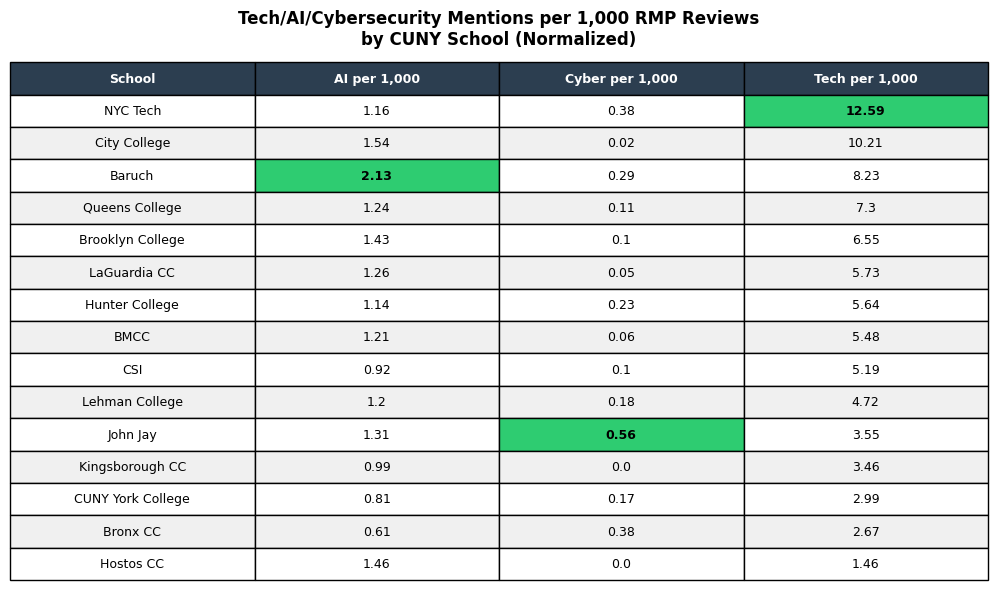

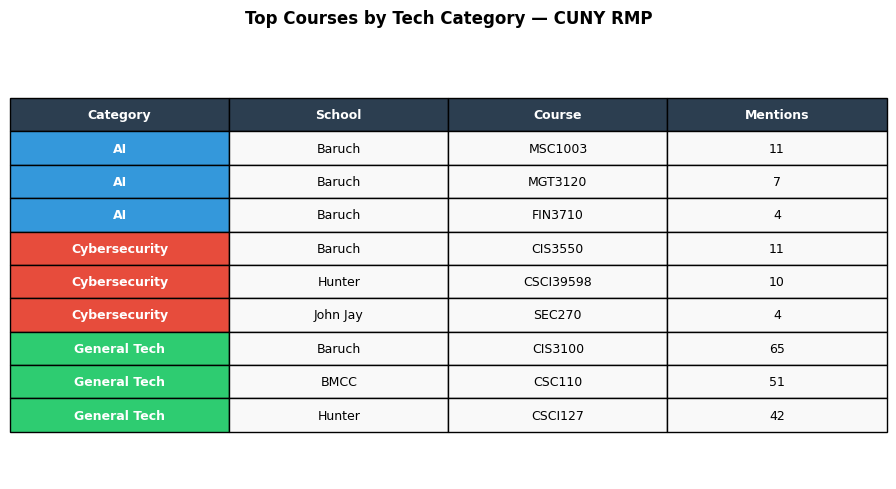

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ── TABLE 1: Three-column summary by school ──────────────────────────────────
table1_data = {
    'School': ['NYC Tech', 'City College', 'Baruch', 'Queens College',
               'Brooklyn College', 'LaGuardia CC', 'Hunter College',
               'BMCC', 'CSI', 'Lehman College', 'John Jay',
               'Kingsborough CC', 'CUNY York College', 'Bronx CC', 'Hostos CC'],
    'AI per 1,000': [1.16, 1.54, 2.13, 1.24, 1.43, 1.26, 1.14,
                     1.21, 0.92, 1.20, 1.31, 0.99, 0.81, 0.61, 1.46],
    'Cyber per 1,000': [0.38, 0.02, 0.29, 0.11, 0.10, 0.05, 0.23,
                        0.06, 0.10, 0.18, 0.56, 0.00, 0.17, 0.38, 0.00],
    'Tech per 1,000': [12.59, 10.21, 8.23, 7.30, 6.55, 5.73, 5.64,
                       5.48, 5.19, 4.72, 3.55, 3.46, 2.99, 2.67, 1.46]
}

df_table1 = pd.DataFrame(table1_data).sort_values('Tech per 1,000', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

table = ax.table(
    cellText=df_table1.values,
    colLabels=df_table1.columns,
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.8)

# header styling
for j in range(len(df_table1.columns)):
    table[0, j].set_facecolor('#2c3e50')
    table[0, j].set_text_props(color='white', fontweight='bold')

# alternating row colors
for i in range(1, len(df_table1) + 1):
    for j in range(len(df_table1.columns)):
        if i % 2 == 0:
            table[i, j].set_facecolor('#f0f0f0')
        else:
            table[i, j].set_facecolor('white')

# highlight highest value per column in green
for col_idx, col in enumerate(['AI per 1,000', 'Cyber per 1,000', 'Tech per 1,000']):
    max_val = df_table1[col].max()
    max_row = df_table1[col].tolist().index(max_val) + 1
    table[max_row, col_idx + 1].set_facecolor('#2ecc71')
    table[max_row, col_idx + 1].set_text_props(fontweight='bold')

ax.set_title('Tech/AI/Cybersecurity Mentions per 1,000 RMP Reviews\nby CUNY School (Normalized)',
             fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('tech_summary_table.png', dpi=150, bbox_inches='tight')
plt.show()


# ── TABLE 2: Top courses per category ────────────────────────────────────────
table2_data = {
    'Category': ['AI', 'AI', 'AI', 'Cybersecurity', 'Cybersecurity',
                 'Cybersecurity', 'General Tech', 'General Tech', 'General Tech'],
    'School': ['Baruch', 'Baruch', 'Baruch',
               'Baruch', 'Hunter', 'John Jay',
               'Baruch', 'BMCC', 'Hunter'],
    'Course': ['MSC1003', 'MGT3120', 'FIN3710',
               'CIS3550', 'CSCI39598', 'SEC270',
               'CIS3100', 'CSC110', 'CSCI127'],
    'Mentions': [11, 7, 4, 11, 10, 4, 65, 51, 42]
}

df_table2 = pd.DataFrame(table2_data)

fig, ax = plt.subplots(figsize=(9, 5))
ax.axis('off')

table2 = ax.table(
    cellText=df_table2.values,
    colLabels=df_table2.columns,
    cellLoc='center',
    loc='center'
)

table2.auto_set_font_size(False)
table2.set_fontsize(9)
table2.scale(1.2, 1.8)

# header styling
for j in range(len(df_table2.columns)):
    table2[0, j].set_facecolor('#2c3e50')
    table2[0, j].set_text_props(color='white', fontweight='bold')

# color code by category
category_colors = {
    'AI': '#3498db',
    'Cybersecurity': '#e74c3c',
    'General Tech': '#2ecc71'
}

for i in range(1, len(df_table2) + 1):
    category = df_table2.iloc[i-1]['Category']
    color = category_colors.get(category, 'white')
    table2[i, 0].set_facecolor(color)
    table2[i, 0].set_text_props(color='white', fontweight='bold')
    for j in range(1, len(df_table2.columns)):
        table2[i, j].set_facecolor('#f9f9f9')

ax.set_title('Top Courses by Tech Category — CUNY RMP',
             fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('top_courses_table.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
import pandas as pd
import os
import re
import string

# --- Start of added data loading and preprocessing to make cell self-contained ---
rmp_data_dir = './RMP Datasets for HIPE'

if 'all_reviews_df' not in locals() and 'all_reviews_df' not in globals():
    all_files = os.listdir(rmp_data_dir)
    csv_files = [os.path.join(rmp_data_dir, f) for f in all_files if f.endswith('.csv')]
    df_list = []

    for file in csv_files:
        try:
            df = pd.read_csv(file)
            df_list.append(df)
        except Exception as e:
            print(f"Error loading {file}: {e}")

    if df_list:
        all_reviews_df = pd.concat(df_list, ignore_index=True)
        print("Data loaded and concatenated.")
    else:
        print("No CSV files were loaded.")
else:
    print("all_reviews_df already exists.")

all_reviews_df['Comment'] = all_reviews_df['Comment'].str.lower()
PUNCT_TO_REMOVE = string.punctuation
def remove_punctuation(text):
    if pd.isna(text):
        return text
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))
all_reviews_df['Comment'] = all_reviews_df['Comment'].apply(lambda text: remove_punctuation(text))

# Define keywords required for this cell's categories
ai_keywords = [
    'artificial intelligence', 'machine learning', 'neural network', 'chatgpt',
    'generative ai', 'large language model', 'natural language processing', 'nlp',
    'ai generated', 'ai course', 'ai class', 'learn ai', 'learning about ai',
    'course about ai', 'class about ai', 'ai in'
]
cyber_keywords = [
    'cybersecurity', 'cyber security', 'network security', 'ethical hacking',
    'penetration testing', 'information security', 'security certification',
    'cisco security', 'cyberattack', 'cyber attack', 'security career',
    'security field', 'hacking class', 'hacking course'
]
tech_general_keywords = [
    'data science', 'python', 'data analysis', 'sql', 'big data',
    'computer science', 'deep learning', 'information systems', 'tableau',
    'blockchain', 'cloud computing', 'r studio', 'programming language',
    'software development', 'coding assignment', 'coding project', 'write code',
    'learn to code', 'data analytics', 'machine learning'
]

# Re-create has_ai, has_cyber, has_tech_general if not already present
def count_category(text, keywords):
    text = str(text).lower()
    return sum(1 for kw in keywords if kw in text)

if 'has_ai' not in all_reviews_df.columns:
    all_reviews_df['ai_count'] = all_reviews_df['Comment'].apply(lambda x: count_category(x, ai_keywords))
    all_reviews_df['has_ai'] = all_reviews_df['ai_count'] > 0
if 'has_cyber' not in all_reviews_df.columns:
    all_reviews_df['cyber_count'] = all_reviews_df['Comment'].apply(lambda x: count_category(x, cyber_keywords))
    all_reviews_df['has_cyber'] = all_reviews_df['cyber_count'] > 0
if 'has_tech_general' not in all_reviews_df.columns:
    all_reviews_df['tech_count'] = all_reviews_df['Comment'].apply(lambda x: count_category(x, tech_general_keywords))
    all_reviews_df['has_tech_general'] = all_reviews_df['tech_count'] > 0
# --- End of added data loading and preprocessing ---

categories = {
    'AI': ('has_ai', ai_keywords),
    'Cybersecurity': ('has_cyber', cyber_keywords),
    'General Tech': ('has_tech_general', tech_general_keywords)
}

def find_matched_keywords(text, keywords):
    text = str(text).lower()
    return [kw for kw in keywords if kw in text]

for category_name, (flag_col, keywords) in categories.items():
    print(f"\n{'='*70}")
    print(f"CATEGORY: {category_name}")
    print(f"{'='*70}")

    cat_reviews = all_reviews_df[all_reviews_df[flag_col]].copy()
    cat_reviews['matched_keywords'] = cat_reviews['Comment'].apply(find_matched_keywords)

    sample = cat_reviews.groupby('College').apply(
        lambda x: x.sample(min(2, len(x)))
    ).reset_index(drop=True).head(15)

    for _, row in sample.iterrows():
        print(f"\nSchool: {row['College']}")
        print(f"Course: {row['Course']}")
        print(f"Matched: {row['matched_keywords']}")
        print(f"Review: {str(row['Comment'])[:400]}")
        print('-' * 50)

FileNotFoundError: [Errno 2] No such file or directory: './RMP Datasets for HIPE'

# Pathway Courses

In [ ]:
gateway_courses = ['ENG2150', 'MSC1003', 'ENG2850', 'PHI1600', 'MTH2610', 'ECO1001', 'STA2000']
MIN_REVIEWS = 10  # only consider professors with at least 10 reviews

print("=== PROFESSOR QUALITY COMPARISON BY COURSE ===")
for course in gateway_courses:
    course_reviews = all_reviews_df[
        (all_reviews_df['College'].str.contains('Baruch', na=False)) &
        (all_reviews_df['Course'] == course)
    ].copy()

    if course_reviews.empty:
        continue

    prof_stats = course_reviews.groupby('Professor Name').agg(
        count=('Quality', 'count'),
        avg_quality=('Quality', 'mean'),
        avg_difficulty=('Difficulty', 'mean')
    ).round(2).reset_index()

    # filter to professors with enough reviews
    prof_stats = prof_stats[prof_stats['count'] >= MIN_REVIEWS]

    if prof_stats.empty:
        print(f"\n{course} — not enough reviews per professor")
        continue

    worst = prof_stats.loc[prof_stats['avg_quality'].idxmin()]
    best = prof_stats.loc[prof_stats['avg_quality'].idxmax()]

    print(f"\n{'='*50}")
    print(f"COURSE: {course}")
    print(f"{'='*50}")
    print(f"LOWEST:  {worst['Professor Name']} | Quality: {worst['avg_quality']} | Difficulty: {worst['avg_difficulty']} | Reviews: {worst['count']}")
    print(f"HIGHEST: {best['Professor Name']} | Quality: {best['avg_quality']} | Difficulty: {best['avg_difficulty']} | Reviews: {best['count']}")

=== PROFESSOR QUALITY COMPARISON BY COURSE ===

COURSE: ENG2150
LOWEST:  Matthew Christian | Quality: 1.33 | Difficulty: 4.58 | Reviews: 12
HIGHEST: Anne Grevenitis | Quality: 5.0 | Difficulty: 1.5 | Reviews: 10

COURSE: MSC1003
LOWEST:  Nathan Fletcher | Quality: 2.8 | Difficulty: 3.4 | Reviews: 10
HIGHEST: Emily Travaline | Quality: 4.96 | Difficulty: 2.42 | Reviews: 24

COURSE: ENG2850
LOWEST:  Camilo Roldan | Quality: 1.58 | Difficulty: 4.75 | Reviews: 12
HIGHEST: Michael Healy | Quality: 4.93 | Difficulty: 2.07 | Reviews: 14

COURSE: PHI1600
LOWEST:  Boris Maizel | Quality: 2.3 | Difficulty: 3.6 | Reviews: 35
HIGHEST: James Lennox | Quality: 5.0 | Difficulty: 1.5 | Reviews: 14

COURSE: MTH2610
LOWEST:  Jakob Reich | Quality: 1.82 | Difficulty: 4.18 | Reviews: 17
HIGHEST: Peter Gregory | Quality: 4.64 | Difficulty: 2.27 | Reviews: 11

COURSE: ECO1001
LOWEST:  Miguel Vazquez | Quality: 1.3 | Difficulty: 4.4 | Reviews: 10
HIGHEST: Archil Dvalishvili | Quality: 4.62 | Difficulty: 2.95

In [ ]:
gateway_courses = ['ENG2150', 'MSC1003', 'ENG2850', 'PHI1600', 'MTH2610', 'ECO1001', 'STA2000']
MIN_REVIEWS = 10

for course in gateway_courses:
    course_reviews = all_reviews_df[
        (all_reviews_df['College'].str.contains('Baruch', na=False)) &
        (all_reviews_df['Course'] == course)
    ].copy()

    if course_reviews.empty:
        continue

    prof_stats = course_reviews.groupby('Professor Name').agg(
        count=('Quality', 'count'),
        avg_quality=('Quality', 'mean'),
        avg_difficulty=('Difficulty', 'mean')
    ).round(2).reset_index()

    prof_stats = prof_stats[prof_stats['count'] >= MIN_REVIEWS]

    if prof_stats.empty:
        print(f"\n{course} — not enough reviews per professor")
        continue

    worst_prof = prof_stats.loc[prof_stats['avg_quality'].idxmin(), 'Professor Name']
    best_prof = prof_stats.loc[prof_stats['avg_quality'].idxmax(), 'Professor Name']

    worst_stats = prof_stats[prof_stats['Professor Name'] == worst_prof].iloc[0]
    best_stats = prof_stats[prof_stats['Professor Name'] == best_prof].iloc[0]

    print(f"\n{'='*60}")
    print(f"COURSE: {course}")
    print(f"{'='*60}")
    print(f"WORST:  {worst_prof} | Quality: {worst_stats['avg_quality']} | Reviews: {worst_stats['count']}")
    print(f"BEST:   {best_prof} | Quality: {best_stats['avg_quality']} | Reviews: {best_stats['count']}")

    # get reviews sorted by length — longer reviews tend to be more detailed
    worst_reviews = course_reviews[
        (course_reviews['Professor Name'] == worst_prof) &
        (course_reviews['Quality'] <= 2)  # only low rated reviews for worst prof
    ].copy()
    worst_reviews['length'] = worst_reviews['Comment'].str.len()
    worst_reviews = worst_reviews.sort_values('length', ascending=False)

    best_reviews = course_reviews[
        (course_reviews['Professor Name'] == best_prof) &
        (course_reviews['Quality'] >= 4)  # only high rated reviews for best prof
    ].copy()
    best_reviews['length'] = best_reviews['Comment'].str.len()
    best_reviews = best_reviews.sort_values('length', ascending=False)

    print(f"\n--- WORST PROFESSOR REVIEWS ({worst_prof}) ---")
    for _, row in worst_reviews.head(3).iterrows():
        print(f"\nQuality: {row['Quality']}")
        print(f">> {str(row['Comment'])[:350]}")
        print('-'*40)

    print(f"\n--- BEST PROFESSOR REVIEWS ({best_prof}) ---")
    for _, row in best_reviews.head(3).iterrows():
        print(f"\nQuality: {row['Quality']}")
        print(f">> {str(row['Comment'])[:350]}")
        print('-'*40)


COURSE: ENG2150
WORST:  Matthew Christian | Quality: 1.33 | Reviews: 12
BEST:   Anne Grevenitis | Quality: 5.0 | Reviews: 10

--- WORST PROFESSOR REVIEWS (Matthew Christian) ---

Quality: 1.0
>> i cant emphasize how important attendance is when we do absolutely nothing in class to make progress towards the papers as we do the majority of the work at home can be very annoying to argue with as he always thinks he is right and doesnt listen to our feedback we did more video editing than writing and didnt learn anything do not take him
----------------------------------------

Quality: 1.0
>> ruined my summer wish i never chose him biggest mistake i made as a freshman he bored us for an hour and a half talking about community he thought he cooked with the name game but it was so awkward every time wed do it felt so uncomfortable in the class you are on ur own he provides no help on how to write as you dont learn anything new
----------------------------------------

Quality: 1.0
>> very b

# Flip Classrooms

In [ ]:
# Flip Classrooms


=== ECO1001 — LACK OF FACULTY CONTACT ===

Quality: 5.0
>> he gave us the curve tests are maybe easy if u study well and understand every concepts there are practice exams on the blackboard and the notespresentations are also posted on the blackboard the attendance was really loose there are assignments which we have to do it through online textbook is not useable because it can access through the online w
----------------------------------------

Quality: 5.0
>> i took the online class and received an a if you ace the final you ace the class simple as that she picks which grade if better final grade or rubric grade she also assigns homework through mindtap which really helps with learning the material if you do the online homework youll pass with and a if youre good at math youll most likely do better
----------------------------------------

Quality: 4.0
>> although microeconomics is already a hard class as it is he does his best to teach the material hes a cool guy and tries to mak

In [ ]:
flip_keywords = [
    'flipped classroom',
    'flip classroom',
    'flipped class',
    'iclicker',
    'i-clicker',
    'watch.*before.*lecture',
    'videos before.*lecture',
]

import re

flip_pattern = '|'.join(flip_keywords)

flip_reviews = all_reviews_df[
    all_reviews_df['Comment'].str.lower().str.contains(
        flip_pattern, na=False, regex=True
    )
]

print(flip_reviews.groupby('College').agg(count=('Comment','count'))
      .sort_values('count', ascending=False))

flip_reviews = all_reviews_df[
    all_reviews_df['Comment'].str.lower().str.contains(
        '|'.join(flip_keywords), na=False
    )
]

sample = flip_reviews.sample(min(15, len(flip_reviews)), random_state=42)
for _, row in sample.iterrows():
    print(f"\nCollege: {row['College']} | Course: {row['Course']}")
    print(f"Review: {str(row['Comment'])[:300]}")
    print('-'*50)

                                                 count
College                                               
Hunter College                                     227
Lehman College                                      53
City College of New York                            31
CUNY Queens College                                 21
Baruch College                                      10
Brooklyn College                                     6
John Jay College of Criminal Justice                 3
CUNY York College                                    2
Borough of Manhattan Community College               2
Bronx Community College                              2
New York City College of Technology                  2
College of Staten Island (CUNY - Staten Island)      1
LaGuardia Community College                          1
Queensborough Community College                      1

College: Hunter College | Course: CHEM102
Review: you get partial credit for multiple choice exam questions who does th

In [ ]:
positive_keywords = [
    'great', 'helpful', 'engaging', 'engaged', 'love', 'loved',
    'genius', 'fun', 'interesting', 'effective', 'easy to follow',
    'well organized', 'prepared', 'enjoy', 'enjoyed', 'recommend',
    'best', 'excellent', 'amazing', 'fantastic', 'clear'
]

negative_keywords = [
    'useless', 'waste', 'teach yourself', 'on your own', 'fell behind',
    'confusing', 'hard to follow', 'not helpful', 'terrible', 'awful',
    'worst', 'boring', 'does not teach', 'doesnt teach', 'dont learn',
    'difficult to understand', 'self study', 'no lecture', 'pointless',
    'frustrating', 'lost', 'behind', 'suffer', 'avoid', 'run'
]

flip_clean = all_reviews_df[
    all_reviews_df['Comment'].str.lower().str.contains(
        '|'.join(['flipped classroom','flip classroom','flipped class',
                  'iclicker','i-clicker','watch.*before.*lecture',
                  'videos before.*lecture']),
        na=False, regex=True
    )
].copy()

comments = flip_clean['Comment'].str.lower()

flip_clean['positive'] = comments.str.contains('|'.join(positive_keywords), na=False)
flip_clean['negative'] = comments.str.contains('|'.join(negative_keywords), na=False)
flip_clean['sentiment'] = 'mixed'
flip_clean.loc[flip_clean['positive'] & ~flip_clean['negative'], 'sentiment'] = 'positive'
flip_clean.loc[flip_clean['negative'] & ~flip_clean['positive'], 'sentiment'] = 'negative'

print("=== OVERALL SENTIMENT ===")
print(flip_clean['sentiment'].value_counts())
print(f"\nTotal reviews: {len(flip_clean)}")

print("\n=== BY COLLEGE ===")
print(flip_clean.groupby(['College','sentiment']).size().unstack(fill_value=0))

print("\n=== SAMPLE POSITIVE (Hunter) ===")
pos_hunter = flip_clean[
    (flip_clean['sentiment']=='positive') &
    (flip_clean['College'].str.contains('Hunter', na=False))
]['Comment'].head(3)
for r in pos_hunter:
    print(f"\n- {str(r)[:250]}")

print("\n=== SAMPLE NEGATIVE (Hunter) ===")
neg_hunter = flip_clean[
    (flip_clean['sentiment']=='negative') &
    (flip_clean['College'].str.contains('Hunter', na=False))
]['Comment'].head(3)
for r in neg_hunter:
    print(f"\n- {str(r)[:250]}")

=== OVERALL SENTIMENT ===
sentiment
mixed       169
positive    130
negative     63
Name: count, dtype: int64

Total reviews: 362

=== BY COLLEGE ===
sentiment                                        mixed  negative  positive
College                                                                   
Baruch College                                       3         1         6
Borough of Manhattan Community College               0         1         1
Bronx Community College                              0         0         2
Brooklyn College                                     4         0         2
CUNY Queens College                                 11         5         5
CUNY York College                                    1         0         1
City College of New York                            10         3        18
College of Staten Island (CUNY - Staten Island)      1         0         0
Hunter College                                     105        42        80
John Jay College of Crimi

In [ ]:
# Must mention iClicker AND at least one flip-model descriptor
iclicker_pattern = r'iclicker|i-clicker'

flip_model_pattern = r'(watch.*before|videos.*before|before.*class|no lecture|teach yourself|on your own|learn.*home|flipped|flip classroom|class time|review session|pre.?recorded)'

strict_flip = all_reviews_df[
    all_reviews_df['Comment'].str.lower().str.contains(iclicker_pattern, na=False, regex=True) &
    all_reviews_df['Comment'].str.lower().str.contains(flip_model_pattern, na=False, regex=True)
].copy()

print(f"Total strict flip reviews: {len(strict_flip)}")
print("\n=== BY COLLEGE ===")
print(strict_flip.groupby('College').agg(count=('Comment','count')).sort_values('count', ascending=False))

print("\n=== BY COURSE ===")
print(strict_flip.groupby(['College','Course']).agg(count=('Comment','count')).sort_values('count', ascending=False).head(20))

print("\n=== SAMPLE 10 REVIEWS ===")
sample = strict_flip.sample(min(10, len(strict_flip)), random_state=42)
for _, row in sample.iterrows():
    print(f"\nCollege: {row['College']} | Course: {row['Course']}")
    print(f"{str(row['Comment'])[:300]}")
    print('-'*50)

/tmp/ipykernel_8051/1806702916.py:8: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  all_reviews_df['Comment'].str.lower().str.contains(flip_model_pattern, na=False, regex=True)


Total strict flip reviews: 51

=== BY COLLEGE ===
                          count
College                        
Hunter College               38
Lehman College               10
City College of New York      2
CUNY Queens College           1

=== BY COURSE ===
                                     count
College                  Course           
Hunter College           CHEM102        18
Lehman College           BIO230          5
Hunter College           102LC           4
Lehman College           CHEM114         4
Hunter College           PSYCH100        3
                         CHEM104         2
                         CHEM100         2
CUNY Queens College      ECON102         1
City College of New York CHEM104         1
                         BIO32100        1
Hunter College           CHEM101         1
                         CHEM10000       1
                         CHEM10400       1
                         CHEM102LC       1
                         CHEM10200       1
        

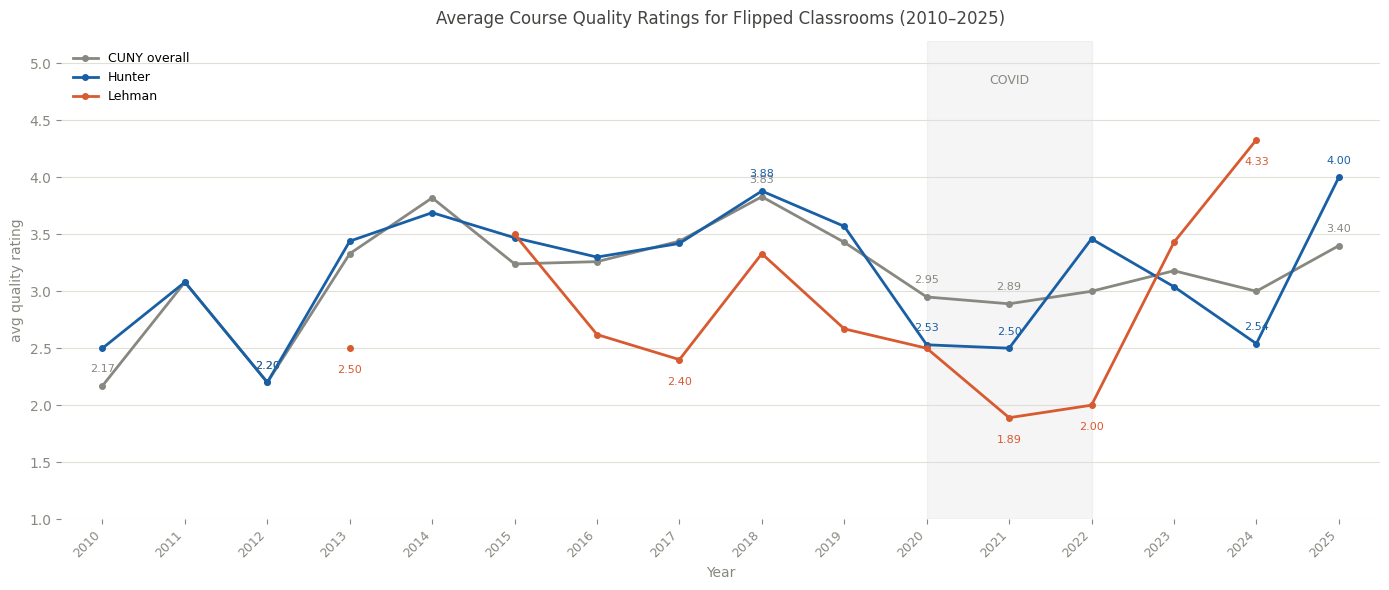

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

years = [2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025]
overall = [2.17,3.08,2.20,3.33,3.82,3.24,3.26,3.44,3.83,3.43,2.95,2.89,3.00,3.18,3.00,3.40]
hunter  = [2.50,3.08,2.20,3.44,3.69,3.47,3.30,3.42,3.88,3.57,2.53,2.50,3.46,3.04,2.54,4.00]
lehman  = [None,None,None,2.50,None,3.50,2.62,2.40,3.33,2.67,2.50,1.89,2.00,3.43,4.33,None]

lehman = [np.nan if v is None else v for v in lehman]

# Only label these years per line
overall_label_yrs = {2010, 2012, 2018, 2020, 2021, 2025}
hunter_label_yrs  = {2012, 2018, 2020, 2021, 2024, 2025}
lehman_label_yrs  = {2013, 2017, 2021, 2022, 2024}

fig, ax = plt.subplots(figsize=(14, 6))

ax.axvspan(2020, 2022, color='#888780', alpha=0.08, zorder=0)
ax.text(2021, 4.82, 'COVID', ha='center', fontsize=9, color='#888780')

ax.plot(years, overall, color='#888780', linewidth=2, marker='o', markersize=4, label='CUNY overall', zorder=3)
ax.plot(years, hunter,  color='#185FA5', linewidth=2, marker='o', markersize=4, label='Hunter', zorder=3)
ax.plot(years, lehman,  color='#D85A30', linewidth=2, marker='o', markersize=4, label='Lehman', zorder=3)

for i, yr in enumerate(years):
    if yr in overall_label_yrs:
        ax.text(yr, overall[i] + 0.12, f'{overall[i]:.2f}', ha='center', fontsize=8, color='#888780')
    if yr in hunter_label_yrs:
        ax.text(yr, hunter[i] + 0.12, f'{hunter[i]:.2f}', ha='center', fontsize=8, color='#185FA5')
    if yr in lehman_label_yrs and not np.isnan(lehman[i]):
        ax.text(yr, lehman[i] - 0.22, f'{lehman[i]:.2f}', ha='center', fontsize=8, color='#D85A30')

ax.set_ylim(1, 5.2)
ax.set_xlim(2009.5, 2025.5)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right', fontsize=9, color='#888780')
ax.set_ylabel('avg quality rating', color='#888780', fontsize=10)
ax.tick_params(colors='#888780')
ax.grid(axis='y', color='#e0dfd8', zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.legend(frameon=False, fontsize=9, loc='upper left')
ax.set_title('Average Course Quality Ratings for Flipped Classrooms (2010–2025)', fontsize=12, color='#444441', pad=12)
ax.set_xlabel('Year', color='#888780', fontsize=10)

plt.tight_layout()
plt.savefig('flip_classroom_quality_time.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
sample = flip_reviews[
    flip_reviews['College'].str.contains('Baruch', na=False)
].sample(10, random_state=42)

for _, row in sample.iterrows():
    print(f"\nCourse: {row['Course']}")
    print(f"Review: {str(row['Comment'])[:300]}")
    print('-'*40)


Course: PHI1600
Review: avoid at all costs consistently gets confused while teaching absent for a month  expects class to still understand the complex topic taught for the final treats the course like a flipped classroom wants you to learn the material yourself  gives the lecture after i dont write reviews but had to for h
----------------------------------------

Course: ACC4100
Review: extremely knowledgeable professor his lectures are based on pp and supported by his real life examples 2midterms and final connect for practice and iclicker for extra credit very responsive via email and available after class his feedback and suggestions are valuable and if you are willing to put in
----------------------------------------

Course: ECO1001
Review: flipped class so youre basically teaching yourself one of the hardest classes at baruch 2 midterms 1 final one quiz due every saturday night and one every sunday not a bad guy midterms curved zooms didnt really help tbh just did examples hav

# Grade Distribution

In [ ]:
print(all_reviews_df['Grade'].value_counts().head(30))

Grade
No Grade           419612
A                  100485
Not sure yet        43301
A+                  35331
A-                  31236
B+                  23986
B                   18968
Rather not say       8924
B-                   8164
Drop/Withdrawal      7036
C                    5939
C+                   5708
F                    3727
C-                   2430
Not_Sure_Yet         2301
D                    2085
Incomplete           2019
Audit/No Grade       1267
D+                   1098
D-                    741
Rather_Not_Say        628
Pass                  389
Fail                   82
Audit/No_Grade         42
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Clean up grade column - keep only real grades
valid_grades = ['A+', 'A', 'A-', 'B+', 'B', 'B-', 'C+', 'C', 'C-', 'D+', 'D', 'D-', 'F']

# Grade to GPA point mapping
grade_map = {
    'A+': 4.0, 'A': 4.0, 'A-': 3.7,
    'B+': 3.3, 'B': 3.0, 'B-': 2.7,
    'C+': 2.3, 'C': 2.0, 'C-': 1.7,
    'D+': 1.3, 'D': 1.0, 'D-': 0.7,
    'F': 0.0
}

baruch = all_reviews_df[
    all_reviews_df['College'].str.contains('Baruch', na=False) &
    all_reviews_df['Grade'].isin(valid_grades)
].copy()

baruch['grade_points'] = baruch['Grade'].map(grade_map)

# Split into high quality professors (>=4.0) vs low quality (<=2.0)
high_q = baruch[baruch['Quality'] >= 4.0]
low_q  = baruch[baruch['Quality'] <= 2.0]

print(f"High quality professors (>=4.0): {len(high_q)} reviews")
print(f"Low quality professors (<=2.0): {len(low_q)} reviews")

print(f"\nHigh quality avg grade points: {high_q['grade_points'].mean():.2f}")
print(f"Low quality avg grade points:  {low_q['grade_points'].mean():.2f}")

print("\n=== GRADE DISTRIBUTION - HIGH QUALITY ===")
print((high_q['Grade'].value_counts(normalize=True)*100).round(1).reindex(valid_grades).dropna())

print("\n=== GRADE DISTRIBUTION - LOW QUALITY ===")
print((low_q['Grade'].value_counts(normalize=True)*100).round(1).reindex(valid_grades).dropna())

# Now break it down by course for pathway courses
pathway = ['ECO1001', 'STA2000', 'ENG2850', 'MSC1003', 'PHI1600']
print("\n=== PATHWAY COURSES - QUALITY VS GRADE ===")
for course in pathway:
    subset = baruch[baruch['Course'] == course]
    if len(subset) < 20:
        continue
    corr = subset[['Quality','grade_points']].corr().iloc[0,1]
    avg_grade = subset.groupby(
        subset['Quality'].apply(lambda x: 'high' if x>=4 else ('low' if x<=2 else 'mid'))
    )['grade_points'].mean().round(2)
    print(f"\n{course} ({len(subset)} reviews) | correlation: {corr:.2f}")
    print(avg_grade)

High quality professors (>=4.0): 20536 reviews
Low quality professors (<=2.0): 5240 reviews

High quality avg grade points: 3.78
Low quality avg grade points:  2.85

=== GRADE DISTRIBUTION - HIGH QUALITY ===
Grade
A+     9.1
A     59.5
A-    14.9
B+     7.9
B      4.9
B-     1.6
C+     0.8
C      0.6
C-     0.3
D+     0.0
D      0.1
D-     0.0
F      0.2
Name: proportion, dtype: float64

=== GRADE DISTRIBUTION - LOW QUALITY ===
Grade
A+     2.8
A     17.8
A-    11.6
B+    14.1
B     14.7
B-     9.2
C+     7.3
C      6.9
C-     4.0
D+     1.9
D      2.3
D-     2.9
F      4.6
Name: proportion, dtype: float64

=== PATHWAY COURSES - QUALITY VS GRADE ===

ECO1001 (373 reviews) | correlation: 0.37
Quality
high    3.69
low     3.09
mid     3.41
Name: grade_points, dtype: float64

STA2000 (410 reviews) | correlation: 0.53
Quality
high    3.71
low     2.78
mid     3.56
Name: grade_points, dtype: float64

ENG2850 (473 reviews) | correlation: 0.50
Quality
high    3.83
low     2.77
mid     3.48
Na

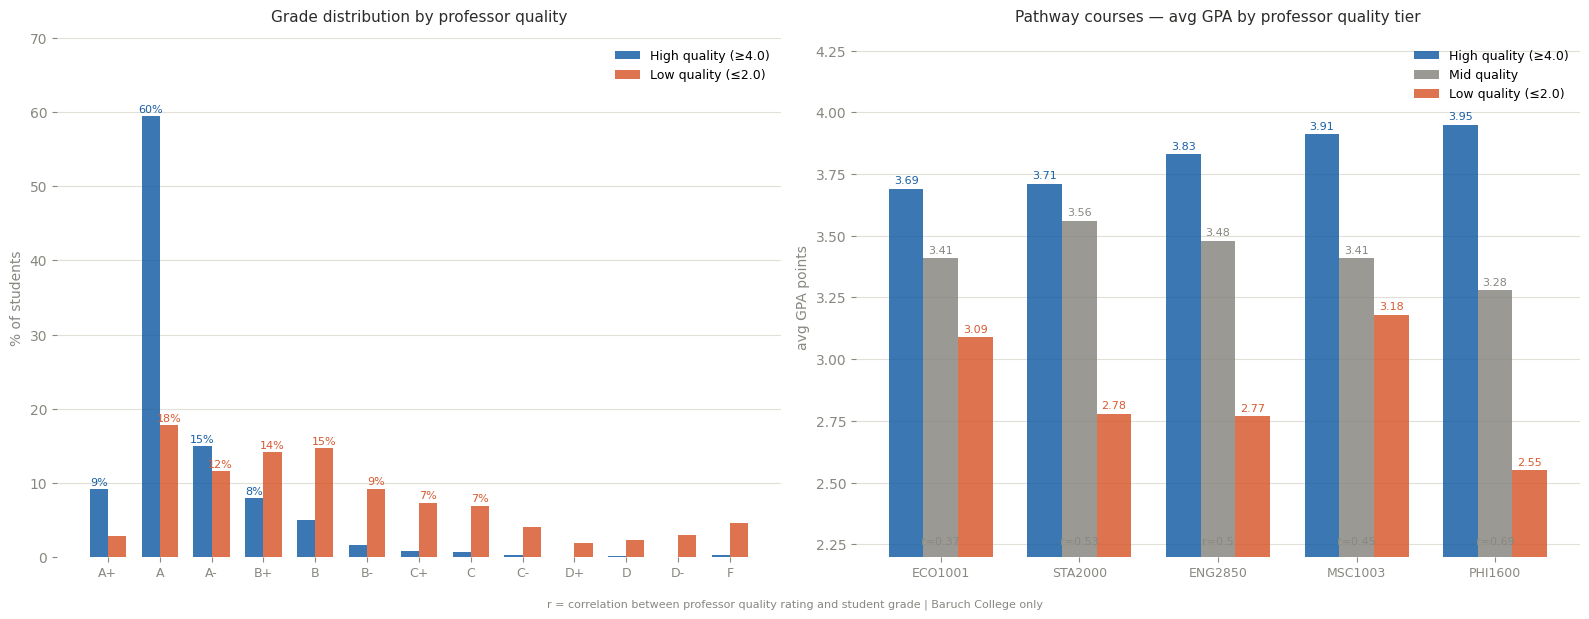

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# === LEFT: Grade distribution ===
valid_grades = ['A+', 'A', 'A-', 'B+', 'B', 'B-', 'C+', 'C', 'C-', 'D+', 'D', 'D-', 'F']

high_pct = [9.1,59.5,14.9,7.9,4.9,1.6,0.8,0.6,0.3,0.0,0.1,0.0,0.2]
low_pct  = [2.8,17.8,11.6,14.1,14.7,9.2,7.3,6.9,4.0,1.9,2.3,2.9,4.6]

x = np.arange(len(valid_grades))
width = 0.35

bars1 = ax1.bar(x - width/2, high_pct, width, color='#185FA5', alpha=0.85, label='High quality (≥4.0)', edgecolor='none')
bars2 = ax1.bar(x + width/2, low_pct,  width, color='#D85A30', alpha=0.85, label='Low quality (≤2.0)',  edgecolor='none')

# Label only the tallest bars to avoid clutter
for bar, pct in zip(bars1, high_pct):
    if pct >= 5:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{pct:.0f}%', ha='center', fontsize=8, color='#185FA5')

for bar, pct in zip(bars2, low_pct):
    if pct >= 5:
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{pct:.0f}%', ha='center', fontsize=8, color='#D85A30')

ax1.set_xticks(x)
ax1.set_xticklabels(valid_grades, fontsize=9, color='#888780')
ax1.set_ylabel('% of students', color='#888780', fontsize=10)
ax1.set_ylim(0, 70)
ax1.tick_params(colors='#888780')
ax1.grid(axis='y', color='#e0dfd8', zorder=0)
ax1.set_axisbelow(True)
for spine in ax1.spines.values():
    spine.set_visible(False)
ax1.legend(frameon=False, fontsize=9)
ax1.set_title('Grade distribution by professor quality', fontsize=11, fontweight='normal', color='#2c2c2a', pad=12)

# === RIGHT: Pathway courses avg GPA by tier ===
courses = ['ECO1001', 'STA2000', 'ENG2850', 'MSC1003', 'PHI1600']
high_gpa = [3.69, 3.71, 3.83, 3.91, 3.95]
mid_gpa  = [3.41, 3.56, 3.48, 3.41, 3.28]
low_gpa  = [3.09, 2.78, 2.77, 3.18, 2.55]
corrs    = [0.37, 0.53, 0.50, 0.45, 0.69]

x2 = np.arange(len(courses))
width2 = 0.25

bars_h = ax2.bar(x2 - width2, high_gpa, width2, color='#185FA5', alpha=0.85, label='High quality (≥4.0)', edgecolor='none')
bars_m = ax2.bar(x2,          mid_gpa,  width2, color='#888780', alpha=0.85, label='Mid quality',          edgecolor='none')
bars_l = ax2.bar(x2 + width2, low_gpa,  width2, color='#D85A30', alpha=0.85, label='Low quality (≤2.0)',  edgecolor='none')

for bar, val in zip(bars_h, high_gpa):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=8, color='#185FA5')

for bar, val in zip(bars_m, mid_gpa):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=8, color='#888780')

for bar, val in zip(bars_l, low_gpa):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=8, color='#D85A30')

# Correlation annotations below each course
for i, (course, corr) in enumerate(zip(courses, corrs)):
    ax2.text(i, 2.25, f'r={corr}', ha='center', fontsize=8, color='#888780')

ax2.set_xticks(x2)
ax2.set_xticklabels(courses, fontsize=9, color='#888780')
ax2.set_ylabel('avg GPA points', color='#888780', fontsize=10)
ax2.set_ylim(2.2, 4.3)
ax2.tick_params(colors='#888780')
ax2.grid(axis='y', color='#e0dfd8', zorder=0)
ax2.set_axisbelow(True)
for spine in ax2.spines.values():
    spine.set_visible(False)
ax2.legend(frameon=False, fontsize=9)
ax2.set_title('Pathway courses — avg GPA by professor quality tier', fontsize=11, fontweight='normal', color='#2c2c2a', pad=12)

# Footnote
fig.text(0.5, -0.02, 'r = correlation between professor quality rating and student grade | Baruch College only',
         ha='center', fontsize=8, color='#888780')

plt.tight_layout()
plt.savefig('grade_vs_quality.png', dpi=150, bbox_inches='tight')
plt.show()

# Department Sentiment - Baruch

In [ ]:
# Department Level Sentiment
import pandas as pd

# Extract department prefix from course code (first 3 letters)
all_reviews_df['Department'] = all_reviews_df['Course'].str.extract(r'^([A-Za-z]+)')
all_reviews_df['Department'] = all_reviews_df['Department'].str.upper()

# Filter to Baruch only
baruch = all_reviews_df[all_reviews_df['College'].str.contains('Baruch', na=False)].copy()

# Department composite scores
dept_scores = baruch.groupby('Department').agg(
    total_reviews=('Quality', 'count'),
    avg_quality=('Quality', 'mean'),
    avg_difficulty=('Difficulty', 'mean')
).round(2).sort_values('total_reviews', ascending=False)

# Filter to departments with enough reviews to be meaningful
print(dept_scores[dept_scores['total_reviews'] >= 30])

            total_reviews  avg_quality  avg_difficulty
Department                                            
ENG                  8652         3.82            2.81
ACC                  6929         3.51            3.45
FIN                  5863         3.33            3.38
MTH                  5015         3.59            3.23
CIS                  4968         3.45            2.97
...                   ...          ...             ...
SAT                    33         3.15            3.18
EN                     32         3.73            3.19
CALCULUS               32         3.25            3.50
SPAN                   31         4.24            2.06
PHYS                   31         3.66            2.61

[93 rows x 3 columns]


In [ ]:
target_depts = ['ENG', 'ACC', 'FIN', 'MTH', 'CIS', 'ECO', 'STA', 'PHI', 'MSC', 'LAW', 'MKT', 'MGT', 'COM', 'PSY', 'BIO']

dept_filtered = dept_scores[dept_scores.index.isin(target_depts)].sort_values('avg_quality', ascending=False)
print(dept_filtered)

            total_reviews  avg_quality  avg_difficulty
Department                                            
LAW                  3008         4.29            2.70
MSC                  1146         4.17            2.46
PSY                  3311         4.03            2.59
COM                  4696         3.98            2.51
PHI                  2280         3.87            2.65
ENG                  8652         3.82            2.81
BIO                   976         3.81            3.14
MKT                  3456         3.72            2.71
MGT                  4684         3.63            2.84
MTH                  5015         3.59            3.23
ACC                  6929         3.51            3.45
CIS                  4968         3.45            2.97
FIN                  5863         3.33            3.38
STA                  2007         3.31            3.17
ECO                  4942         3.24            3.32


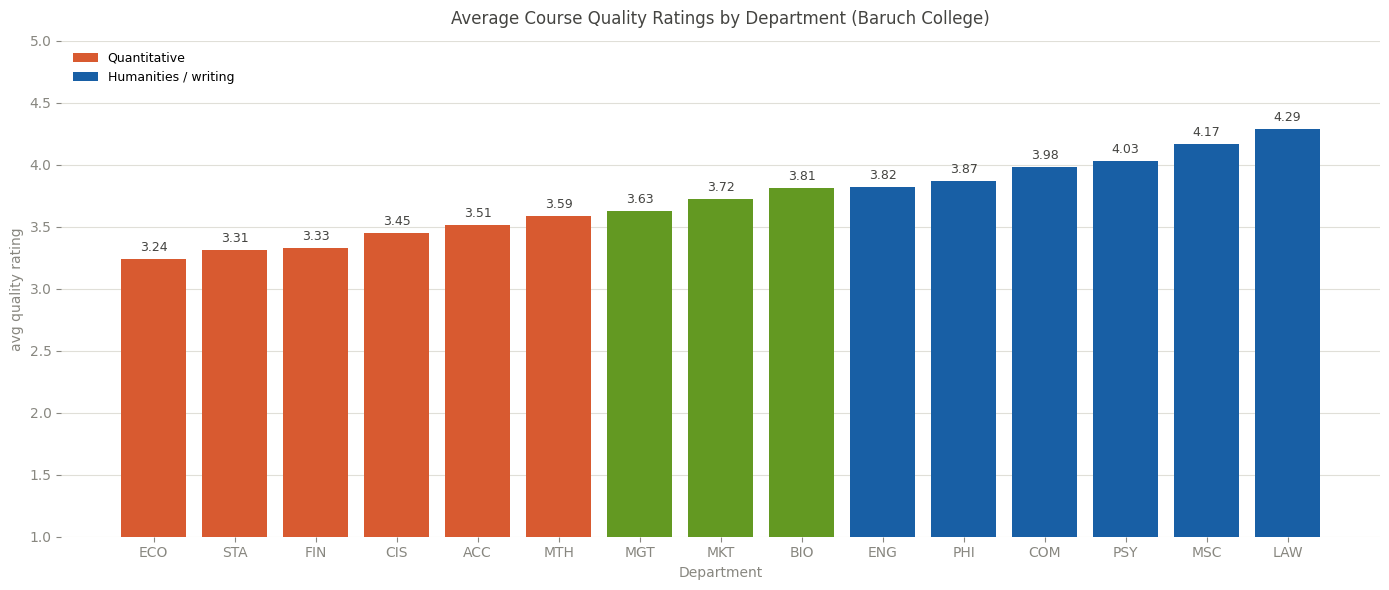

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

depts = ['ECO','STA','FIN','CIS','ACC','MTH','MGT','MKT','BIO','ENG','PHI','COM','PSY','MSC','LAW']
quality = [3.24,3.31,3.33,3.45,3.51,3.59,3.63,3.72,3.81,3.82,3.87,3.98,4.03,4.17,4.29]
reviews = [4942,2007,5863,4968,6929,5015,4684,3456,976,8652,2280,4696,3311,1146,3008]

colors = []
for d in depts:
    if d in ['ECO','STA','FIN','CIS','ACC','MTH']:
        colors.append('#D85A30')
    elif d in ['ENG','PHI','COM','PSY','MSC','LAW']:
        colors.append('#185FA5')
    else:
        colors.append('#639922')

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(depts, quality, color=colors, edgecolor='none', zorder=3)

# Numbers on top of bars
for bar, q in zip(bars, quality):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.04,
            f'{q:.2f}', ha='center', va='bottom', fontsize=9, color='#444441')

ax.set_ylim(1, 5)
ax.set_ylabel('avg quality rating', color='#888780', fontsize=10)
ax.set_xlabel('Department', color='#888780', fontsize=10)
ax.tick_params(colors='#888780')
ax.grid(axis='y', color='#e0dfd8', zorder=0)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title('Average Course Quality Ratings by Department (Baruch College)', fontsize=12, color='#444441', pad=12)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#D85A30', label='Quantitative'),
    Patch(facecolor='#185FA5', label='Humanities / writing'),
]
ax.legend(handles=legend_elements, loc='upper left', frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('baruch_dept_scores.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(all_reviews_df.columns.tolist())

['Professor ID', 'Professor Name', 'Department', 'Course', 'Quality', 'Difficulty', 'Grade', 'Thumbs Up', 'Thumbs Down', 'Comment', 'Date', 'College', 'Date_parsed', 'has_rec_letter', 'has_tech', 'tech_count', 'ai_count', 'cyber_count', 'has_ai', 'has_cyber', 'has_tech_general', 'integrity_count', 'has_integrity', 'has_healthcare']


In [ ]:
eng_dept = all_reviews_df[
    (all_reviews_df['College'].str.contains('Baruch', na=False)) &
    (all_reviews_df['Course'].str.startswith('ENG'))
].agg(
    total_reviews=('Quality', 'count'),
    avg_quality=('Quality', 'mean'),
    avg_difficulty=('Difficulty', 'mean')
).round(2)
print(eng_dept)

                Quality  Difficulty
total_reviews   8920.00         NaN
avg_quality        3.82         NaN
avg_difficulty      NaN        2.81


In [ ]:
# Organic Chemistry mentions across CUNY
# Organic chemistry across CUNY
orgo_keywords = ['organic chemistry', 'orgo', 'organic chem']

orgo_reviews = all_reviews_df[
    all_reviews_df['Comment'].str.lower().str.contains(
        '|'.join(orgo_keywords), na=False
    )
]

print("=== ORGANIC CHEMISTRY MENTIONS ACROSS CUNY ===")
print(orgo_reviews.groupby('College').agg(
    count=('Comment', 'count')
).sort_values('count', ascending=False).head(15))

print("\n=== TOP COURSES MENTIONING ORGANIC CHEMISTRY ===")
print(orgo_reviews.groupby(['College', 'Course']).agg(
    count=('Comment', 'count'),
    avg_quality=('Quality', 'mean'),
    avg_difficulty=('Difficulty', 'mean')
).round(2).sort_values('count', ascending=False).head(20))

print("\n=== SAMPLE REVIEWS ===")
# focus on City College since he specifically mentioned it
city_orgo = orgo_reviews[
    orgo_reviews['College'].str.contains('City College', na=False)
]
for _, row in city_orgo.head(10).iterrows():
    print(f"\nCourse: {row['Course']}")
    print(f"Quality: {row['Quality']} | Difficulty: {row['Difficulty']}")
    print(f">> {str(row['Comment'])[:350]}")
    print('-'*40)

=== ORGANIC CHEMISTRY MENTIONS ACROSS CUNY ===
                                                 count
College                                               
Hunter College                                     511
CUNY Queens College                                310
Brooklyn College                                   287
City College of New York                           270
Baruch College                                     142
Borough of Manhattan Community College             120
Lehman College                                     117
College of Staten Island (CUNY - Staten Island)    108
John Jay College of Criminal Justice                97
CUNY York College                                   84
New York City College of Technology                 82
LaGuardia Community College                         68
Queensborough Community College                     64
Kingsborough Community College                      60
Medgar Evers College                                35

=== TOP COURSES M

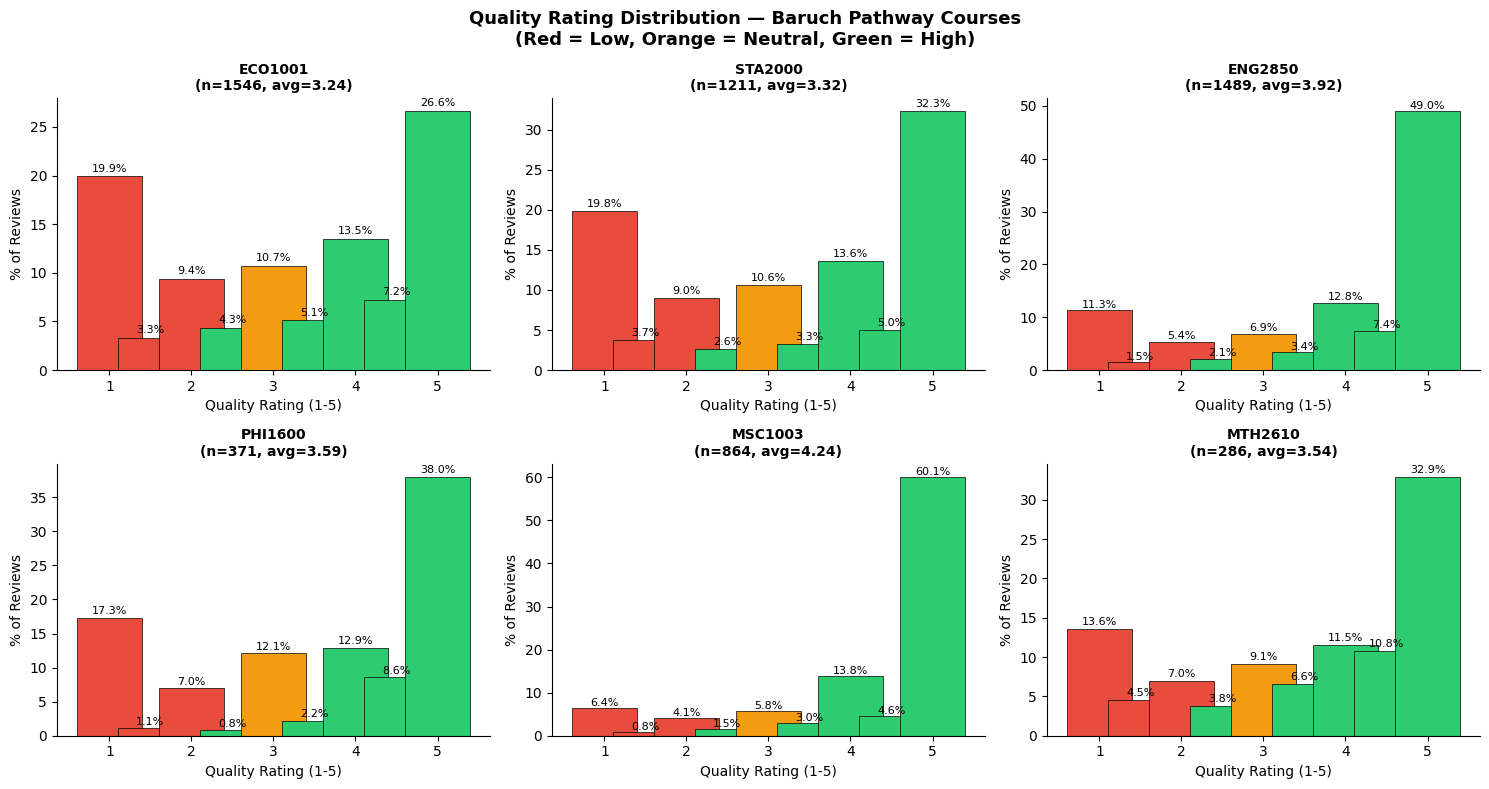

In [ ]:
import matplotlib.pyplot as plt

pathway_courses = ['ECO1001', 'STA2000', 'ENG2850', 'PHI1600', 'MSC1003', 'MTH2610']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, course in enumerate(pathway_courses):
    course_reviews = all_reviews_df[
        (all_reviews_df['College'].str.contains('Baruch', na=False)) &
        (all_reviews_df['Course'] == course)
    ]

    counts = course_reviews['Quality'].value_counts().sort_index()
    total = len(course_reviews)
    pct = (counts / total * 100).round(1)

    axes[idx].bar(pct.index, pct.values,
                  color=['#e74c3c' if x <= 2 else '#f39c12' if x == 3 else '#2ecc71'
                         for x in pct.index],
                  edgecolor='black', linewidth=0.5)

    axes[idx].set_title(f'{course}\n(n={total}, avg={course_reviews["Quality"].mean():.2f})',
                        fontweight='bold', fontsize=10)
    axes[idx].set_xlabel('Quality Rating (1-5)')
    axes[idx].set_ylabel('% of Reviews')
    axes[idx].set_xticks([1, 2, 3, 4, 5])
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

    for i, (rating, val) in enumerate(pct.items()):
        axes[idx].text(rating, val + 0.5, f'{val}%',
                      ha='center', fontsize=8)

plt.suptitle('Quality Rating Distribution — Baruch Pathway Courses\n(Red = Low, Orange = Neutral, Green = High)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pathway_quality_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
eco_yearly = all_reviews_df[
    (all_reviews_df['College'].str.contains('Baruch', na=False)) &
    (all_reviews_df['Course'] == 'ECO1001')
].groupby('year').agg(
    reviews=('Comment', 'count'),
    avg_quality=('Quality', 'mean'),
    integrity=('has_integrity', 'sum')
).round(2).reset_index()

print(eco_yearly)

KeyError: 'year'

In [ ]:
worth_keywords = [
    'worth it', 'waste of time', 'waste of money', 'pointless',
    'learned nothing', 'learned a lot', 'valuable', 'useless',
    'would take again', 'regret', 'glad i took', 'not worth'
]

pathway_courses = ['ENG2850', 'PHI1600', 'MSC1003', 'ECO1001', 'STA2000']

for course in pathway_courses:
    reviews = all_reviews_df[
        (all_reviews_df['College'].str.contains('Baruch', na=False)) &
        (all_reviews_df['Course'] == course) &
        (all_reviews_df['Comment'].str.lower().str.contains(
            '|'.join(worth_keywords), na=False
        ))
    ][['Quality', 'Comment']]

    print(f"\n{'='*50}")
    print(f"{course} — WORTH IT MENTIONS ({len(reviews)} reviews)")
    print(f"{'='*50}")
    for _, row in reviews.head(5).iterrows():
        print(f"\nQuality: {row['Quality']}")
        print(f">> {str(row['Comment'])[:300]}")
        print('-'*40)


ENG2850 — WORTH IT MENTIONS (81 reviews)

Quality: 1.0
>> if you want to actually learn about literature take professor frank if like me youre taking this class exclusively to satisfy a core requirement avoid at all costs the class is interesting but hes a very harsh grader and considering that the majority of the grade is given by his arbitrary designatio
----------------------------------------

Quality: 4.0
>> he is awesome you will definitely learn something from this class getting an a is not easy with him and the he gives you the grade you really deserve to get you have to earn your grade by hard work but it is one of those classes you will remember when you will think about your good memories of schoo
----------------------------------------

Quality: 5.0
>> simply one of the best eng profsvery challenging but you wont regret taking the coursealso hes very helpful in many ways
----------------------------------------

Quality: 5.0
>> she always kept the class entertaining and g

In [ ]:
eng_reviews = all_reviews_df[
    (all_reviews_df['College'].str.contains('Baruch', na=False)) &
    (all_reviews_df['Course'].str.upper().str.strip() == 'ENG2850')
][['Course', 'Comment', 'Quality', 'Difficulty', 'Professor Name']]

print("=== ENG2850 QUALITY DISTRIBUTION ===")
print(eng_reviews['Quality'].value_counts().sort_index())

print("\n=== TOP PROFESSORS BY REVIEW COUNT ===")
print(eng_reviews['Professor Name'].value_counts().head(10))

print("\n=== LOWEST RATED PROFESSOR REVIEWS ===")
low_rated = eng_reviews[eng_reviews['Quality'] <= 2].head(10)
for _, row in low_rated.iterrows():
    print(f"\nProfessor: {row['Professor Name']}")
    print(f"Quality: {row['Quality']} | Difficulty: {row['Difficulty']}")
    print(f"Review: {str(row['Comment'])[:300]}")
    print('-'*50)

=== ENG2850 QUALITY DISTRIBUTION ===
Quality
1.0    179
1.5     23
2.0     82
2.5     32
3.0    104
3.5     51
4.0    191
4.5    110
5.0    733
Name: count, dtype: int64

=== TOP PROFESSORS BY REVIEW COUNT ===
Professor Name
Kelly Nims              87
Christopher Trogan      67
Victor Zarour Zarzar    62
Chris Trogan            50
Carmel Jordan           47
Kevin Frank             43
Dana Milstein           42
Harold Brent            35
Dina Odnopozova         32
Tuzyline Allan          27
Name: count, dtype: int64

=== LOWEST RATED PROFESSOR REVIEWS ===

Professor: Kevin Frank
Quality: 1.0 | Difficulty: 5.0
Review: he blamed the class when everyone did badly on the midterm students who came on time were taken to the english dep so he could teach those who were 3 min late were clueless about where class was which is very unprofessional he is a tough grader and expects a little too much
--------------------------------------------------

Professor: Kevin Frank
Quality: 1.0 | Difficulty:

In [ ]:
for course in ['ECO1001', 'STA2000']:
    print(f"\n{'='*50}")
    print(f"{course} — SAMPLE REVIEWS")
    print(f"{'='*50}")

    reviews = all_reviews_df[
        (all_reviews_df['College'].str.contains('Baruch', na=False)) &
        (all_reviews_df['Course'].str.upper().str.strip() == course)
    ]['Comment'].sample(10, random_state=42)

    for r in reviews:
        print(f"\n>> {str(r)[:350]}")
        print('-'*40)


ECO1001 — SAMPLE REVIEWS

>> self study course lets get that straight you must learn on your own and work hard for it hes a very nice man and will answer any question you have but will not even remotely prepare you for exams study hard on your own do practice exams and hope the class doesnt cheat so your curve is high
----------------------------------------

>> i dont know about others but i didnt even read the book on mindtap read powerpoints watch all those videos write down only what you didnt understand ask professor on the day after and take note during lectures also analayse and count kind of questions find your own shortcuts for it i am a lazy student who love the a grade1hourweek
----------------------------------------

>> all in all he is not that bad just read the book and use online resources two tests  final non cumulative drops 1 test score as for attendance once its taken you can leave kleinbergs tests are easier then joyces but joyce is not as boring as kleinbergyou c

In [ ]:
from collections import Counter
import re

def top_keywords(course_name, top_n=20):
    reviews = all_reviews_df[
        (all_reviews_df['College'].str.contains('Baruch', na=False)) &
        (all_reviews_df['Course'].str.upper().str.strip() == course_name.upper())
    ]['Comment'].dropna()

    stopwords = {'the','a','an','and','or','but','in','on','at','to','for',
                 'of','with','his','her','he','she','you','it','is','are',
                 'was','were','this','that','have','has','had','not','do',
                 'if','be','as','by','so','we','my','your','i','its','they',
                 'them','their','from','will','can','just','get','also','very',
                 'would','could','should','did','been','more','about','out',
                 'up','what','which','who','there','all','one','when','than'}

    words = []
    for review in reviews:
        tokens = re.findall(r'\b[a-z]{3,}\b', str(review).lower())
        words.extend([w for w in tokens if w not in stopwords])

    print(f"\n=== TOP KEYWORDS: {course_name} ({len(reviews)} reviews) ===")
    for word, count in Counter(words).most_common(top_n):
        print(f"{word}: {count}")

top_keywords('ECO1001')
top_keywords('STA2000')


=== TOP KEYWORDS: ECO1001 (1551 reviews) ===
class: 1178
professor: 550
take: 408
final: 403
exams: 395
him: 385
hard: 368
good: 329
read: 329
tests: 285
dont: 281
easy: 269
really: 268
study: 258
grade: 246
hes: 240
questions: 229
well: 219
lectures: 219
book: 214

=== TOP KEYWORDS: STA2000 (1211 reviews) ===
class: 856
professor: 485
take: 368
easy: 344
final: 344
exams: 325
good: 283
him: 265
homework: 248
dont: 229
tests: 204
hard: 204
understand: 198
really: 198
lectures: 197
grade: 192
notes: 182
gives: 180
questions: 177
well: 169


In [ ]:
baruch_yearly = all_reviews_df[
    all_reviews_df['College'].str.contains('Baruch', na=False)
].groupby(all_reviews_df['Date_parsed'].dt.year).agg(
    total_reviews=('Comment', 'count'),
    ai_mentions=('has_ai', 'sum'),
    integrity_mentions=('has_integrity', 'sum')
).reset_index()

baruch_yearly['ai_per_1000'] = (baruch_yearly['ai_mentions'] / baruch_yearly['total_reviews'] * 1000).round(2)
baruch_yearly['integrity_per_1000'] = (baruch_yearly['integrity_mentions'] / baruch_yearly['total_reviews'] * 1000).round(2)
print(baruch_yearly.to_string())

    Date_parsed  total_reviews  ai_mentions  integrity_mentions  ai_per_1000  integrity_per_1000
0          2001              5            0                   0         0.00                0.00
1          2002             47            0                   0         0.00                0.00
2          2003           1273            0                   1         0.00                0.79
3          2004           5635            0                   4         0.00                0.71
4          2005           5784            0                   3         0.00                0.52
5          2006           4701            0                   8         0.00                1.70
6          2007           3824            1                   1         0.26                0.26
7          2008           4275            0                   9         0.00                2.11
8          2009           4601            0                   6         0.00                1.30
9          2010           4671

In [ ]:
# Fix capitalization first
all_reviews_df['Course'] = all_reviews_df['Course'].str.upper().str.strip()

# Define courses to keep
gateway_courses = ['ENG2150', 'MSC1003', 'ENG2850', 'PHI1600',
                   'MTH2610', 'ECO1001', 'STA2000']

# Re-aggregate after fixing capitalization
aggregated_gateway_data = all_reviews_df[
    (all_reviews_df['College'].str.contains('Baruch', na=False)) &
    (all_reviews_df['Course'].isin(gateway_courses))
].groupby('Course').agg(
    Quality=('Quality', 'mean'),
    Difficulty=('Difficulty', 'mean'),
    Count=('Comment', 'count')
).round(2).reset_index()

aggregated_gateway_data_sorted = aggregated_gateway_data.sort_values(
    by='Quality', ascending=True  # low to high so worst experience is on left
)

print(aggregated_gateway_data_sorted)

    Course  Quality  Difficulty  Count
0  ECO1001     3.23        3.32   1551
6  STA2000     3.32        3.03   1211
4  MTH2610     3.54        3.07    286
5  PHI1600     3.59        3.02    371
1  ENG2150     3.84        2.70   2319
2  ENG2850     3.90        2.97   1505
3  MSC1003     4.24        2.36    864


# Adjunct vs Tenured

In [ ]:
# Check what professor-level columns you have
print(all_reviews_df[['Professor ID', 'Professor Name', 'Department', 'College']].head(5))

# Check if there's any adjunct signal in the data
print("\n=== COLUMN CHECK ===")
print(all_reviews_df.columns.tolist())

# See if adjunct appears in review text
adjunct_mentions = all_reviews_df[
    all_reviews_df['Comment'].str.lower().str.contains(
        'adjunct|part.time|part time', na=False, regex=True
    )
]
print(f"\nReviews mentioning adjunct/part-time: {len(adjunct_mentions)}")
print(adjunct_mentions[['College', 'Course', 'Comment']].head(5))

   Professor ID Professor Name Department                          College
0       1006383     Jim Kenney         EN  Queensborough Community College
1       1006383     Jim Kenney        ENG  Queensborough Community College
2       1006383     Jim Kenney        ENG  Queensborough Community College
3       1006383     Jim Kenney        ENG  Queensborough Community College
4       1006383     Jim Kenney        ENG  Queensborough Community College

=== COLUMN CHECK ===
['Professor ID', 'Professor Name', 'Department', 'Course', 'Quality', 'Difficulty', 'Grade', 'Thumbs Up', 'Thumbs Down', 'Comment', 'Date', 'College', 'Date_parsed', 'has_rec_letter', 'has_tech', 'tech_count', 'ai_count', 'cyber_count', 'has_ai', 'has_cyber', 'has_tech_general', 'integrity_count', 'has_integrity', 'has_healthcare']

Reviews mentioning adjunct/part-time: 490
                               College   Course  \
3864   Queensborough Community College    MA440   
7261   Queensborough Community College   ENG101  

In [ ]:
# AI mentions by year at Baruch
print("=== CHATGPT/AI MENTIONS BY YEAR — BARUCH ===")
baruch_yearly = all_reviews_df[
    all_reviews_df['College'].str.contains('Baruch', na=False)
].groupby(all_reviews_df['Date_parsed'].dt.year).agg(
    total_reviews=('Comment', 'count'),
    ai_mentions=('has_ai', 'sum'),
    integrity_mentions=('has_integrity', 'sum')
).reset_index()

baruch_yearly['ai_per_1000'] = (baruch_yearly['ai_mentions'] / baruch_yearly['total_reviews'] * 1000).round(2)
baruch_yearly['integrity_per_1000'] = (baruch_yearly['integrity_mentions'] / baruch_yearly['total_reviews'] * 1000).round(2)

print(baruch_yearly.to_string())

=== CHATGPT/AI MENTIONS BY YEAR — BARUCH ===
    Date_parsed  total_reviews  ai_mentions  integrity_mentions  ai_per_1000  integrity_per_1000
0          2001              5            0                   0         0.00                0.00
1          2002             47            0                   0         0.00                0.00
2          2003           1273            0                   1         0.00                0.79
3          2004           5635            0                   4         0.00                0.71
4          2005           5784            0                   3         0.00                0.52
5          2006           4701            0                   8         0.00                1.70
6          2007           3824            1                   1         0.26                0.26
7          2008           4275            0                   9         0.00                2.11
8          2009           4601            0                   6         0.00      

In [ ]:
# ── BEFORE ──────────────────────────────────────────────────────────────────

# run original broad filter first and save the count
program_identification_keywords = [
    'abroad', 'international', 'overseas', 'travel', 'trip', 'exchange',
    'costa rica', 'seoul', 'birmingham', 'morocco', 'faculty-led', 'summer program'
]

all_reviews_df['is_study_abroad_broad'] = False
for keyword in program_identification_keywords:
    comment_matches = all_reviews_df['Comment'].fillna('').str.contains(keyword, case=False, na=False)
    course_matches = all_reviews_df['Course'].astype(str).str.lower().str.contains(keyword, case=False, na=False)
    all_reviews_df['is_study_abroad_broad'] = all_reviews_df['is_study_abroad_broad'] | comment_matches | course_matches

before_count = all_reviews_df['is_study_abroad_broad'].sum()
print(f"Before tightening — study abroad reviews identified: {before_count}")

# per school breakdown before
print("\nPer school (before):")
print(all_reviews_df[all_reviews_df['is_study_abroad_broad']]['College'].value_counts())


# ── AFTER ───────────────────────────────────────────────────────────────────

destination_keywords = [
    'costa rica', 'seoul', 'birmingham', 'morocco', 'florence',
    'madrid', 'abroad', 'overseas'
]
program_signal_keywords = [
    'faculty-led', 'study abroad', 'summer program', 'exchange program',
    'international program', 'field course', 'off-campus'
]

def is_study_abroad_strict(text, course):
    combined = str(text).lower() + ' ' + str(course).lower()
    has_destination = any(kw in combined for kw in destination_keywords)
    has_program_signal = any(kw in combined for kw in program_signal_keywords)
    return has_destination and has_program_signal

all_reviews_df['is_study_abroad_strict'] = all_reviews_df.apply(
    lambda row: is_study_abroad_strict(row['Comment'], row['Course']), axis=1
)

after_count = all_reviews_df['is_study_abroad_strict'].sum()
print(f"\nAfter tightening — study abroad reviews identified: {after_count}")

# per school breakdown after
print("\nPer school (after):")
print(all_reviews_df[all_reviews_df['is_study_abroad_strict']]['College'].value_counts())


# ── COMPARE ─────────────────────────────────────────────────────────────────

print(f"\nReduction: {before_count - after_count} reviews dropped ({((before_count - after_count)/before_count)*100:.1f}%)")

# manually inspect what Baruch kept
baruch_strict = all_reviews_df[
    (all_reviews_df['is_study_abroad_strict']) &
    (all_reviews_df['College'] == 'Baruch College')
]
print(f"\nBaruch reviews kept after strict filter: {len(baruch_strict)}")
print(baruch_strict[['Course', 'Comment']].head(20))

In [ ]:
# look at all reviews that passed the strict filter
strict_reviews = all_reviews_df[all_reviews_df['is_study_abroad_strict']]

# read them school by school
for school, group in strict_reviews.groupby('College'):
    print(f"\n{'='*60}")
    print(f"{school} — {len(group)} reviews")
    print('='*60)
    for _, row in group.iterrows():
        print(f"\nCourse: {row['Course']}")
        print(f"Comment: {row['Comment']}")
        print('-'*40)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# ── CHART 1: Verified vs False Positive per School ──────────────────────────

verification_data = {
    'Baruch College': {'verified': 0, 'false_positive': 4},
    'BMCC': {'verified': 7, 'false_positive': 0},
    'Bronx CC': {'verified': 0, 'false_positive': 1},
    'Brooklyn College': {'verified': 8, 'false_positive': 0},
    'CUNY Queens': {'verified': 2, 'false_positive': 1},
    'City College': {'verified': 0, 'false_positive': 1},
    'CSI': {'verified': 1, 'false_positive': 2},
    'Hostos CC': {'verified': 1, 'false_positive': 0},
    'Hunter College': {'verified': 4, 'false_positive': 2},
    'John Jay': {'verified': 8, 'false_positive': 0},
    'Medgar Evers': {'verified': 1, 'false_positive': 1},
    'Queensborough CC': {'verified': 0, 'false_positive': 1},
}

ver_df = pd.DataFrame(verification_data).T.reset_index()
ver_df.columns = ['School', 'Verified', 'False Positive']
ver_df = ver_df.sort_values('Verified', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars1 = ax.barh(ver_df['School'], ver_df['Verified'], color='steelblue', label='Verified Study Abroad')
bars2 = ax.barh(ver_df['School'], ver_df['False Positive'],
                left=ver_df['Verified'], color='salmon', label='False Positive')

ax.set_xlabel('Number of Reviews')
ax.set_title('Verified vs False Positive Study Abroad Reviews by CUNY School')
ax.legend()
plt.tight_layout()
plt.savefig('verified_vs_false_positive.png', dpi=150)
plt.show()


# ── CHART 2: Destinations Mentioned in Verified Reviews ─────────────────────

destination_data = {
    'China': 9,    # Brooklyn (8) + BMCC (1)
    'Bali/Indonesia': 3,   # John Jay
    'Spain': 2,    # BMCC
    'Italy': 2,    # Hunter
    'Brazil': 1,
    'Cuba': 1,
    'Morocco': 1,
    'Greece': 1,
    'India': 1,
    'Ireland': 1,
    'Paris': 1,
}

dest_df = pd.DataFrame(list(destination_data.items()),
                        columns=['Destination', 'Mentions'])
dest_df = dest_df.sort_values('Mentions', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(dest_df['Destination'], dest_df['Mentions'], color='steelblue')
ax.set_xlabel('Number of Reviews')
ax.set_title('Study Abroad Destinations Mentioned in Verified CUNY RMP Reviews')
plt.tight_layout()
plt.savefig('destinations.png', dpi=150)
plt.show()

In [ ]:
verified_df = all_reviews_df[all_reviews_df['is_study_abroad_strict']].copy()

# remove Baruch since all 4 were false positives
verified_df = verified_df[verified_df['College'] != 'Baruch College']

# print column names first to confirm
print(verified_df.columns.tolist())
print(f"Total verified reviews: {len(verified_df)}")
print(verified_df[['College', 'Course', 'Comment']].to_string())

# false positive course codes to remove
false_positive_courses = ['20869', 'BUS200', 'ENG220', 'ENV11', 'GERMAN111', 'ENG212', 'LC111']

verified_df = verified_df[~verified_df['Course'].isin(false_positive_courses)]

print(f"After removing false positives: {len(verified_df)}")
print(verified_df[['College', 'Course', 'Comment']].to_string())

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

# destination mapping
destination_keywords = {
    'China': ['china', 'beijing', 'shanghai', 'chinese'],
    'Spain': ['spain', 'spanish', 'españa'],
    'Brazil': ['brazil', 'brazilian'],
    'Bali/Indonesia': ['bali', 'indonesia', 'indonesian', 'balinese'],
    'Morocco': ['morocco', 'moroccan'],
    'Italy': ['italy', 'italian', 'pescara', 'florence', 'rome'],
    'Ireland': ['ireland', 'irish'],
    'Greece': ['greece', 'greek'],
    'Cuba': ['cuba', 'cuban'],
    'Paris/France': ['paris', 'france', 'french'],
    'India': ['india', 'indian'],
    'Cambodia': ['cambodia', 'cambodian', 'khmer']
}

def extract_destination(text, course):
    combined = str(text).lower() + ' ' + str(course).lower()
    for destination, keywords in destination_keywords.items():
        if any(kw in combined for kw in keywords):
            return destination
    return 'Unknown'

verified_df['destination'] = verified_df.apply(
    lambda row: extract_destination(row['Comment'], row['Course']), axis=1
)

# school to destination mapping
mapping = verified_df.groupby(['College', 'destination']).size().reset_index(name='count')
print(mapping.to_string())

In [ ]:
# readable summary table
summary = verified_df.groupby('College').agg(
    destinations=('destination', lambda x: ', '.join(sorted(x.unique()))),
    courses=('Course', lambda x: ', '.join(sorted(x.unique()))),
    total_reviews=('Comment', 'count')
).reset_index()

print(summary.to_string())

In [ ]:
# fix unknowns we can identify from reading the reviews
destination_fixes = {
    'POLS3344': 'Cambodia',      # cambodian genocide transitional justice
    'BUS420': 'Unknown',         # company visits but no country mentioned
    'STAB1000': 'Unknown',       # no country mentioned
    'FREN341': 'Unknown',        # inspired to study abroad but didnt go - remove
    'LAT200': 'Unknown',         # taking course in summer - not yet gone - remove
    'CHI102': 'China',           # summer in china mentioned
    'CRIMI203': 'Unknown',       # mentions study abroad trip but no destination
}

# apply fixes
for course, dest in destination_fixes.items():
    verified_df.loc[verified_df['Course'] == course, 'destination'] = dest

# add cambodia to destination keywords for future use
# remove rows where destination is still unknown since we cant confirm they went anywhere
verified_df_clean = verified_df[verified_df['destination'] != 'Unknown'].copy()

print(f"Reviews after removing unresolvable unknowns: {len(verified_df_clean)}")
print(verified_df_clean.groupby(['College', 'destination']).size().reset_index(name='count').to_string())

In [ ]:
# pivot for heatmap
pivot = verified_df_clean.groupby(['College', 'destination']).size().unstack(fill_value=0)

# shorten school names for readability
pivot.index = pivot.index.str.replace('Borough of Manhattan Community College', 'BMCC')
pivot.index = pivot.index.str.replace('College of Staten Island (CUNY - Staten Island)', 'CSI')
pivot.index = pivot.index.str.replace('John Jay College of Criminal Justice', 'John Jay')
pivot.index = pivot.index.str.replace('CUNY Queens College', 'Queens College')
pivot.index = pivot.index.str.replace('Hostos Community College', 'Hostos CC')
pivot.index = pivot.index.str.replace('Medgar Evers College', 'Medgar Evers')

fig, ax = plt.subplots(figsize=(14, 7))
im = ax.imshow(pivot.values, cmap='YlGnBu', aspect='auto')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right', fontsize=11)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=11)

# add counts inside cells
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = int(pivot.values[i, j])
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center',
                   fontweight='bold', fontsize=12, color='black')

plt.colorbar(im, ax=ax, label='Number of Verified Reviews')
ax.set_title('CUNY Study Abroad Destinations by College\n(Verified RMP Reviews)',
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('school_destination_mapping.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
course_fixes = {
    'SPAINABRO': 'SPN476',
    'SPAN476': 'SPN476',
    'SPAIN476': 'SPN476',
    'SPEECH': 'SPCH185',
    'SPECH23185': 'SPCH185',
    'SPEECH185': 'SPCH185',
    'SCO240': 'SOC240',
    'PSYCH345': 'PSY345',
    'ARTD3105': 'ARTD3108',  # Art of Ancient China
    'CORC3206': 'CORC3206',  # Development of the Silk Road - same code, just note the name
    'AFN475': 'LAT475' # course was renamed
}

verified_df_clean['Course'] = verified_df_clean['Course'].replace(course_fixes)

# rerun groupby
clean_table = verified_df_clean.groupby(['College', 'destination']).agg(
    course_codes=('Course', lambda x: ', '.join(sorted(x.unique()))),
    num_reviews=('Comment', 'count')
).reset_index()

clean_table.columns = ['College', 'Destination', 'Course Codes', 'Reviews']

clean_table['College'] = clean_table['College'].str.replace('Borough of Manhattan Community College', 'BMCC')
clean_table['College'] = clean_table['College'].str.replace('John Jay College of Criminal Justice', 'John Jay')
clean_table['College'] = clean_table['College'].str.replace('CUNY Queens College', 'Queens College')
clean_table['College'] = clean_table['College'].str.replace('Hostos Community College', 'Hostos CC')
clean_table['College'] = clean_table['College'].str.replace('Medgar Evers College', 'Medgar Evers')

print(clean_table.to_string())

In [ ]:
course_fixes = {
    'SPAINABRO': 'SPAN476',
    'SPEECH': 'SPCH185',
    'SPECH23185': 'SPCH185',
    'SPEECH185': 'SPCH185',
    'SCO240': 'SOC240',
    'PSYCH345': 'PSY345',
    'ARTD3105': 'ARTD3108',
}

verified_df_clean['Course'] = verified_df_clean['Course'].replace(course_fixes)

# detailed table with course numbers per school and destination
course_table = verified_df_clean.groupby(['College', 'destination', 'Course']).size().reset_index()
course_table.columns = ['College', 'Destination', 'Course Code', 'Reviews']

# shorten names
course_table['College'] = course_table['College'].str.replace('Borough of Manhattan Community College', 'BMCC')
course_table['College'] = course_table['College'].str.replace('John Jay College of Criminal Justice', 'John Jay')
course_table['College'] = course_table['College'].str.replace('CUNY Queens College', 'Queens College')
course_table['College'] = course_table['College'].str.replace('Hostos Community College', 'Hostos CC')
course_table['College'] = course_table['College'].str.replace('Medgar Evers College', 'Medgar Evers')

print(course_table.to_string())

# visualize as a table
fig, ax = plt.subplots(figsize=(12, 10))
ax.axis('off')

table = ax.table(
    cellText=course_table.values,
    colLabels=course_table.columns,
    cellLoc='left',
    loc='center',
    colWidths=[0.35, 0.25, 0.2, 0.1]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)

# header styling
for j in range(len(course_table.columns)):
    table[0, j].set_facecolor('#2c5f8a')
    table[0, j].set_text_props(color='white', fontweight='bold')

# alternate row colors
for i in range(1, len(course_table) + 1):
    for j in range(len(course_table.columns)):
        if i % 2 == 0:
            table[i, j].set_facecolor('#f0f4f8')
        else:
            table[i, j].set_facecolor('white')

ax.set_title('Verified Study Abroad Reviews by College, Destination and Course Code\n(RMP Data)',
             fontsize=13, pad=20, fontweight='bold')

plt.tight_layout()
plt.savefig('course_destination_table.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(all_reviews_df.columns.tolist())


In [ ]:
# group course codes together per college + destination
clean_table = verified_df_clean.groupby(['College', 'destination']).agg(
    course_codes=('Course', lambda x: ', '.join(sorted(x.unique()))),
    num_reviews=('Comment', 'count')
).reset_index()

clean_table.columns = ['College', 'Destination', 'Course Codes', 'Reviews']

# shorten school names
clean_table['College'] = clean_table['College'].str.replace('Borough of Manhattan Community College', 'BMCC')
clean_table['College'] = clean_table['College'].str.replace('John Jay College of Criminal Justice', 'John Jay')
clean_table['College'] = clean_table['College'].str.replace('CUNY Queens College', 'Queens College')
clean_table['College'] = clean_table['College'].str.replace('Hostos Community College', 'Hostos CC')
clean_table['College'] = clean_table['College'].str.replace('Medgar Evers College', 'Medgar Evers')

print(clean_table.to_string())

fig, ax = plt.subplots(figsize=(13, 8))
ax.axis('off')

table = ax.table(
    cellText=clean_table.values,
    colLabels=clean_table.columns,
    cellLoc='left',
    loc='center',
    colWidths=[0.22, 0.18, 0.45, 0.1]
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# header
for j in range(len(clean_table.columns)):
    table[0, j].set_facecolor('#2c5f8a')
    table[0, j].set_text_props(color='white', fontweight='bold')

# alternate row colors + group colleges visually
colors = ['#f0f4f8', 'white']
for i in range(1, len(clean_table) + 1):
    for j in range(len(clean_table.columns)):
        table[i, j].set_facecolor(colors[i % 2])

ax.set_title('CUNY Study Abroad Programs — Verified RMP Reviews\nby College, Destination and Course Code',
             fontsize=12, pad=20, fontweight='bold')

plt.tight_layout()
plt.savefig('course_destination_table_clean.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Aggregate the study_abroad_reviews_df by 'College' and sum the mention columns
college_mentions_df = study_abroad_reviews_df.groupby('College')[[
    'academic_mentions', 'cost_mentions', 'quality_mentions'
]].sum()

print("Aggregated keyword mentions per college:")
print(college_mentions_df.head())

# 2. Create a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(college_mentions_df, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title('Thematic Prevalence of Keyword Mentions in Study Abroad Programs Across Colleges')
plt.xlabel('Category')
plt.ylabel('College')
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

program_identification_keywords = [
    'abroad', 'international', 'overseas', 'travel', 'trip', 'exchange',
    'costa rica', 'seoul', 'birmingham', 'morocco', 'faculty-led', 'summer program'
]

if 'is_study_abroad' not in all_reviews_df.columns:
    all_reviews_df['is_study_abroad'] = False
    for keyword in program_identification_keywords:
        comment_matches = all_reviews_df['Comment'].fillna('').str.contains(keyword, case=False, na=False)
        course_matches = all_reviews_df['Course'].astype(str).str.lower().str.contains(keyword, case=False, na=False)
        all_reviews_df['is_study_abroad'] = all_reviews_df['is_study_abroad'] | comment_matches | course_matches

study_abroad_reviews_df = all_reviews_df[all_reviews_df['is_study_abroad']].copy()

academic_experience_keywords = [
    'credit', 'independent study', 'experimental', 'intensive', 'field',
    'hands-on', 'homestay', 'dorm', 'housing', 'academic', 'curriculum',
    'courses', 'classes', 'learning', 'professors', 'instructors', 'assignments',
    'projects', 'exams', 'grades', 'syllabus', 'lectures', 'seminars'
]
cost_burden_keywords = [
    'expensive', 'stipend', 'gilman', 'scholarship', 'financial aid', 'fee',
    'out of pocket', 'cost', 'tuition', 'money', 'budget', 'afford', 'funding',
    'grants', 'loans', 'paid', 'price', 'expenses'
]
experience_quality_keywords = [
    'worthwhile', 'worth it', 'life-changing', 'disappointing', 'unprepared',
    'organized', 'disorganized', 'amazing', 'great', 'terrible', 'bad', 'good',
    'excellent', 'poor', 'enjoyable', 'stressful', 'memorable', 'challenging',
    'fun', 'boring', 'frustrating', 'rewarding', 'positive', 'negative',
    'overall', 'experience'
]

def count_keywords(text, keywords):
    if pd.isna(text) or not isinstance(text, str):
        return 0
    count = 0
    text_lower = text.lower()
    for keyword in keywords:
        count += len(re.findall(r'\b' + re.escape(keyword) + r'\b', text_lower))
    return count

study_abroad_reviews_df['academic_mentions'] = study_abroad_reviews_df['Comment'].apply(lambda x: count_keywords(x, academic_experience_keywords))
study_abroad_reviews_df['cost_mentions'] = study_abroad_reviews_df['Comment'].apply(lambda x: count_keywords(x, cost_burden_keywords))
study_abroad_reviews_df['quality_mentions'] = study_abroad_reviews_df['Comment'].apply(lambda x: count_keywords(x, experience_quality_keywords))

college_mentions_df = study_abroad_reviews_df.groupby('College')[[    'academic_mentions', 'cost_mentions', 'quality_mentions']].sum()

print("Aggregated keyword mentions per college:")
print(college_mentions_df.head())

plt.figure(figsize=(12, 8))
sns.heatmap(college_mentions_df, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title('Thematic Prevalence of Keyword Mentions in Study Abroad Programs Across Colleges')
plt.xlabel('Category')
plt.ylabel('College')
plt.tight_layout()
plt.show()

NameError: name 'all_reviews_df' is not defined

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import string

rmp_data_dir = './RMP Datasets for HIPE'

all_files = os.listdir(rmp_data_dir)

csv_files = [os.path.join(rmp_data_dir, f) for f in all_files if f.endswith('.csv')]

df_list = []

for file in csv_files:
    try:
        df = pd.read_csv(file)
        df_list.append(df)
    except Exception as e:
        print(f"Error loading {file}: {e}")

if df_list:
    all_reviews_df = pd.concat(df_list, ignore_index=True)
    print("Successfully re-loaded and concatenated all RMP review data into 'all_reviews_df'.")
else:
    print("No CSV files were loaded.")

all_reviews_df['Comment'] = all_reviews_df['Comment'].str.lower()

PUNCT_TO_REMOVE = string.punctuation
def remove_punctuation(text):
    if pd.isna(text):
        return text
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

all_reviews_df['Comment'] = all_reviews_df['Comment'].apply(lambda text: remove_punctuation(text))
print("Comment column preprocessed.")

program_identification_keywords = [
    'abroad', 'international', 'overseas', 'travel', 'trip', 'exchange',
    'costa rica', 'seoul', 'birmingham', 'morocco', 'faculty-led', 'summer program'
]

all_reviews_df['is_study_abroad'] = False
for keyword in program_identification_keywords:
    comment_matches = all_reviews_df['Comment'].fillna('').str.contains(keyword, case=False, na=False)
    course_matches = all_reviews_df['Course'].astype(str).str.lower().str.contains(keyword, case=False, na=False)
    all_reviews_df['is_study_abroad'] = all_reviews_df['is_study_abroad'] | comment_matches | course_matches
print("'is_study_abroad' column re-created.")

study_abroad_reviews_df = all_reviews_df[all_reviews_df['is_study_abroad']].copy()
print(f"Number of study abroad reviews identified: {len(study_abroad_reviews_df)}")

academic_experience_keywords = [
    'credit', 'independent study', 'experimental', 'intensive', 'field',
    'hands-on', 'homestay', 'dorm', 'housing', 'academic', 'curriculum',
    'courses', 'classes', 'learning', 'professors', 'instructors', 'assignments',
    'projects', 'exams', 'grades', 'syllabus', 'lectures', 'seminars'
]
cost_burden_keywords = [
    'expensive', 'stipend', 'gilman', 'scholarship', 'financial aid', 'fee',
    'out of pocket', 'cost', 'tuition', 'money', 'budget', 'afford', 'funding',
    'grants', 'loans', 'paid', 'price', 'expenses'
]
experience_quality_keywords = [
    'worthwhile', 'worth it', 'life-changing', 'disappointing', 'unprepared',
    'organized', 'disorganized', 'amazing', 'great', 'terrible', 'bad', 'good',
    'excellent', 'poor', 'enjoyable', 'stressful', 'memorable', 'challenging',
    'fun', 'boring', 'frustrating', 'rewarding', 'positive', 'negative',
    'overall', 'experience'
]

def count_keywords(text, keywords):
    if pd.isna(text) or not isinstance(text, str):
        return 0
    count = 0
    text_lower = text.lower()
    for keyword in keywords:
        count += len(re.findall(r'\b' + re.escape(keyword) + r'\b', text_lower))
    return count

study_abroad_reviews_df['academic_mentions'] = study_abroad_reviews_df['Comment'].apply(lambda x: count_keywords(x, academic_experience_keywords))
study_abroad_reviews_df['cost_mentions'] = study_abroad_reviews_df['Comment'].apply(lambda x: count_keywords(x, cost_burden_keywords))
study_abroad_reviews_df['quality_mentions'] = study_abroad_reviews_df['Comment'].apply(lambda x: count_keywords(x, experience_quality_keywords))
print("Keyword mention columns re-created.")

college_mentions_df = study_abroad_reviews_df.groupby('College')[[    'academic_mentions', 'cost_mentions', 'quality_mentions']].sum()

print("\nAggregated keyword mentions per college (head):")
print(college_mentions_df.head())

plt.figure(figsize=(12, 8))
sns.heatmap(college_mentions_df, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title('Thematic Prevalence of Keyword Mentions in Study Abroad Programs Across Colleges')
plt.xlabel('Category')
plt.ylabel('College')
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './RMP Datasets for HIPE'

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import string

rmp_data_dir = './RMP Datasets for HIPE'

all_files = os.listdir(rmp_data_dir)

csv_files = [os.path.join(rmp_data_dir, f) for f in all_files if f.endswith('.csv')]

df_list = []

for file in csv_files:
    try:
        df = pd.read_csv(file)
        df_list.append(df)
    except Exception as e:
        print(f"Error loading {file}: {e}")

if df_list:
    all_reviews_df = pd.concat(df_list, ignore_index=True)
    print("Successfully re-loaded and concatenated all RMP review data into 'all_reviews_df'.")
else:
    print("No CSV files were loaded.")

all_reviews_df['Comment'] = all_reviews_df['Comment'].str.lower()

PUNCT_TO_REMOVE = string.punctuation
def remove_punctuation(text):
    if pd.isna(text):
        return text
    return text.translate(str.maketrans('', '', PUNCT_TO_REMOVE))

all_reviews_df['Comment'] = all_reviews_df['Comment'].apply(lambda text: remove_punctuation(text))
print("Comment column preprocessed.")

program_identification_keywords = [
    'abroad', 'international', 'overseas', 'travel', 'trip', 'exchange',
    'costa rica', 'seoul', 'birmingham', 'morocco', 'faculty-led', 'summer program'
]

all_reviews_df['is_study_abroad'] = False
for keyword in program_identification_keywords:
    comment_matches = all_reviews_df['Comment'].fillna('').str.contains(keyword, case=False, na=False)
    course_matches = all_reviews_df['Course'].astype(str).str.lower().str.contains(keyword, case=False, na=False)
    all_reviews_df['is_study_abroad'] = all_reviews_df['is_study_abroad'] | comment_matches | course_matches
print("'is_study_abroad' column re-created.")

study_abroad_reviews_df = all_reviews_df[all_reviews_df['is_study_abroad']].copy()
print(f"Number of study abroad reviews identified: {len(study_abroad_reviews_df)}")

academic_experience_keywords = [
    'credit', 'independent study', 'experimental', 'intensive', 'field',
    'hands-on', 'homestay', 'dorm', 'housing', 'academic', 'curriculum',
    'courses', 'classes', 'learning', 'professors', 'instructors', 'assignments',
    'projects', 'exams', 'grades', 'syllabus', 'lectures', 'seminars'
]
cost_burden_keywords = [
    'expensive', 'stipend', 'gilman', 'scholarship', 'financial aid', 'fee',
    'out of pocket', 'cost', 'tuition', 'money', 'budget', 'afford', 'funding',
    'grants', 'loans', 'paid', 'price', 'expenses'
]
experience_quality_keywords = [
    'worthwhile', 'worth it', 'life-changing', 'disappointing', 'unprepared',
    'organized', 'disorganized', 'amazing', 'great', 'terrible', 'bad', 'good',
    'excellent', 'poor', 'enjoyable', 'stressful', 'memorable', 'challenging',
    'fun', 'boring', 'frustrating', 'rewarding', 'positive', 'negative',
    'overall', 'experience'
]

def count_keywords(text, keywords):
    if pd.isna(text) or not isinstance(text, str):
        return 0
    count = 0
    text_lower = text.lower()
    for keyword in keywords:
        count += len(re.findall(r'\b' + re.escape(keyword) + r'\b', text_lower))
    return count

study_abroad_reviews_df['academic_mentions'] = study_abroad_reviews_df['Comment'].apply(lambda x: count_keywords(x, academic_experience_keywords))
study_abroad_reviews_df['cost_mentions'] = study_abroad_reviews_df['Comment'].apply(lambda x: count_keywords(x, cost_burden_keywords))
study_abroad_reviews_df['quality_mentions'] = study_abroad_reviews_df['Comment'].apply(lambda x: count_keywords(x, experience_quality_keywords))
print("Keyword mention columns re-created.")

college_mentions_df = study_abroad_reviews_df.groupby('College')[[    'academic_mentions', 'cost_mentions', 'quality_mentions']].sum()

print("\nAggregated keyword mentions per college (head):")
print(college_mentions_df.head())

plt.figure(figsize=(12, 8))
sns.heatmap(college_mentions_df, annot=True, fmt='d', cmap='viridis', linewidths=.5)
plt.title('Thematic Prevalence of Keyword Mentions in Study Abroad Programs Across Colleges')
plt.xlabel('Category')
plt.ylabel('College')
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './RMP Datasets for HIPE'

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

all_reviews_df['Course'] = all_reviews_df['Course'].str.upper().str.strip()

aggregated_gateway_data_sorted = aggregated_gateway_data.sort_values(by='Quality', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))

bar_width = 0.35
index = np.arange(len(aggregated_gateway_data_sorted['Course']))

bars1 = ax.bar(index - bar_width/2, aggregated_gateway_data_sorted['Quality'], bar_width, label='Average Quality', color='skyblue')
bars2 = ax.bar(index + bar_width/2, aggregated_gateway_data_sorted['Difficulty'], bar_width, label='Average Difficulty', color='lightcoral')

ax.set_xlabel('Course', fontsize=12)
ax.set_ylabel('Rating (1-5)', fontsize=12)
ax.set_title('Average Quality and Difficulty of Baruch Pathway Courses', fontsize=14, fontweight='bold')
ax.set_xticks(index)
ax.set_xticklabels(aggregated_gateway_data_sorted['Course'], rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=10)
ax.set_ylim(0, 5)

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

NameError: name 'all_reviews_df' is not defined

In [ ]:
eng_profs = all_reviews_df[
    (all_reviews_df['College'].str.contains('Baruch', na=False)) &
    (all_reviews_df['Course'] == 'ENG2850')
].groupby('Professor Name').agg(
    count=('Comment', 'count'),
    avg_quality=('Quality', 'mean'),
    avg_difficulty=('Difficulty', 'mean')
).round(2).sort_values('avg_quality').reset_index()

print(eng_profs[eng_profs['count'] >= 5])

In [ ]:
for course, college in [('ECO1001', 'Baruch'),
                         ('PSY3151', 'Baruch')]:
    reviews = all_reviews_df[
        (all_reviews_df['College'].str.contains(college, na=False)) &
        (all_reviews_df['Course'] == course)
    ]['Comment'].sample(10, random_state=42)

    print(f"\n=== {course} ===")
    for r in reviews:
        print(f">> {str(r)[:300]}")
        print('-'*40)


=== ECO1001 ===
>> he is funny and tried to make it easy for you to understand for his test i would say easy but tricky his test is not only remembering stuffs from the class but he uses examples actively to test you which he will know how the class is doing good or bad he doesnt give extra credits even you ask so don
----------------------------------------
>> i took this class fully online we had review workshops twice a week that you could attend if you needed help tests are curved depending on class overall performance classwork is posted every saturday and must be done before the due date  the class work consists of assignments posted on cengagebrain 
----------------------------------------
>> the bad part about this prof is his use to words he teaches the class in a very professional manner using proper but hard to comprehend english he doesnt take attendence so there no incentive to go to class the only way is to ask as many hard questions as u can and give in the question car

ValueError: a must be greater than 0 unless no samples are taken

In [ ]:
# Define the courses for Baruch and Hunter colleges (already preprocessed)
baruch_courses_list = ['MTH2610', 'MSC1003', 'STA2000', 'ECO1001', 'ECO1002', 'CIS3400', 'ENG2850', 'ACC2203', 'ACC2101', 'LAW1101', 'ENG2150', 'CIS3100', 'PSY3064']
hunter_courses_list = ['MATH15000', 'MUSHL10100', 'STAT21300', 'ECO22100', 'ECO20000', 'ECO20100', 'CSCI43500', 'ENGL25146', 'ACC27200', 'ACC27100', 'ACC28000', 'ENGL22000', 'CSCI13500', 'PSYCH22000']

MIN_REVIEWS_PRIMARY = 5 # Minimum number of reviews for primary search
MIN_REVIEWS_SECONDARY = 3 # Minimum number of reviews for secondary search

print("=== BEST RATED PROFESSORS FOR SPECIFIC BARUCH & HUNTER COURSES ===")

# Function to find best professor for a given course and college
def find_best_professor(college_name, course_code, min_reviews):
    course_reviews = all_reviews_df[
        (all_reviews_df['College'] == college_name) &
        (all_reviews_df['Course'] == course_code)
    ].copy()

    if course_reviews.empty:
        return None, "No reviews found."

    prof_stats = course_reviews.groupby('Professor Name').agg(
        review_count=('Quality', 'count'),
        avg_quality=('Quality', 'mean'),
        avg_difficulty=('Difficulty', 'mean')
    ).round(2).reset_index()

    prof_stats = prof_stats[prof_stats['review_count'] >= min_reviews]

    if prof_stats.empty:
        return None, f"No professors with at least {min_reviews} reviews."

    best_prof = prof_stats.loc[prof_stats['avg_quality'].idxmax()]
    return best_prof, None

# Process Baruch courses
for course_code in baruch_courses_list:
    best_prof, message = find_best_professor('Baruch College', course_code, MIN_REVIEWS_PRIMARY)
    if best_prof is not None:
        print(f"\nCollege: Baruch College | Course: {course_code}")
        print(f"Best Professor (>= {MIN_REVIEWS_PRIMARY} reviews): {best_prof['Professor Name']} | Quality: {best_prof['avg_quality']} | Difficulty: {best_prof['avg_difficulty']} | Reviews: {best_prof['review_count']}")
    else:
        # If no primary result, try with secondary threshold
        best_prof_secondary, message_secondary = find_best_professor('Baruch College', course_code, MIN_REVIEWS_SECONDARY)
        if best_prof_secondary is not None:
            print(f"\nBaruch College | Course: {course_code} - No professors with at least {MIN_REVIEWS_PRIMARY} reviews. Using {MIN_REVIEWS_SECONDARY} reviews threshold.")
            print(f"Best Professor (>= {MIN_REVIEWS_SECONDARY} reviews): {best_prof_secondary['Professor Name']} | Quality: {best_prof_secondary['avg_quality']} | Difficulty: {best_prof_secondary['avg_difficulty']} | Reviews: {best_prof_secondary['review_count']}")
        else:
            print(f"\nBaruch College | Course: {course_code} - {message_secondary}")

# Process Hunter courses
for course_code in hunter_courses_list:
    best_prof, message = find_best_professor('Hunter College', course_code, MIN_REVIEWS_PRIMARY)
    if best_prof is not None:
        print(f"\nCollege: Hunter College | Course: {course_code}")
        print(f"Best Professor (>= {MIN_REVIEWS_PRIMARY} reviews): {best_prof['Professor Name']} | Quality: {best_prof['avg_quality']} | Difficulty: {best_prof['avg_difficulty']} | Reviews: {best_prof['review_count']}")
    else:
        # If no primary result, try with secondary threshold
        best_prof_secondary, message_secondary = find_best_professor('Hunter College', course_code, MIN_REVIEWS_SECONDARY)
        if best_prof_secondary is not None:
            print(f"\nHunter College | Course: {course_code} - No professors with at least {MIN_REVIEWS_PRIMARY} reviews. Using {MIN_REVIEWS_SECONDARY} reviews threshold.")
            print(f"Best Professor (>= {MIN_REVIEWS_SECONDARY} reviews): {best_prof_secondary['Professor Name']} | Quality: {best_prof_secondary['avg_quality']} | Difficulty: {best_prof_secondary['avg_difficulty']} | Reviews: {best_prof_secondary['review_count']}")
        else:
            print(f"\nHunter College | Course: {course_code} - {message_secondary}")

=== BEST RATED PROFESSORS FOR SPECIFIC BARUCH & HUNTER COURSES ===

College: Baruch College | Course: MTH2610
Best Professor (>= 5 reviews): Ryan Ronan | Quality: 5.0 | Difficulty: 3.12 | Reviews: 8

College: Baruch College | Course: MSC1003
Best Professor (>= 5 reviews): Polina Nazaykinskaya | Quality: 5.0 | Difficulty: 1.2 | Reviews: 5

College: Baruch College | Course: STA2000
Best Professor (>= 5 reviews): Khaled Eltokhy | Quality: 4.85 | Difficulty: 2.85 | Reviews: 13

College: Baruch College | Course: ECO1001
Best Professor (>= 5 reviews): Katarzyna Platt | Quality: 4.8 | Difficulty: 2.2 | Reviews: 5

College: Baruch College | Course: ECO1002
Best Professor (>= 5 reviews): Aman Desai | Quality: 5.0 | Difficulty: 2.6 | Reviews: 5

College: Baruch College | Course: CIS3400
Best Professor (>= 5 reviews): Di Wu | Quality: 4.88 | Difficulty: 2.62 | Reviews: 8

College: Baruch College | Course: ENG2850
Best Professor (>= 5 reviews): Catherine Keohane | Quality: 5.0 | Difficulty: 2.0 | 